# Configuration

In [2]:
import os 
import pickle

if True ^ os.getcwd().endswith("winners-curse"):
    os.chdir('..')

from typing import Iterable, Union
from joblib import Parallel, delayed

In [3]:
import random
import pandas as pd 
import numpy as np

from tqdm import tqdm

from scipy.special import expit
from scipy.stats import skew, kurtosis
from sklearn.linear_model import LogisticRegression, Lasso 
from sklearn.model_selection import cross_val_score

In [4]:
# visualization
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import plot_tree
from sklearn.tree import DecisionTreeClassifier
from econml.grf._base_grftree import GRFTree
DecisionTreeClassifier.register(GRFTree)

# visualization params
# label size
tick_label_size = 12
legend_label_size = 12
axis_label_size = 14
title_size = 18
# font
plt.rcParams['font.family'] = 'serif'

# model label map 
model_label_map = {
    'plugin': 'Plugin', 
    'standard_bootstrap': 'Standard Bootstrap', 
    'mn_bootstrap': 'm-out-of-n Bootstrap', 
    'num_bootstrap': 'Numerical Bootstrap'
}

In [5]:
from core.dgp import DataGenerationProcess, Targeting
from core.targeting import *
from core.variables import *
from core.utils import * 

# DGP

In [59]:
dgp_params = {
    'base_effect_vars': [PointMass(1 + i * 0.01) for i in range(2)], 
    'cust_feat_var': UnivariateGaussian(0, 1), 
    'char_func': lambda x: x**2 + x, 
    'noise_var': UnivariateGaussian(0, 1), 
    'response_type': 'continuous', 
    'dgp_seed': 0
}

# dgp_params = {
#     'base_effect_vars': [PointMass(0.1), PointMass(0.11)], 
#     'cust_feat_var': Uniform(0, 1), 
#     'char_func': lambda x: x**2 + x, 
#     'response_type': 'bernoulli', 
#     'dgp_seed': 0
# }

# instantiate the DGP
dgp = Targeting(**dgp_params)

In [60]:
# sample 
cust_features, treatments, outcomes = dgp.sample(2500)
oos_cust_features = dgp.sample_individuals(100)

In [61]:
true_te_arr, _ = dgp.predict_incremental_effect(cust_features)

# Estimation

In [74]:
cfdml = CausalForestDML(
    n_treatments=2, 
    model_t=LogisticRegression(C=0.01), 
    # model_y=LogisticRegression(C=0.01), 
    model_y=Lasso(alpha=0.01), 
    n_estimators=100, 
    max_depth=10, 
    n_jobs=-1, 
    # discrete_outcome=True, 
    discrete_treatment=True
).fit(X=cust_features, Y=outcomes, T=treatments)

emp_targ_te_arr, emp_targ_var_arr = cfdml.predict_incremental_effect(oos_cust_features)

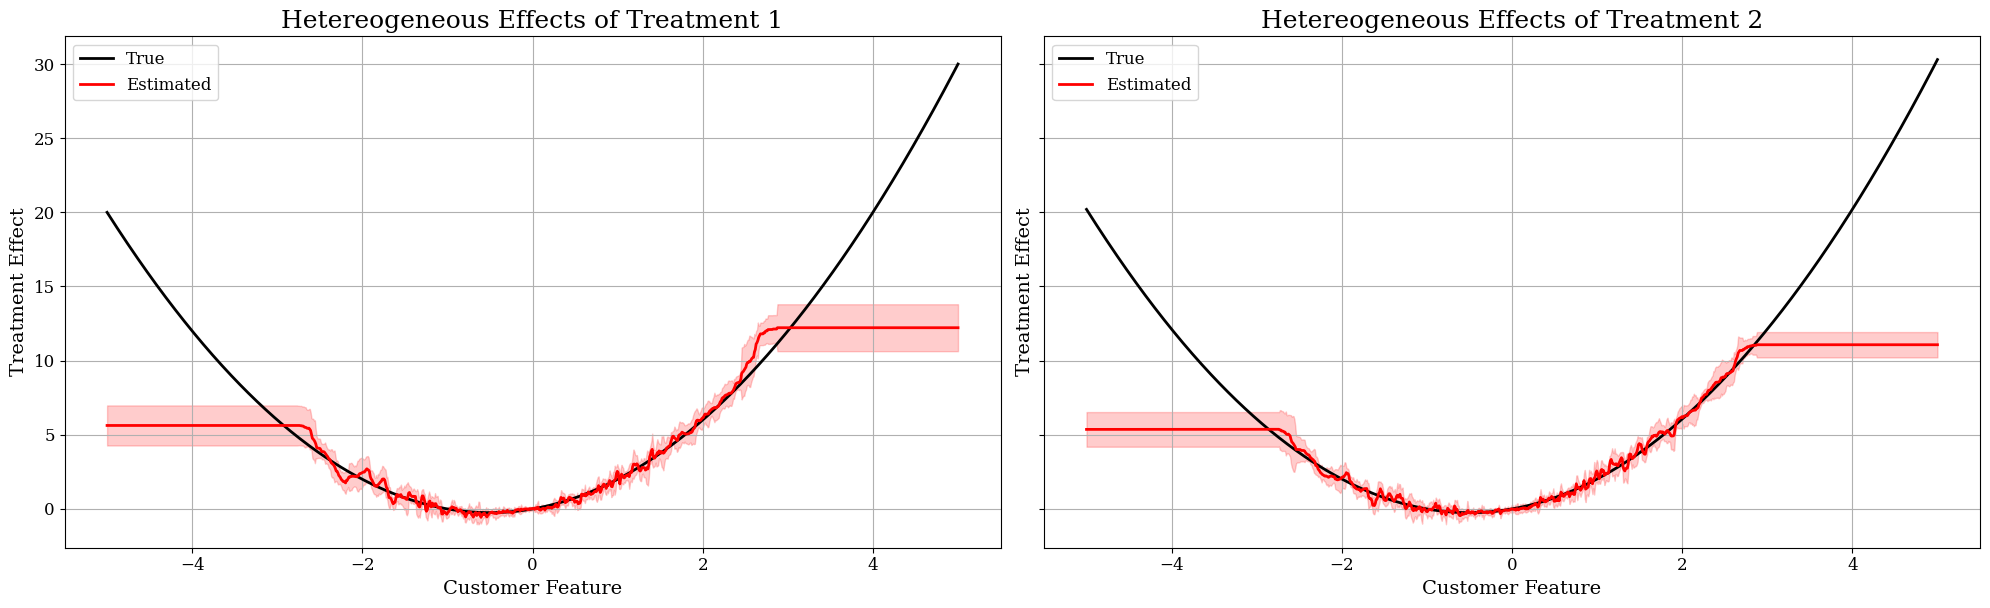

In [75]:
plot_hte(dgp, model=cfdml, ci=True, x_lb=-5, x_ub=5)

'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
'force_all_finite' wa

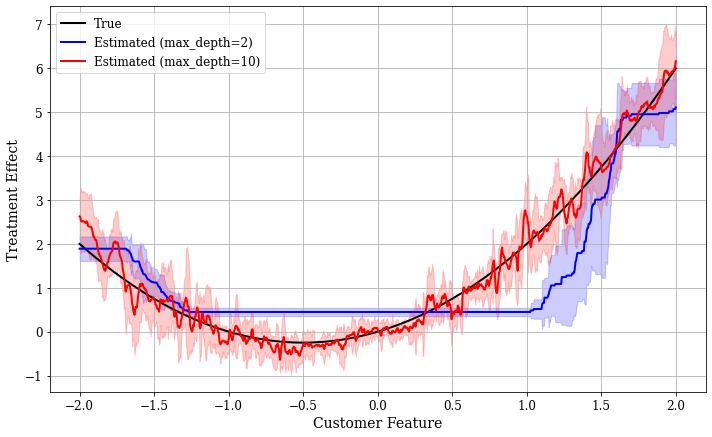

In [11]:
depths = [2, 10]
models = {}

for depth in depths:
    models[depth] = CausalForestDML(
        n_treatments=2, 
        model_t=LogisticRegression(C=0.01),
        model_y=Lasso(alpha=0.01), 
        n_estimators=100, 
        max_depth=depth, 
        n_jobs=-1,
        discrete_treatment=True
    ).fit(X=cust_features, Y=outcomes, T=treatments)

fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

x = np.linspace(-2, 2, 1000).reshape(-1, 1)

# true HTE
true_inc_te_arr, _ = dgp.predict_incremental_effect(x)
ax.plot(
    x, true_inc_te_arr[:, 0], label='True', color='black', linewidth=2
)

colors = {'2': 'blue', '5': 'green', '10': 'red'}

# plot estimated HTE for each depth
for depth in depths:
    est_inc_te_arr, _ = models[depth].predict_incremental_effect(x)
    ax.plot(
        x, est_inc_te_arr[:, 0],
        label=f'Estimated (max_depth={depth})',
        color=colors[str(depth)], linewidth=2
    )
    ci_lb, ci_ub = models[depth].predict_incremental_effect_interval(x)
    ax.fill_between(
        x.flatten(),
        ci_lb[:, 0],
        ci_ub[:, 0],
        alpha=0.2,
        color=colors[str(depth)]
    )

ax.set_xlabel('Customer Feature', fontsize=axis_label_size)
ax.set_ylabel('Treatment Effect', fontsize=axis_label_size)
ax.legend(fontsize=legend_label_size)
ax.tick_params(axis='both', which='major', labelsize=tick_label_size)
ax.grid()

plt.tight_layout()
plt.savefig('figures/cf_depth_compare.svg')
plt.show()

[Text(0.5, 0.8333333333333334, 'x[0] <= 1.248\nmse = 2.73\nsamples = 1688\nvalue = [[1.056]\n[1.083]]'),
 Text(0.25, 0.5, 'x[0] <= -1.524\nmse = 1.659\nsamples = 1517\nvalue = [[0.595]\n[0.547]]'),
 Text(0.375, 0.6666666666666667, 'True  '),
 Text(0.125, 0.16666666666666666, 'mse = 2.464\nsamples = 124\nvalue = [[2.073]\n[2.359]]'),
 Text(0.375, 0.16666666666666666, 'mse = 1.167\nsamples = 1393\nvalue = [[0.461]\n[0.45]]'),
 Text(0.75, 0.5, 'x[0] <= 1.861\nmse = 4.387\nsamples = 171\nvalue = [[5.134]\n[5.811]]'),
 Text(0.625, 0.6666666666666667, '  False'),
 Text(0.625, 0.16666666666666666, 'mse = 1.264\nsamples = 109\nvalue = [[3.688]\n[4.311]]'),
 Text(0.875, 0.16666666666666666, 'mse = 4.551\nsamples = 62\nvalue = [[8.162]\n[8.247]]')]

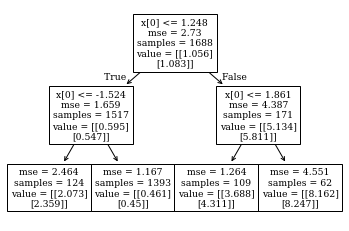

In [21]:
plot_tree(models[2].model[0][0])

## Visualizing Tree

In [18]:
tree = cfdml.model[0][0]
plot_tree(tree, max_depth=3)

InvalidParameterError: The 'decision_tree' parameter of plot_tree must be an instance of 'sklearn.tree._classes.DecisionTreeClassifier' or an instance of 'sklearn.tree._classes.DecisionTreeRegressor'. Got GRFTree(max_depth=25, max_features='auto', random_state=1606415418) instead.

In [118]:
# for max_depth in [2, 3, 4, 5, 6, 7, 8, 9, 10]:
#     print(f"\nMax_depth = {max_depth}")
#     cfdml = CausalForestDML(
#         n_treatments=2, model_t=LogisticRegression(C=0.01), model_y=Lasso(alpha=0.01), 
#         n_estimators=100, max_depth=max_depth, n_jobs=-1, discrete_treatment=True
#     ).fit(X=cust_features, Y=outcomes, T=treatments)

#     avg_var = np.mean(cfdml.predict_incremental_effect(oos_cust_features)[1])
#     print(f"Average variance = {avg_var}")

#     plot_hte(dgp, model=cfdml, ci=True)

# Selection

In [119]:
selection, val_est = optimize(cfdml, oos_cust_features)

# Evaluation

In [120]:
val_true = obj_func(
    selection=selection, 
    cust_feautres=oos_cust_features, 
    demand_model=dgp,
)

result_df = pd.DataFrame({
    'Policy Value': [val_est, val_true, val_est - val_true]
}, index=['Estimated', 'True', "Winner's Curse"])
result_df

,Policy Value
Estimated,4.234721
True,4.279313
Winner's Curse,-0.044593


In [121]:
del dgp, cfdml, selection, val_est, val_true, result_df 
del cust_features, treatments, outcomes, oos_cust_features

# Winner's Curse

## Causal Forest

In [41]:
optimization_params = {
    'rank_and_select': {
        'optimizer': optimize, 'params': {}, 'display_name': 'Rank and Select'
    }
}

dgp_params = {
    'base_effect_vars': [PointMass(1), PointMass(1.01)], 
    'cust_feat_var': UnivariateGaussian(0, 1), 
    'char_func': lambda x: x**2 + x, 
    'noise_var': UnivariateGaussian(0, 1), 
    'response_type': 'continuous', 
    'dgp_seed': 0
}

data_params = {'sample_size': 2500, 'targ_sample_size': 100} 

experiment_params = {
    'n_repeats': 500, 
    'estimator': {
        'estimator': CausalForestDML, 
        'params': {
            'n_treatments': len(dgp_params['base_effect_vars']), 
            'model_t': LogisticRegression(C=0.01), 
            'model_y': Lasso(alpha=0.01), 
            'n_estimators': 100, 
            'max_depth': 5, 
            'n_jobs': -1, 
            'discrete_outcome': False, 
            'discrete_treatment': True
        }
    }
}

estimators_dict = {}

In [42]:
result_records = repeated_experiment(
    optimization_params=optimization_params, 
    dgp_params=dgp_params, 
    data_params=data_params, 
    experiment_params=experiment_params, 
    estimators_dict=estimators_dict, 
    verbose=True, 
    n_jobs=-1
)

wc_measures_dict = calculate_winners_curse_measures(
    result_records=result_records, 
    optimization_params=optimization_params, 
    estimators_dict=estimators_dict, 
    data_params=data_params
)

Running 500 experiments...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:    5.4s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:   14.9s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:   18.4s finished


In [43]:
sample_size = 2500 
targ_sample_size = 100
experiment_id = 0
dgp = Targeting(**dgp_params)
estimator = experiment_params['estimator']['estimator']
estimator_params = experiment_params['estimator']['params']
optimizer = optimization_params['rank_and_select']['optimizer']
optimize_params = optimization_params['rank_and_select']['params']

# sample training and out-of-sample data
cust_features, treatments, outcomes = dgp.sample(sample_size=sample_size, seed=experiment_id)
targ_cust_features = dgp.sample_individuals(sample_size=targ_sample_size, seed=experiment_id + 10000)

# estimate treatment effects
emp_estimator = estimator(**estimator_params).fit(
    X=cust_features, Y=outcomes, T=treatments
)
emp_targ_te_arr, emp_targ_var_arr = emp_estimator.predict_incremental_effect(targ_cust_features)  # shape = (sample_size, n_treatments)
# replace outliers in the treatment effects array
emp_targ_te_arr = replace_outliers(emp_targ_te_arr, threshold=20)

selection, val_est = optimizer(
    demand_model=emp_estimator,
    cust_features=targ_cust_features,
    cust_treatment_effects=emp_targ_te_arr,
    **optimize_params
)

In [44]:
delta_tau = dgp_params['base_effect_vars'][1].mean - dgp_params['base_effect_vars'][0].mean

for optimizer in optimization_params.keys():
    display_name = optimization_params[optimizer]['display_name']

    # unpack results
    wc_arr = np.array([result[f'{optimizer}_wc'] for result in result_records])
    val_true_arr = np.array([result[f'{optimizer}_val_true'] for result in result_records])
    val_est_arr = np.array([result[f'{optimizer}_val_est'] for result in result_records])

    wc_avg = wc_arr.mean()
    wc_se = wc_arr.std() / np.sqrt(wc_arr.shape[0])

    val_true_avg = val_true_arr.mean()
    val_true_se = val_true_arr.std() / data_params['sample_size'] ** 0.5
    val_est_avg = val_est_arr.mean()
    val_est_se = val_est_arr.std() / data_params['sample_size'] ** 0.5

    print(f'\nSelection with {display_name}:')
    print(f'  - Average True Value: {val_true_avg:.4f} ({val_true_se:.4f})')
    print(f'  - Average Estimated Value: {val_est_avg:.4f} ({val_est_se:.4f})')
    print(f'  - Average Winner\'s Curse (%): {wc_avg/delta_tau:.2%} ({wc_se/delta_tau:.2%})')


Selection with Rank and Select:
  - Average True Value: 1.0044 (0.0034)
  - Average Estimated Value: 1.0376 (0.0034)
  - Average Winner's Curse (%): 331.81% (15.74%)


## Known Functional Form

In [45]:
optimization_params = {
    'rank_and_select': {
        'optimizer': optimize, 'params': {}, 'display_name': 'Rank and Select'
    }
}

dgp_params = {
    'base_effect_vars': [PointMass(1), PointMass(1.01)], 
    'cust_feat_var': UnivariateGaussian(0, 1), 
    'char_func': lambda x: x**2 + x, 
    'noise_var': UnivariateGaussian(0, 1), 
    'response_type': 'continuous', 
    'dgp_seed': 0
}

data_params = {'sample_size': 2500, 'targ_sample_size': 100} 

experiment_params = {
    'n_repeats': 500, 
    'estimator': {
        'estimator': EstimateWithKnownFunctionalForm,
        'params': {
            'n_treatments': 2,
            'fit_intercept': False
        }
    }
}

estimators_dict = {}

In [46]:
result_records = repeated_experiment(
    optimization_params=optimization_params, 
    dgp_params=dgp_params, 
    data_params=data_params, 
    experiment_params=experiment_params, 
    estimators_dict=estimators_dict, 
    verbose=True, 
    n_jobs=-1
)

wc_measures_dict = calculate_winners_curse_measures(
    result_records=result_records, 
    optimization_params=optimization_params, 
    estimators_dict=estimators_dict, 
    data_params=data_params
)

Running 500 experiments...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done 224 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 437 out of 500 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    0.0s finished


In [47]:
sample_size = 2500 
targ_sample_size = 100
experiment_id = 0
dgp = Targeting(**dgp_params)
estimator = experiment_params['estimator']['estimator']
estimator_params = experiment_params['estimator']['params']
optimizer = optimization_params['rank_and_select']['optimizer']
optimize_params = optimization_params['rank_and_select']['params']

# sample training and out-of-sample data
cust_features, treatments, outcomes = dgp.sample(sample_size=sample_size, seed=experiment_id)
targ_cust_features = dgp.sample_individuals(sample_size=targ_sample_size, seed=experiment_id + 10000)

# estimate treatment effects
emp_estimator = estimator(**estimator_params).fit(
    X=cust_features, Y=outcomes, T=treatments
)
emp_targ_te_arr, emp_targ_var_arr = emp_estimator.predict_incremental_effect(targ_cust_features)  # shape = (sample_size, n_treatments)
# replace outliers in the treatment effects array
emp_targ_te_arr = replace_outliers(emp_targ_te_arr, threshold=20)

selection, val_est = optimizer(
    demand_model=emp_estimator,
    cust_features=targ_cust_features,
    cust_treatment_effects=emp_targ_te_arr,
    **optimize_params
)

In [48]:
delta_tau = dgp_params['base_effect_vars'][1].mean - dgp_params['base_effect_vars'][0].mean

for optimizer in optimization_params.keys():
    display_name = optimization_params[optimizer]['display_name']

    # unpack results
    wc_arr = np.array([result[f'{optimizer}_wc'] for result in result_records])
    val_true_arr = np.array([result[f'{optimizer}_val_true'] for result in result_records])
    val_est_arr = np.array([result[f'{optimizer}_val_est'] for result in result_records])

    wc_avg = wc_arr.mean()
    wc_se = wc_arr.std() / np.sqrt(wc_arr.shape[0])

    val_true_avg = val_true_arr.mean()
    val_true_se = val_true_arr.std() / data_params['sample_size'] ** 0.5
    val_est_avg = val_est_arr.mean()
    val_est_se = val_est_arr.std() / data_params['sample_size'] ** 0.5

    print(f'\nSelection with {display_name}:')
    print(f'  - Average True Value: {val_true_avg:.4f} ({val_true_se:.4f})')
    print(f'  - Average Estimated Value: {val_est_avg:.4f} ({val_est_se:.4f})')
    print(f'  - Average Winner\'s Curse (%): {wc_avg/delta_tau:.2%} ({wc_se/delta_tau:.2%})')


Selection with Rank and Select:
  - Average True Value: 1.0056 (0.0035)
  - Average Estimated Value: 1.0143 (0.0035)
  - Average Winner's Curse (%): 87.32% (8.91%)


# Estimating Winner's Curse

In [11]:
dgp = Targeting(**dgp_params)

cust_features, treatments, outcomes = dgp.sample(data_params['sample_size'], seed=19)
oos_cust_features = dgp.sample_individuals(data_params['sample_size'], seed=19 + 10000)

In [21]:
estimator = EstimateWithKnownFunctionalForm
estimator_params = {'n_treatments': 2, 'fit_intercept': False}

estimator = estimator(**estimator_params).fit(
    X=cust_features, Y=outcomes, T=treatments
)
emp_targ_te_arr, _ = estimator.predict_incremental_effect(oos_cust_features)

## Standard Bootstrap

In [9]:
boot_wc_dstn_dict = get_wc_boot_dstn(
    cust_features=cust_features, 
    treatments=treatments, 
    outcomes=outcomes, 
    targ_cust_features=oos_cust_features, 
    optimization_params=optimization_params, 
    estimator=experiment_params['estimator']['estimator'], 
    estimator_params=experiment_params['estimator']['params'], 
    n_bootstraps=500, 
    emp_targ_te_arr=None, 
    n_jobs=-1, 
    verbose=True, 
    seed=0
)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:    2.4s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:    6.5s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    8.2s finished


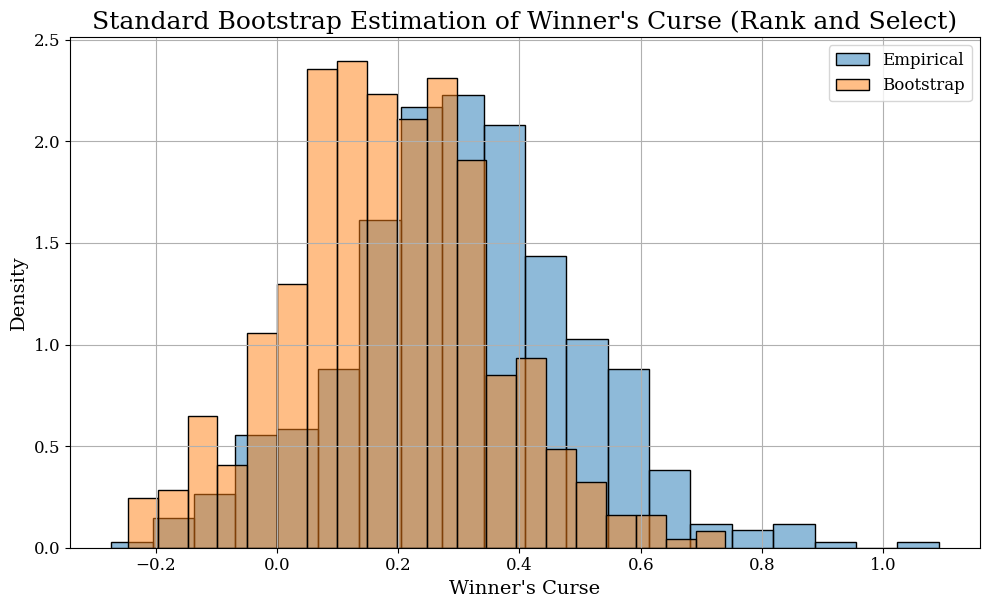

In [10]:
optimizer_name = 'rank_and_select'

fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

display_name = optimization_params[optimizer_name]['display_name']

wc_dstn = np.array([result[f'{optimizer_name}_wc'] for result in result_records])
wc_boot_dstn = boot_wc_dstn_dict[optimizer_name]

sns.histplot(wc_dstn, bins=20, color='C0', alpha=0.5, stat='density', label='Empirical', ax=ax)
sns.histplot(wc_boot_dstn, bins=20, color='C1', alpha=0.5, stat='density', label='Bootstrap', ax=ax)
ax.set_xlabel('Winner\'s Curse', fontsize=axis_label_size)
ax.set_ylabel('Density', fontsize=axis_label_size)
ax.set_title(f'Standard Bootstrap Estimation of Winner\'s Curse ({display_name})', fontsize=title_size)
ax.tick_params(axis='both', labelsize=tick_label_size)
ax.legend(fontsize=legend_label_size)
ax.grid()

plt.tight_layout()
plt.show()

## m-out-of-n Bootstrap

In [11]:
boot_wc_dstn_dict = get_wc_m_out_of_n_boot_dstn(
    cust_features=cust_features, 
    treatments=treatments, 
    outcomes=outcomes, 
    targ_cust_features=oos_cust_features, 
    optimization_params=optimization_params, 
    estimator=experiment_params['estimator']['estimator'], 
    estimator_params=experiment_params['estimator']['params'], 
    n_bootstraps=500, 
    emp_targ_te_arr=None, 
    power=0.95, 
    n_jobs=-1, 
    verbose=True, 
    seed=0
)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:    2.1s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:    6.1s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    7.6s finished


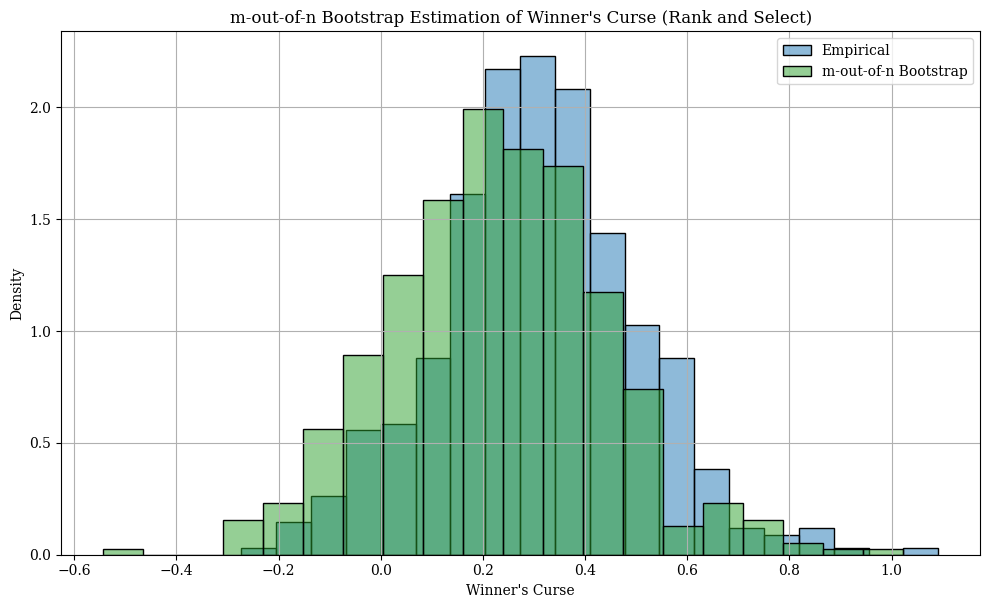

In [12]:
optimizer_name = 'rank_and_select'

fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

display_name = optimization_params[optimizer_name]['display_name']

wc_dstn = np.array([result[f'{optimizer_name}_wc'] for result in result_records])
wc_boot_dstn = boot_wc_dstn_dict[optimizer_name]

sns.histplot(wc_dstn, bins=20, color='C0', alpha=0.5, stat='density', label='Empirical', ax=ax)
sns.histplot(wc_boot_dstn, bins=20, color='C2', alpha=0.5, stat='density', label='m-out-of-n Bootstrap', ax=ax)
ax.set_xlabel('Winner\'s Curse')
ax.set_ylabel('Density')
ax.set_title(f'm-out-of-n Bootstrap Estimation of Winner\'s Curse ({display_name})')
ax.legend()
ax.grid()

plt.tight_layout()
plt.show()

## Numerical Bootstrap

In [13]:
boot_wc_dstn_dict = get_wc_num_boot_dstn(
    cust_features=cust_features, 
    treatments=treatments, 
    outcomes=outcomes, 
    targ_cust_features=oos_cust_features, 
    optimization_params=optimization_params, 
    estimator=experiment_params['estimator']['estimator'], 
    estimator_params=experiment_params['estimator']['params'], 
    n_bootstraps=500, 
    emp_targ_te_arr=None, 
    power=-0.45, 
    n_jobs=-1, 
    verbose=True, 
    seed=0
)

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:    2.5s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:    6.5s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    8.2s finished


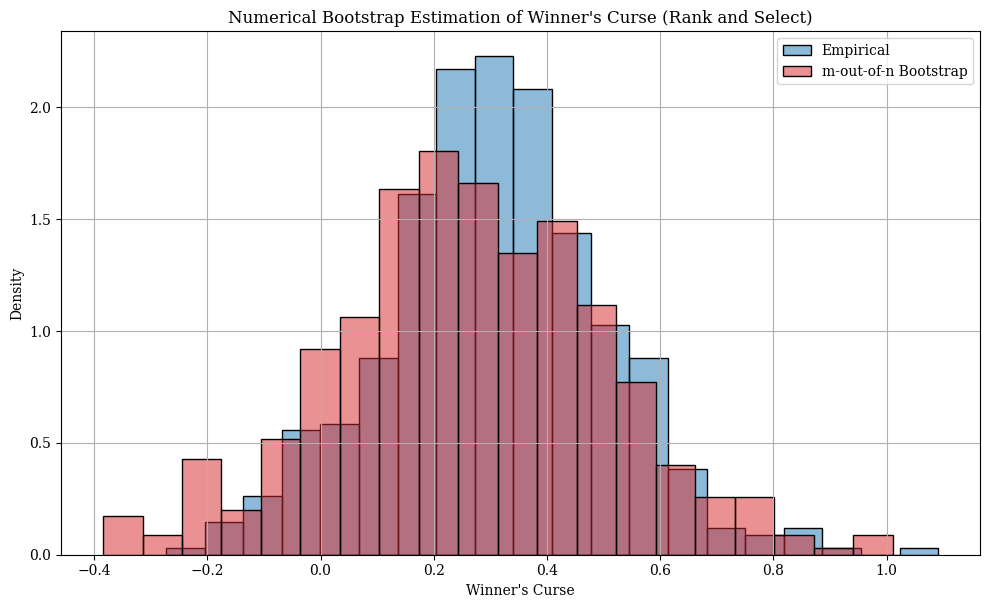

In [14]:
optimizer_name = 'rank_and_select'

fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

display_name = optimization_params[optimizer_name]['display_name']

wc_dstn = np.array([result[f'{optimizer_name}_wc'] for result in result_records])
wc_boot_dstn = boot_wc_dstn_dict[optimizer_name]

sns.histplot(wc_dstn, bins=20, color='C0', alpha=0.5, stat='density', label='Empirical', ax=ax)
sns.histplot(wc_boot_dstn, bins=20, color='C3', alpha=0.5, stat='density', label='m-out-of-n Bootstrap', ax=ax)
ax.set_xlabel('Winner\'s Curse')
ax.set_ylabel('Density')
ax.set_title(f'Numerical Bootstrap Estimation of Winner\'s Curse ({display_name})')
ax.legend()
ax.grid()

plt.tight_layout()
plt.show()

# Bias Correction

## Causal Forest

In [ ]:
optimization_params = {
    'rank_and_select': {
        'optimizer': optimize, 'params': {}, 'display_name': 'Rank and Select'
    }
}

dgp_params = {
    'base_effect_vars': [PointMass(1), PointMass(1.01)], 
    'cust_feat_var': UnivariateGaussian(0, 1), 
    'char_func': lambda x: x**2 + x, 
    'noise_var': UnivariateGaussian(0, 1), 
    'response_type': 'continuous', 
    'dgp_seed': 0
}

data_params = {'sample_size': 2500, 'targ_sample_size': 100} 

experiment_params = {
    'n_repeats': 500, 
    'estimator': {
        'estimator': CausalForestDML, 
        'params': {
            'n_treatments': len(dgp_params['base_effect_vars']), 
            'model_t': LogisticRegression(C=0.01), 
            'model_y': Lasso(alpha=0.01), 
            'n_estimators': 100, 
            'max_depth': 5, 
            'n_jobs': -1, 
            'discrete_treatment': True
        }
    }
}

estimators_dict = {
    'sample_splitting': {
        'estimator': sample_splitting_estimate, 
        'params': {'estimation_split': 0.5}, 
        'display_name': 'Sample Splitting', 
    }, 
    'standard_bootstrap': {
        'estimator': bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 100, 'n_jobs': -1}, 
        'display_name': 'Standard Bootstrap'
    },
    'mn_bootstrap': {
        'estimator': bootstrap_correction_estimate, 
        'params': {'bootstrap_method': 'm_out_of_n', 'n_bootstraps': 100, 'power': 0.95, 'n_jobs': -1}, 
        'display_name': 'm-out-of-n Bootstrap'
    },
    'num_bootstrap': {
        'estimator': bootstrap_correction_estimate, 
        'params': {'bootstrap_method': 'numerical', 'n_bootstraps': 100, 'power': -0.45, 'n_jobs': -1}, 
        'display_name': 'Numerical Bootstrap'
    }, 
    # 'bayes_normal': {
    #     'estimator': bayes_estimate, 
    #     'params': {'prior': 'normal', 'prior_mean': 0.0, 'prior_std': 1.0},
    #     'display_name': 'Bayes'
    # }, 
    'eb_normal': {
        'estimator': empirical_bayes_estimate, 
        'params': {'prior': 'normal', 'dof': 3, 'bin_width': 0.2}, 
        'display_name': 'Empirical Bayes'
    }, 
    # 'eb_spike_slab': {
    #     'estimator': empirical_bayes_estimate, 
    #     'params': {'prior': 'spike_slab', 'pi': 0.5},
    #     'display_name': 'EB (Spike-and-Slab)'
    # }, 
    'conditional_si': {
        'estimator': selective_inference_estimate,
        'params': {'method': 'conditional', 'quantile': 0.5, 'n_jobs': -1}, 
        'display_name': 'Conditional SI'
    }, 
    # 'hybrid_si': {
    #     'estimator': selective_inference_estimate,
    #     'params': {'method': 'hybrid', 'quantile': 0.5, 'n_jobs': -1}, 
    #     'display_name': 'Hybrid SI'
    # }, 
}

In [33]:
result_records = repeated_experiment(
    optimization_params=optimization_params, 
    dgp_params=dgp_params, 
    data_params=data_params, 
    experiment_params=experiment_params, 
    estimators_dict=estimators_dict, 
    verbose=True, 
    n_jobs=-1
)

wc_measures_dict = calculate_winners_curse_measures(
    result_records=result_records, 
    optimization_params=optimization_params, 
    estimators_dict=estimators_dict, 
    data_params=data_params
)

Running 500 experiments...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done 224 tasks      | elapsed:    0.0s
[Parallel(n_jobs=-1)]: Done 437 out of 500 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:    0.0s finished


In [49]:
# with open('results/targeting_bias_correction.pkl', 'wb') as f:
#     pickle.dump(wc_measures_dict, f)

with open('results/targeting_bias_correction.pkl', 'rb') as f:
    wc_measures_dict = pickle.load(f)


Selection with Rank and Select:
Policy Value: 
  - True Value: 1.0319 (0.0080)
  - No Correction: 1.0983 (0.0082)

Winner's Curse: 
Average Winner's Curse: 
  - No Correction: 664.79% (34.05%)
Median Winner's Curse: 
  - No Correction: 644.82% (34.05%)


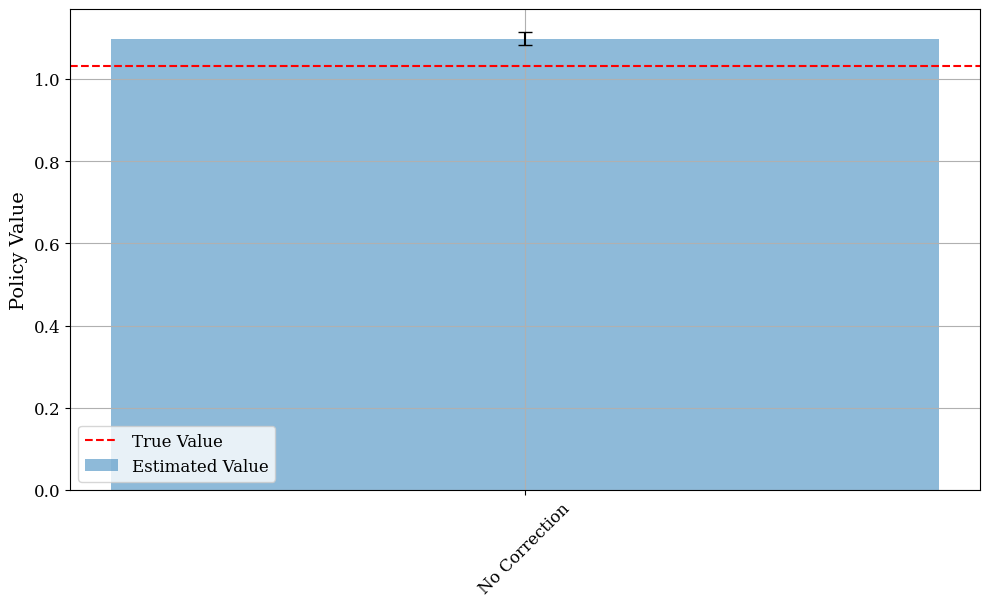

In [50]:
delta_tau = dgp_params['base_effect_vars'][1].mean - dgp_params['base_effect_vars'][0].mean

optimizer_key = 'rank_and_select'

print(f'\nSelection with {optimization_params[optimizer_key]["display_name"]}:')

val_true_avg = wc_measures_dict[f'{optimizer_key}_nc_val_true_avg']
val_true_se = wc_measures_dict[f'{optimizer_key}_nc_val_true_se']

print(f'Policy Value: ')
print(f'  - True Value: {val_true_avg:.4f} ({val_true_se:.4f})')
for estimator_name in ['nc'] + [k for k in estimators_dict.keys() if k != 'sample_splitting']:
    if estimator_name == 'sample_splitting':
        continue
    est_avg = wc_measures_dict[f'{optimizer_key}_{estimator_name}_val_est_avg']
    est_se = wc_measures_dict[f'{optimizer_key}_{estimator_name}_val_est_se']
    display_name = estimators_dict[estimator_name]['display_name'] if estimator_name != 'nc' else 'No Correction'

    print(f'  - {display_name}: {est_avg:.4f} ({est_se:.4f})')

print(f'\nWinner\'s Curse: ')
print(f"Average Winner's Curse: ")
for estimator_name in ['nc'] + [k for k in estimators_dict.keys() if k != 'sample_splitting']:
    if estimator_name == 'sample_splitting':
        continue
    wc_avg = wc_measures_dict[f'{optimizer_key}_{estimator_name}_wc_avg']
    wc_se = wc_measures_dict[f'{optimizer_key}_{estimator_name}_wc_se']
    display_name = estimators_dict[estimator_name]['display_name'] if estimator_name != 'nc' else 'No Correction'

    print(f'  - {display_name}: {wc_avg/delta_tau:.2%} ({wc_se/delta_tau:.2%})')

print(f'Median Winner\'s Curse: ')
for estimator_name in ['nc'] + [k for k in estimators_dict.keys() if k != 'sample_splitting']:
    if estimator_name == 'sample_splitting':
        continue
    wc_median = np.nanmedian(wc_measures_dict[f'{optimizer_key}_{estimator_name}_wc_arr'])
    wc_se = wc_measures_dict[f'{optimizer_key}_{estimator_name}_wc_se']
    display_name = estimators_dict[estimator_name]['display_name'] if estimator_name != 'nc' else 'No Correction'

    print(f'  - {display_name}: {wc_median/delta_tau:.2%} ({wc_se/delta_tau:.2%})')

if 'sample_splitting' in estimators_dict.keys():
    print(f'\nSample Splitting: ')
    ss_val_true_avg = wc_measures_dict[f'{optimizer_key}_sample_splitting_val_true_avg']
    ss_val_true_se = wc_measures_dict[f'{optimizer_key}_sample_splitting_val_true_se']
    ss_val_est_avg = wc_measures_dict[f'{optimizer_key}_sample_splitting_val_est_avg']
    ss_val_est_se = wc_measures_dict[f'{optimizer_key}_sample_splitting_val_est_se']
    ss_wc_avg = wc_measures_dict[f'{optimizer_key}_sample_splitting_wc_avg']
    ss_wc_se = wc_measures_dict[f'{optimizer_key}_sample_splitting_wc_se']

    print(f'  - True Value: {ss_val_true_avg:.4f} ({ss_val_true_se:.4f})')
    print(f'  - Estimated Value: {ss_val_est_avg:.4f} ({ss_val_est_se:.4f})')
    print(f'  - Winner\'s Curse (%): {ss_wc_avg/delta_tau:.2%} ({ss_wc_se/delta_tau:.2%})')

# bar plot comparing the true value and estiamted value frome each estimator 
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

bar_positions = np.arange(len(estimators_dict.keys()) + 1 - int('sample_splitting' in estimators_dict.keys()))
bar_values = [
    wc_measures_dict[f'{optimizer_key}_{estimator_name}_val_est_avg']
    for estimator_name in ['nc'] + [k for k in estimators_dict.keys() if k != 'sample_splitting']
]
bar_errors = [
    1.96 * wc_measures_dict[f'{optimizer_key}_{estimator_name}_val_est_se']
    for estimator_name in ['nc'] + [k for k in estimators_dict.keys() if k != 'sample_splitting']
]

# plot the bars
ax.bar(bar_positions, bar_values, yerr=bar_errors, capsize=5, color='C0', alpha=0.5, label='Estimated Value')
ax.axhline(y=val_true_avg, color='red', linestyle='--', label='True Value')

# plot the bar for sample splitting if it exists
if 'sample_splitting' in estimators_dict.keys():
    # two side-by-side bars for sample splitting, one for true value and one for estimated value
    bar_width = 0.4
    ax.bar(bar_positions[-1] + 1 - bar_width / 2, ss_val_true_avg, yerr=1.95 * ss_val_true_se, capsize=5, color='red', width=bar_width, alpha=0.5)
    ax.bar(bar_positions[-1] + 1 + bar_width / 2, ss_val_est_avg, yerr=1.95 * ss_val_est_se, capsize=5, color='C0', width=bar_width, alpha=0.5)

# ax.set_xlabel('Estimator')
ax.set_ylabel('Policy Value', fontsize=axis_label_size)
# ax.set_title(f'{optimization_params[optimizer_key]["display_name"]} Selection', fontsize=title_size)
if 'sample_splitting' in estimators_dict.keys():
    ax.set_xticks(
        np.arange(len(estimators_dict) + 1), 
        labels=['No Correction'] + [v['display_name'] for k, v in estimators_dict.items() if k != 'sample_splitting'] + ['Sample Splitting'], 
        rotation=45, 
        fontsize=tick_label_size
    )
else:
    ax.set_xticks(
        np.arange(len(estimators_dict) + 1), 
        labels=['No Correction'] + [v['display_name'] for k, v in estimators_dict.items()], 
        rotation=45, 
        fontsize=tick_label_size
    )
# ax.set_ylim([0.9, 1.2])
ax.tick_params(axis='both', labelsize=tick_label_size)
ax.legend(fontsize=legend_label_size)
ax.grid()
plt.tight_layout()
plt.show()


In [51]:
optimizer_key= 'rank_and_select'
delta_tau = dgp_params['base_effect_vars'][1].mean - dgp_params['base_effect_vars'][0].mean
latex_dict = {}

# true value
val_true_avg = wc_measures_dict[f'{optimizer_key}_nc_val_true_avg']
val_true_se = wc_measures_dict[f'{optimizer_key}_nc_val_true_se']
latex_dict["True Value"] = {
    'Policy Value': "\\begin{tabular}[c]{@{}c@{}}" + f"${val_true_avg:.4f}$\\\\ (${val_true_se:.4f}$)" + "\end{tabular}", 
    r"\begin{tabular}[c]{@{}c@{}} Winner's Curse (\%)\\ $WC / \Delta\tau$ \end{tabular}": "\\begin{tabular}[c]{@{}c@{}}" + f"${0:.2f}\%$\\\\ (${0:.2f}\%$)" + "\end{tabular}"
}

for e_key in ['nc'] + list(estimators_dict.keys()):
    if e_key == 'sample_splitting':
        continue
    
    est_mean = wc_measures_dict[f'{optimizer_key}_{e_key}_val_est_avg']
    est_se = wc_measures_dict[f'{optimizer_key}_{e_key}_val_est_se']

    wc_mean = 100 / delta_tau * wc_measures_dict[f'{optimizer_key}_{e_key}_wc_avg']
    wc_se = 100 / delta_tau * wc_measures_dict[f'{optimizer_key}_{e_key}_wc_se']
    wc_sig_level = significance_level(wc_mean, wc_se)
    wc_sig_level = '^{' + wc_sig_level + '}' if wc_sig_level != '' else ''

    e_name =  estimators_dict[e_key]['display_name'] if e_key != 'nc' else 'No Correction'

    latex_dict[e_name] = {
        'Policy Value': "\\begin{tabular}[c]{@{}c@{}}" + f"${est_mean:.4f}" + f"$\\\\ (${est_se:.4f}$)" + "\end{tabular}", 
        r"\begin{tabular}[c]{@{}c@{}} Winner's Curse (\%)\\ $WC / \Delta\tau$ \end{tabular}": "\\begin{tabular}[c]{@{}c@{}}" + f"${wc_mean:.2f}\%" + wc_sig_level + f"$\\\\ (${wc_se:.2f}\%$)" + "\end{tabular}"
    }

# sample splitting
ss_val_est_avg = wc_measures_dict[f'{optimizer_key}_sample_splitting_val_est_avg']
ss_val_est_se = wc_measures_dict[f'{optimizer_key}_sample_splitting_val_est_se']

ss_wc_avg = 100 / delta_tau * wc_measures_dict[f'{optimizer_key}_sample_splitting_wc_avg']
ss_wc_se = 100 / delta_tau * wc_measures_dict[f'{optimizer_key}_sample_splitting_wc_se']
ss_wc_sig_level = significance_level(ss_wc_avg, ss_wc_se)
ss_wc_sig_level = '^{' + ss_wc_sig_level + '}' if ss_wc_sig_level != '' else ''
latex_dict["Sample Splitting"] = {
    'Policy Value': "\\begin{tabular}[c]{@{}c@{}}" + f"${ss_val_est_avg:.4f}" + f"$\\\\ (${ss_val_est_se:.4f}$)" + "\end{tabular}",
    r"\begin{tabular}[c]{@{}c@{}} Winner's Curse (\%)\\ $WC / \Delta\tau$ \end{tabular}": "\\begin{tabular}[c]{@{}c@{}}" + f"${ss_wc_avg:.2f}\%" + ss_wc_sig_level + f"$\\\\ (${ss_wc_se:.2f}\%$)" + "\end{tabular}"
}

latex_df = pd.DataFrame(latex_dict).T
print(latex_df.style.to_latex(
    column_format='ccc',  
    hrules=True
))

\begin{tabular}{ccc}
\toprule
 & Policy Value & \begin{tabular}[c]{@{}c@{}} Winner's Curse (\%)\\ $WC / \Delta\tau$ \end{tabular} \\
\midrule
True Value & \begin{tabular}[c]{@{}c@{}}$1.0319$\\ ($0.0080$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$0.00\%$\\ ($0.00\%$)\end{tabular} \\
No Correction & \begin{tabular}[c]{@{}c@{}}$1.0983$\\ ($0.0082$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$664.79\%^{***}$\\ ($34.05\%$)\end{tabular} \\
Sample Splitting & \begin{tabular}[c]{@{}c@{}}$1.0179$\\ ($0.0086$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$-140.15\%^{***}$\\ ($52.04\%$)\end{tabular} \\
\bottomrule
\end{tabular}



In [52]:
nc_val_true_avg  = wc_measures_dict[f'{optimizer_key}_nc_val_true_avg']
nc_val_true_se = wc_measures_dict[f'{optimizer_key}_nc_val_true_se']
clairvoyant_val = np.max([var.mean for var in dgp_params['base_effect_vars']])
policy_comp_dict = {
    'Clairvoyant Policy': {'Policy Value': f"{clairvoyant_val:.4f}"}, 
    'Focal Policy': {'Policy Value': "\\begin{tabular}[c]{@{}c@{}}" + f"${nc_val_true_avg:.4f}" + f"$\\\\ (${nc_val_true_se:.4f}$)" + "\end{tabular}"},
}

ss_val_true_avg = wc_measures_dict[f'{optimizer_key}_sample_splitting_val_true_avg']
ss_val_true_se = wc_measures_dict[f'{optimizer_key}_sample_splitting_val_true_se']
random_val = np.mean([var.mean for var in dgp_params['base_effect_vars']])
policy_comp_dict.update({
    'Sample Splitting': {'Policy Value': "\\begin{tabular}[c]{@{}c@{}}" + f"${ss_val_true_avg:.4f}" + f"$\\\\ (${ss_val_true_se:.4f}$)" + "\end{tabular}"}, 
    'Random Guessing': {'Policy Value': f'{random_val:.4f}'},
})

policy_comp_df = pd.DataFrame(policy_comp_dict).T
print(policy_comp_df.style.to_latex(
    column_format='cc',  
    hrules=True
))

\begin{tabular}{cc}
\toprule
 & Policy Value \\
\midrule
Clairvoyant Policy & 1.0100 \\
Focal Policy & \begin{tabular}[c]{@{}c@{}}$1.0319$\\ ($0.0080$)\end{tabular} \\
Sample Splitting & \begin{tabular}[c]{@{}c@{}}$1.0300$\\ ($0.0079$)\end{tabular} \\
Random Guessing & 1.0050 \\
\bottomrule
\end{tabular}



## Known Functional Form

In [5]:
optimization_params = {
    'rank_and_select': {
        'optimizer': optimize, 'params': {}, 'display_name': 'Rank and Select'
    }
}

dgp_params = {
    'base_effect_vars': [PointMass(1), PointMass(1.01)], 
    'cust_feat_var': UnivariateGaussian(0, 1), 
    'char_func': lambda x: x**2 + x, 
    'noise_var': UnivariateGaussian(0, 1), 
    'response_type': 'continuous', 
    'dgp_seed': 0
}

data_params = {'sample_size': 2500, 'targ_sample_size': 100} 

experiment_params = {
    'n_repeats': 500, 
    'estimator': {
        'estimator': EstimateWithKnownFunctionalForm,
        'params': {
            'n_treatments': len(dgp_params['base_effect_vars']),
            'fit_intercept': False
        }
    }
}

estimators_dict = {
    'sample_splitting': {
        'estimator': sample_splitting_estimate, 
        'params': {'estimation_split': 0.5}, 
        'display_name': 'Sample Splitting', 
    }, 
    'standard_bootstrap': {
        'estimator': bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 100, 'n_jobs': -1}, 
        'display_name': 'Standard Bootstrap'
    },
    'mn_bootstrap': {
        'estimator': bootstrap_correction_estimate, 
        'params': {'bootstrap_method': 'm_out_of_n', 'n_bootstraps': 100, 'power': 0.95, 'n_jobs': -1}, 
        'display_name': 'm-out-of-n Bootstrap'
    },
    'num_bootstrap': {
        'estimator': bootstrap_correction_estimate, 
        'params': {'bootstrap_method': 'numerical', 'n_bootstraps': 100, 'power': -0.45, 'n_jobs': -1}, 
        'display_name': 'Numerical Bootstrap'
    }, 
    # 'bayes_normal': {
    #     'estimator': bayes_estimate, 
    #     'params': {'prior': 'normal', 'prior_mean': 0.0, 'prior_std': 1.0},
    #     'display_name': 'Bayes'
    # }, 
    'eb_normal': {
        'estimator': empirical_bayes_estimate, 
        'params': {'prior': 'normal', 'dof': 3, 'bin_width': 0.2}, 
        'display_name': 'Empirical Bayes'
    }, 
    # 'eb_spike_slab': {
    #     'estimator': empirical_bayes_estimate, 
    #     'params': {'prior': 'spike_slab', 'pi': 0.5},
    #     'display_name': 'EB (Spike-and-Slab)'
    # }, 
    'conditional_si': {
        'estimator': selective_inference_estimate,
        'params': {'method': 'conditional', 'quantile': 0.5, 'n_jobs': -1}, 
        'display_name': 'Conditional SI'
    }, 
    # 'hybrid_si': {
    #     'estimator': selective_inference_estimate,
    #     'params': {'method': 'hybrid', 'quantile': 0.5, 'n_jobs': -1}, 
    #     'display_name': 'Hybrid SI'
    # }, 
}

In [6]:
result_records = repeated_experiment(
    optimization_params=optimization_params, 
    dgp_params=dgp_params, 
    data_params=data_params, 
    experiment_params=experiment_params, 
    estimators_dict=estimators_dict, 
    verbose=True, 
    n_jobs=-1
)

wc_measures_dict = calculate_winners_curse_measures(
    result_records=result_records, 
    optimization_params=optimization_params, 
    estimators_dict=estimators_dict, 
    data_params=data_params
)

Running 500 experiments...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:   15.6s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:   25.6s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:   29.5s finished


In [7]:
with open('results/targeting_cff_bias_correction.pkl', 'wb') as f:
    pickle.dump(wc_measures_dict, f)

with open('results/targeting_cff_bias_correction.pkl', 'rb') as f:
    wc_measures_dict = pickle.load(f)


Selection with Rank and Select:
Policy Value: 
  - True Value: 1.0056 (0.0035)
  - No Correction: 1.0143 (0.0035)
  - Standard Bootstrap: 1.0065 (0.0035)
  - m-out-of-n Bootstrap: 1.0034 (0.0034)
  - Numerical Bootstrap: 1.0020 (0.0035)
  - Empirical Bayes: 1.0136 (0.0035)
  - Conditional SI: 0.9503 (0.0047)

Winner's Curse: 
Average Winner's Curse: 
  - No Correction: 87.32% (3.99%)
  - Standard Bootstrap: 8.52% (4.16%)
  - m-out-of-n Bootstrap: -22.27% (4.16%)
  - Numerical Bootstrap: -36.39% (4.25%)
  - Empirical Bayes: 79.84% (3.98%)
  - Conditional SI: -555.21% (31.11%)
Median Winner's Curse: 
  - No Correction: 87.88% (3.99%)
  - Standard Bootstrap: 5.83% (4.16%)
  - m-out-of-n Bootstrap: -22.30% (4.16%)
  - Numerical Bootstrap: -40.82% (4.25%)
  - Empirical Bayes: 80.18% (3.98%)
  - Conditional SI: -162.84% (31.11%)

Sample Splitting: 
  - True Value: 1.0049 (0.0034)
  - Estimated Value: 1.0039 (0.0035)
  - Winner's Curse (%): -17.38% (3.61%)


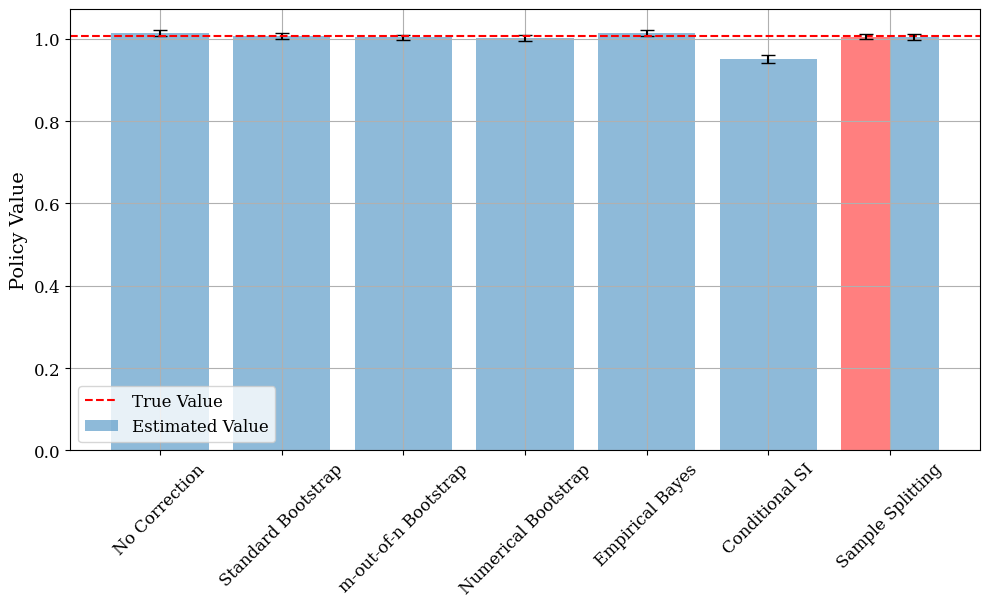

In [8]:
delta_tau = dgp_params['base_effect_vars'][1].mean - dgp_params['base_effect_vars'][0].mean

optimizer_key = 'rank_and_select'

print(f'\nSelection with {optimization_params[optimizer_key]["display_name"]}:')

val_true_avg = wc_measures_dict[f'{optimizer_key}_nc_val_true_avg']
val_true_se = wc_measures_dict[f'{optimizer_key}_nc_val_true_se']

print(f'Policy Value: ')
print(f'  - True Value: {val_true_avg:.4f} ({val_true_se:.4f})')
for estimator_name in ['nc'] + [k for k in estimators_dict.keys() if k != 'sample_splitting']:
    if estimator_name == 'sample_splitting':
        continue
    est_avg = wc_measures_dict[f'{optimizer_key}_{estimator_name}_val_est_avg']
    est_se = wc_measures_dict[f'{optimizer_key}_{estimator_name}_val_est_se']
    display_name = estimators_dict[estimator_name]['display_name'] if estimator_name != 'nc' else 'No Correction'

    print(f'  - {display_name}: {est_avg:.4f} ({est_se:.4f})')

print(f'\nWinner\'s Curse: ')
print(f"Average Winner's Curse: ")
for estimator_name in ['nc'] + [k for k in estimators_dict.keys() if k != 'sample_splitting']:
    if estimator_name == 'sample_splitting':
        continue
    wc_avg = wc_measures_dict[f'{optimizer_key}_{estimator_name}_wc_avg']
    wc_se = wc_measures_dict[f'{optimizer_key}_{estimator_name}_wc_se']
    display_name = estimators_dict[estimator_name]['display_name'] if estimator_name != 'nc' else 'No Correction'

    print(f'  - {display_name}: {wc_avg/delta_tau:.2%} ({wc_se/delta_tau:.2%})')

print(f'Median Winner\'s Curse: ')
for estimator_name in ['nc'] + [k for k in estimators_dict.keys() if k != 'sample_splitting']:
    if estimator_name == 'sample_splitting':
        continue
    wc_median = np.nanmedian(wc_measures_dict[f'{optimizer_key}_{estimator_name}_wc_arr'])
    wc_se = wc_measures_dict[f'{optimizer_key}_{estimator_name}_wc_se']
    display_name = estimators_dict[estimator_name]['display_name'] if estimator_name != 'nc' else 'No Correction'

    print(f'  - {display_name}: {wc_median/delta_tau:.2%} ({wc_se/delta_tau:.2%})')

if 'sample_splitting' in estimators_dict.keys():
    print(f'\nSample Splitting: ')
    ss_val_true_avg = wc_measures_dict[f'{optimizer_key}_sample_splitting_val_true_avg']
    ss_val_true_se = wc_measures_dict[f'{optimizer_key}_sample_splitting_val_true_se']
    ss_val_est_avg = wc_measures_dict[f'{optimizer_key}_sample_splitting_val_est_avg']
    ss_val_est_se = wc_measures_dict[f'{optimizer_key}_sample_splitting_val_est_se']
    ss_wc_avg = wc_measures_dict[f'{optimizer_key}_sample_splitting_wc_avg']
    ss_wc_se = wc_measures_dict[f'{optimizer_key}_sample_splitting_wc_se']

    print(f'  - True Value: {ss_val_true_avg:.4f} ({ss_val_true_se:.4f})')
    print(f'  - Estimated Value: {ss_val_est_avg:.4f} ({ss_val_est_se:.4f})')
    print(f'  - Winner\'s Curse (%): {ss_wc_avg/delta_tau:.2%} ({ss_wc_se/delta_tau:.2%})')

# bar plot comparing the true value and estiamted value frome each estimator 
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

bar_positions = np.arange(len(estimators_dict.keys()) + 1 - int('sample_splitting' in estimators_dict.keys()))
bar_values = [
    wc_measures_dict[f'{optimizer_key}_{estimator_name}_val_est_avg']
    for estimator_name in ['nc'] + [k for k in estimators_dict.keys() if k != 'sample_splitting']
]
bar_errors = [
    1.96 * wc_measures_dict[f'{optimizer_key}_{estimator_name}_val_est_se']
    for estimator_name in ['nc'] + [k for k in estimators_dict.keys() if k != 'sample_splitting']
]

# plot the bars
ax.bar(bar_positions, bar_values, yerr=bar_errors, capsize=5, color='C0', alpha=0.5, label='Estimated Value')
ax.axhline(y=val_true_avg, color='red', linestyle='--', label='True Value')

# plot the bar for sample splitting if it exists
if 'sample_splitting' in estimators_dict.keys():
    # two side-by-side bars for sample splitting, one for true value and one for estimated value
    bar_width = 0.4
    ax.bar(bar_positions[-1] + 1 - bar_width / 2, ss_val_true_avg, yerr=1.95 * ss_val_true_se, capsize=5, color='red', width=bar_width, alpha=0.5)
    ax.bar(bar_positions[-1] + 1 + bar_width / 2, ss_val_est_avg, yerr=1.95 * ss_val_est_se, capsize=5, color='C0', width=bar_width, alpha=0.5)

# ax.set_xlabel('Estimator')
ax.set_ylabel('Policy Value', fontsize=axis_label_size)
# ax.set_title(f'{optimization_params[optimizer_key]["display_name"]} Selection', fontsize=title_size)
if 'sample_splitting' in estimators_dict.keys():
    ax.set_xticks(
        np.arange(len(estimators_dict) + 1), 
        labels=['No Correction'] + [v['display_name'] for k, v in estimators_dict.items() if k != 'sample_splitting'] + ['Sample Splitting'], 
        rotation=45, 
        fontsize=tick_label_size
    )
else:
    ax.set_xticks(
        np.arange(len(estimators_dict) + 1), 
        labels=['No Correction'] + [v['display_name'] for k, v in estimators_dict.items()], 
        rotation=45, 
        fontsize=tick_label_size
    )
# ax.set_ylim([0.9, 1.2])
ax.tick_params(axis='both', labelsize=tick_label_size)
ax.legend(fontsize=legend_label_size)
ax.grid()
plt.tight_layout()
plt.show()


In [9]:
optimizer_key= 'rank_and_select'
delta_tau = dgp_params['base_effect_vars'][1].mean - dgp_params['base_effect_vars'][0].mean
latex_dict = {}

# true value
val_true_avg = wc_measures_dict[f'{optimizer_key}_nc_val_true_avg']
val_true_se = wc_measures_dict[f'{optimizer_key}_nc_val_true_se']
latex_dict["True Value"] = {
    'Policy Value': "\\begin{tabular}[c]{@{}c@{}}" + f"${val_true_avg:.4f}$\\\\ (${val_true_se:.4f}$)" + "\end{tabular}", 
    r"\begin{tabular}[c]{@{}c@{}} Winner's Curse (\%)\\ $WC / \Delta\tau$ \end{tabular}": "\\begin{tabular}[c]{@{}c@{}}" + f"${0:.2f}\%$\\\\ (${0:.2f}\%$)" + "\end{tabular}"
}

for e_key in ['nc'] + list(estimators_dict.keys()):
    if e_key == 'sample_splitting':
        continue
    
    est_mean = wc_measures_dict[f'{optimizer_key}_{e_key}_val_est_avg']
    est_se = wc_measures_dict[f'{optimizer_key}_{e_key}_val_est_se']

    wc_mean = 100 / delta_tau * wc_measures_dict[f'{optimizer_key}_{e_key}_wc_avg']
    wc_se = 100 / delta_tau * wc_measures_dict[f'{optimizer_key}_{e_key}_wc_se']
    wc_sig_level = significance_level(wc_mean, wc_se)
    wc_sig_level = '^{' + wc_sig_level + '}' if wc_sig_level != '' else ''

    e_name =  estimators_dict[e_key]['display_name'] if e_key != 'nc' else 'No Correction'

    latex_dict[e_name] = {
        'Policy Value': "\\begin{tabular}[c]{@{}c@{}}" + f"${est_mean:.4f}" + f"$\\\\ (${est_se:.4f}$)" + "\end{tabular}", 
        r"\begin{tabular}[c]{@{}c@{}} Winner's Curse (\%)\\ $WC / \Delta\tau$ \end{tabular}": "\\begin{tabular}[c]{@{}c@{}}" + f"${wc_mean:.2f}\%" + wc_sig_level + f"$\\\\ (${wc_se:.2f}\%$)" + "\end{tabular}"
    }

# sample splitting
ss_val_est_avg = wc_measures_dict[f'{optimizer_key}_sample_splitting_val_est_avg']
ss_val_est_se = wc_measures_dict[f'{optimizer_key}_sample_splitting_val_est_se']

ss_wc_avg = 100 / delta_tau * wc_measures_dict[f'{optimizer_key}_sample_splitting_wc_avg']
ss_wc_se = 100 / delta_tau * wc_measures_dict[f'{optimizer_key}_sample_splitting_wc_se']
ss_wc_sig_level = significance_level(ss_wc_avg, ss_wc_se)
ss_wc_sig_level = '^{' + ss_wc_sig_level + '}' if ss_wc_sig_level != '' else ''
latex_dict["Sample Splitting"] = {
    'Policy Value': "\\begin{tabular}[c]{@{}c@{}}" + f"${ss_val_est_avg:.4f}" + f"$\\\\ (${ss_val_est_se:.4f}$)" + "\end{tabular}",
    r"\begin{tabular}[c]{@{}c@{}} Winner's Curse (\%)\\ $WC / \Delta\tau$ \end{tabular}": "\\begin{tabular}[c]{@{}c@{}}" + f"${ss_wc_avg:.2f}\%" + ss_wc_sig_level + f"$\\\\ (${ss_wc_se:.2f}\%$)" + "\end{tabular}"
}

latex_df = pd.DataFrame(latex_dict).T
print(latex_df.style.to_latex(
    column_format='ccc',  
    hrules=True
))

\begin{tabular}{ccc}
\toprule
 & Policy Value & \begin{tabular}[c]{@{}c@{}} Winner's Curse (\%)\\ $WC / \Delta\tau$ \end{tabular} \\
\midrule
True Value & \begin{tabular}[c]{@{}c@{}}$1.0056$\\ ($0.0035$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$0.00\%$\\ ($0.00\%$)\end{tabular} \\
No Correction & \begin{tabular}[c]{@{}c@{}}$1.0143$\\ ($0.0035$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$87.32\%^{***}$\\ ($3.99\%$)\end{tabular} \\
Standard Bootstrap & \begin{tabular}[c]{@{}c@{}}$1.0065$\\ ($0.0035$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$8.52\%^{**}$\\ ($4.16\%$)\end{tabular} \\
m-out-of-n Bootstrap & \begin{tabular}[c]{@{}c@{}}$1.0034$\\ ($0.0034$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$-22.27\%^{***}$\\ ($4.16\%$)\end{tabular} \\
Numerical Bootstrap & \begin{tabular}[c]{@{}c@{}}$1.0020$\\ ($0.0035$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$-36.39\%^{***}$\\ ($4.25\%$)\end{tabular} \\
Empirical Bayes & \begin{tabular}[c]{@{}c@{}}$1.0136$\\ ($0.0035$)\end{tabular} & \begin{t

In [10]:
nc_val_true_avg  = wc_measures_dict[f'{optimizer_key}_nc_val_true_avg']
nc_val_true_se = wc_measures_dict[f'{optimizer_key}_nc_val_true_se']
clairvoyant_val = np.max([var.mean for var in dgp_params['base_effect_vars']])
policy_comp_dict = {
    'Clairvoyant Policy': {'Policy Value': f"{clairvoyant_val:.4f}"}, 
    'Focal Policy': {'Policy Value': "\\begin{tabular}[c]{@{}c@{}}" + f"${nc_val_true_avg:.4f}" + f"$\\\\ (${nc_val_true_se:.4f}$)" + "\end{tabular}"},
}

ss_val_true_avg = wc_measures_dict[f'{optimizer_key}_sample_splitting_val_true_avg']
ss_val_true_se = wc_measures_dict[f'{optimizer_key}_sample_splitting_val_true_se']
random_val = np.mean([var.mean for var in dgp_params['base_effect_vars']])
policy_comp_dict.update({
    'Sample Splitting': {'Policy Value': "\\begin{tabular}[c]{@{}c@{}}" + f"${ss_val_true_avg:.4f}" + f"$\\\\ (${ss_val_true_se:.4f}$)" + "\end{tabular}"}, 
    'Random Guessing': {'Policy Value': f'{random_val:.4f}'},
})

policy_comp_df = pd.DataFrame(policy_comp_dict).T
print(policy_comp_df.style.to_latex(
    column_format='cc',  
    hrules=True
))

\begin{tabular}{cc}
\toprule
 & Policy Value \\
\midrule
Clairvoyant Policy & 1.0100 \\
Focal Policy & \begin{tabular}[c]{@{}c@{}}$1.0056$\\ ($0.0035$)\end{tabular} \\
Sample Splitting & \begin{tabular}[c]{@{}c@{}}$1.0049$\\ ($0.0034$)\end{tabular} \\
Random Guessing & 1.0050 \\
\bottomrule
\end{tabular}



# Comparative Statics

## Delta Tau

### Causal Forest

In [15]:
optimization_params = {
    'rank_and_select': {
        'optimizer': optimize, 'params': {}, 'display_name': 'Rank and Select'
    }
}

dgp_params = {
    'base_effect_vars': [None, None], 
    'cust_feat_var': UnivariateGaussian(0, 1), 
    'char_func': lambda x: x**2 + x, 
    'noise_var': UnivariateGaussian(0, 1), 
    'response_type': 'continuous', 
    'dgp_seed': 0
}

data_params = {'sample_size': 2500, 'targ_sample_size': 100} 

experiment_params = {
    'n_repeats': 500, 
    'estimator': {
        'estimator': CausalForestDML, 
        'params': {
            'n_treatments': len(dgp_params['base_effect_vars']), 
            'model_t': LogisticRegression(C=0.01), 
            'model_y': Lasso(alpha=0.01), 
            'n_estimators': 100, 
            'max_depth': 5, 
            'n_jobs': -1, 
            'discrete_treatment': True
        }
    }
}

estimators_dict = {
    'standard_bootstrap': {
        'estimator': bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 100, 'n_jobs': -1}, 
        'display_name': 'Standard Bootstrap'
    },
    'mn_bootstrap': {
        'estimator': bootstrap_correction_estimate, 
        'params': {'bootstrap_method': 'm_out_of_n', 'n_bootstraps': 100, 'power': 0.95, 'n_jobs': -1}, 
        'display_name': 'm-out-of-n Bootstrap'
    },
    'num_bootstrap': {
        'estimator': bootstrap_correction_estimate, 
        'params': {'bootstrap_method': 'numerical', 'n_bootstraps': 100, 'power': -0.45, 'n_jobs': -1}, 
        'display_name': 'Numerical Bootstrap'
    }, 
    # 'bayes_normal': {
    #     'estimator': bayes_estimate, 
    #     'params': {'prior': 'normal', 'prior_mean': 0.0, 'prior_std': 1.0},
    #     'display_name': 'Shrinkage'
    # }, 
    'sample_splitting': {
        'estimator': sample_splitting_estimate, 
        'params': {'estimation_split': 0.5, }, 
        'display_name': 'Sample Splitting', 
    }, 
    'eb_normal': {
        'estimator': empirical_bayes_estimate, 
        'params': {'prior': 'normal', 'dof': 3, 'bin_width': 0.2}, 
        'display_name': 'Empirical Bayes'
    }, 
    # 'eb_spike_slab': {
    #     'estimator': empirical_bayes_estimate, 
    #     'params': {'prior': 'spike_slab', 'pi': 0.5},
    #     'display_name': 'EB (Spike-and-Slab)'
    # }, 
    'conditional_si': {
        'estimator': selective_inference_estimate,
        'params': {'method': 'conditional', 'quantile': 0.5, 'n_jobs': -1}, 
        'display_name': 'Conditional SI'
    }, 
    # 'hybrid_si': {
    #     'estimator': selective_inference_estimate,
    #     'params': {'method': 'hybrid', 'quantile': 0.5, 'n_jobs': -1}, 
    #     'display_name': 'Hybrid SI'
    # }, 
}

tau_list = [
    (1, 1.005), (1, 1.01), (1, 1.02), 
    # (1, 1.1), (2, 2.1), (3, 3.1), (1, 1.5)
]

In [6]:
tau_result_dict = {tau: None for tau in tau_list}

for te_tuple in tau_list:
    print(f'\n(tau_1, tau_2)= {te_tuple}')
    
    dgp_params['base_effect_vars'] = [PointMass(te_tuple[0]), PointMass(te_tuple[1])]

    result_records = repeated_experiment(
        optimization_params=optimization_params, 
        dgp_params=dgp_params, 
        data_params=data_params, 
        experiment_params=experiment_params, 
        estimators_dict=estimators_dict, 
        verbose=True, 
        n_jobs=-1
    )

    tau_result_dict[te_tuple] = calculate_winners_curse_measures(
        result_records=result_records, 
        optimization_params=optimization_params, 
        estimators_dict=estimators_dict, 
        data_params=data_params
    )


(tau_1, tau_2)= (1, 1.005)
Running 500 experiments...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:   16.6s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:   26.3s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:   30.1s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



(tau_1, tau_2)= (1, 1.01)
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:    5.6s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:   14.9s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:   18.5s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



(tau_1, tau_2)= (1, 1.02)
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:    5.3s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:   14.8s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:   18.5s finished


In [16]:
# with open('results/targeting_delta_tau.pkl', 'wb') as f:
#     pickle.dump(tau_result_dict, f)

with open('results/targeting_delta_tau.pkl', 'rb') as f:
    tau_result_dict = pickle.load(f)

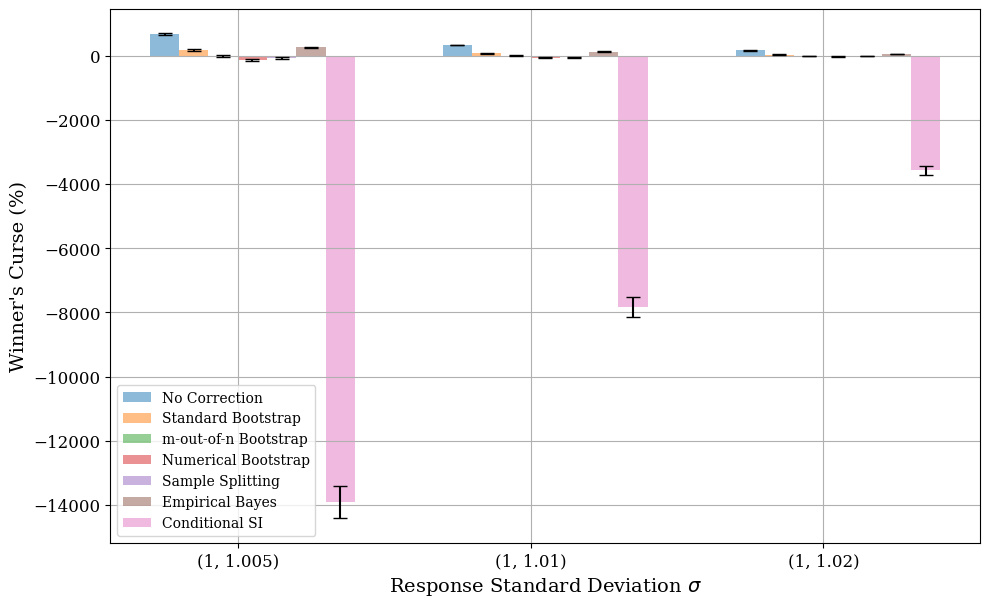

$\Delta\tau = 0.0$  \
                            $(\tau_1, \tau_2)$ = (1, 1.005)   
No Correction        Mean                            669.06   
                     Median                          692.03   
                     S.E.                             14.05   
Standard Bootstrap   Mean                            159.85   
                     Median                          180.37   
                     S.E.                             15.81   
m-out-of-n Bootstrap Mean                            -15.94   
                     Median                           13.84   
                     S.E.                             15.97   
Numerical Bootstrap  Mean                           -132.62   
                     Median                         -109.81   
                     S.E.                             17.08   
Sample Splitting     Mean                            -76.95   
                     Median                          -31.67   
                     S.E.                             20.60   
Empirical Bayes      Mean                            256.14   
                     Median                          315.45   
                     S.E.                             14.15   
Conditional SI       Mean                         -13915.71   
                     Median                       -10011.09   
                     S.E.                            258.33   

                                       $\Delta\tau = 0.01$  \
                            $(\tau_1, \tau_2)$ = (1, 1.01)   
No Correction        Mean                           331.81   
                     Median                         347.61   
                     S.E.                             7.04   
Standard Bootstrap   Mean                            79.23   
                     Median                          94.33   
                     S.E.                             7.93   
m-out-of-n Bootstrap Mean                            -9.78   
                     Median                           0.47   
                     S.E.                             8.01   
Numerical Bootstrap  Mean                           -64.44   
                     Median                         -51.53   
                     S.E.                             8.56   
Sample Splitting     Mean                           -48.53   
                     Median                         -18.14   
                     S.E.                             9.98   
Empirical Bayes      Mean                           125.37   
                     Median                         157.75   
                     S.E.                             7.08   
Conditional SI       Mean                         -7835.94   
                     Median                       -4966.76   
                     S.E.                           160.89   

                                       $\Delta\tau = 0.02$  
                            $(\tau_1, \tau_2)$ = (1, 1.02)  
No Correction        Mean                           160.23  
                     Median                         166.20  
                     S.E.                             3.55  
Standard Bootstrap   Mean                            34.56  
                     Median                          42.87  
                     S.E.                             4.01  
m-out-of-n Bootstrap Mean                            -9.02  
                     Median                          -0.82  
                     S.E.                             4.02  
Numerical Bootstrap  Mean                           -35.94  
                     Median                         -25.02  
                     S.E.                             4.29  
Sample Splitting     Mean                           -14.60  
                     Median                           5.78  
                     S.E.                             5.00  
Empirical Bayes      Mean                            57.52  
                     Median                          76.62  
     

In [18]:
# parameters
optimizer_key = 'rank_and_select'
result_dict = tau_result_dict.copy()

# Create a properly structured MultiIndex DataFrame for winner's curse statistics
data = {}

estimator_names = ['No Correction'] + [
    estimators_dict[est_key]['display_name'] 
    for est_key in estimators_dict.keys()
]

# For each delta tau value
for key in result_dict.keys():
    delta_tau = key[1] - key[0]

    data[key] = {}

    data[key]['No Correction'] = {
        'Mean': 100 / delta_tau * result_dict[key][f'{optimizer_key}_nc_wc_avg'],
        'Median': 100 / delta_tau * np.nanmedian(result_dict[key][f'{optimizer_key}_nc_wc_arr']),
        'S.E.': 100 / delta_tau * result_dict[key][f'{optimizer_key}_nc_wc_se']
    }
    
    # Get data for each estimator
    for i, est_key in enumerate([k for k in estimators_dict.keys()]):
        est_name = estimator_names[i+1]
        
        # Extract values
        mean_wc = 100 / delta_tau * result_dict[key][f'{optimizer_key}_{est_key}_wc_avg']
        median_wc = 100 / delta_tau * np.nanmedian(result_dict[key][f'{optimizer_key}_{est_key}_wc_arr'])
        se_wc = 100 / delta_tau * result_dict[key][f'{optimizer_key}_{est_key}_wc_se']
        
        # Store in nested dictionary
        data[key][est_name] = {
            'Mean': mean_wc, 'Median': median_wc, 'S.E.': se_wc
        }

# Create the MultiIndex DataFrame
row_index = pd.MultiIndex.from_product([
    estimator_names, ['Mean', 'Median', 'S.E.']
])
col_index = pd.MultiIndex.from_tuples([
    (f'$\\Delta\tau = {np.round(key[1] - key[0], 2)}$', '$(\tau_1, \tau_2)$ = ({}, {})'.format(key[0], key[1]))
    for key in result_dict.keys()
])

# Prepare data for DataFrame
df_data = []
for key in result_dict.keys():
    column_data = []
    for est_name in estimator_names:
        for stat in ['Mean', 'Median', 'S.E.']:
            column_data.append(data[key][est_name][stat])
    df_data.append(column_data)

# Create DataFrame with two-level column MultiIndex: Ratio and parameter info
wc_stats_df = pd.DataFrame(
    np.array(df_data).T,
    index=row_index,
    columns=col_index, 
)


""" 
Visualize the Winner's Curse
"""
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

n_estimators = len(estimators_dict.keys())
bar_positions = np.arange(len(tau_list))
bar_width = 0.1 * n_estimators

# plot the bars
for idx, estimator in enumerate(estimator_names):
    
    bar_values = [data[p][estimator]['Mean'] for p in tau_list]
    bar_errors = [1.96 * data[p][estimator]['S.E.'] for p in tau_list]

    ax.bar(
        bar_positions - bar_width / 2 + idx * bar_width / n_estimators + bar_width / 2 / n_estimators,
        bar_values, yerr=bar_errors, capsize=5,
        label=estimator, alpha=0.5, width=bar_width / n_estimators
    )

ax.set_xlabel(r'Response Standard Deviation $\sigma$', fontsize=axis_label_size)
ax.set_ylabel('Winner\'s Curse (%)', fontsize=axis_label_size)
ax.set_xticks(
    np.arange(len(tau_list)), labels=tau_list, 
)
ax.tick_params(axis='both', labelsize=tick_label_size)
ax.legend()
ax.grid()
plt.tight_layout()
plt.show()

# delete all variables in this cell
del data, estimator_names, df_data, idx, bar_positions, bar_width, bar_values, bar_errors, optimizer_key
del result_dict

# Display the DataFrame
wc_stats_df.round(2)

In [19]:
# parameters
optimizer_key = 'rank_and_select'
result_dict = tau_result_dict.copy()

# Create a properly structured MultiIndex DataFrame for winner's curse statistics
data = {}

estimator_names = ['No Correction'] + [
    estimators_dict[est_key]['display_name'] 
    for est_key in estimators_dict.keys()
]

# For each delta tau value
for key in result_dict.keys():
    delta_tau = key[1] - key[0]

    data[key] = {}

    wc_mean = result_dict[key][f'{optimizer_key}_nc_wc_avg'] / delta_tau * 100
    wc_se = result_dict[key][f'{optimizer_key}_nc_wc_se'] / delta_tau * 100
    sig_level = significance_level(wc_mean, wc_se)
    sig_level = '^{' + sig_level + '}' if sig_level != '' else ''
    data[key]['No Correction'] = "\\begin{tabular}[c]{@{}c@{}}" + f"${wc_mean:.2f}\%" + sig_level + f"$\\\\ (${wc_se:.2f}$)\%" + "\end{tabular}"

    # Get data for each estimator
    for i, est_key in enumerate([k for k in estimators_dict.keys()]):
        est_name = estimator_names[i+1]
        
        # Extract values
        wc_mean = result_dict[key][f'{optimizer_key}_{est_key}_wc_avg'] / delta_tau * 100
        wc_se = result_dict[key][f'{optimizer_key}_{est_key}_wc_se'] / delta_tau * 100
        sig_level = significance_level(wc_mean, wc_se)
        sig_level = '^{' + sig_level + '}' if sig_level != '' else ''
        data[key][est_name] = "\\begin{tabular}[c]{@{}c@{}}" + f"${wc_mean:.2f}\%" + sig_level + f"$\\\\ (${wc_se:.2f}$)\%" + "\end{tabular}"

# Create the MultiIndex DataFrame
col_index = pd.MultiIndex.from_tuples([
    (f'$\Delta\\tau = {np.round(key[1] - key[0], 2)}$', '$(\\tau_1, \\tau_2)$ = ({}, {})'.format(key[0], key[1]))
    for key in result_dict.keys()
])

# Prepare data for DataFrame
df_data = []
for key in result_dict.keys():
    column_data = []
    for est_name in estimator_names:
            column_data.append(data[key][est_name])
    df_data.append(column_data)

# Create DataFrame with two-level column MultiIndex: Ratio and parameter info
latex_df = pd.DataFrame(
    np.array(df_data).T,
    index=estimator_names,
    columns=col_index
)
print(latex_df.style.to_latex(
    column_format='c' * (2 * 3 + 1), 
    hrules=True
))


\begin{tabular}{ccccccc}
\toprule
 & $\Delta\tau = 0.0$ & $\Delta\tau = 0.01$ & $\Delta\tau = 0.02$ \\
 & $(\tau_1, \tau_2)$ = (1, 1.005) & $(\tau_1, \tau_2)$ = (1, 1.01) & $(\tau_1, \tau_2)$ = (1, 1.02) \\
\midrule
No Correction & \begin{tabular}[c]{@{}c@{}}$669.06\%^{***}$\\ ($14.05$)\%\end{tabular} & \begin{tabular}[c]{@{}c@{}}$331.81\%^{***}$\\ ($7.04$)\%\end{tabular} & \begin{tabular}[c]{@{}c@{}}$160.23\%^{***}$\\ ($3.55$)\%\end{tabular} \\
Standard Bootstrap & \begin{tabular}[c]{@{}c@{}}$159.85\%^{***}$\\ ($15.81$)\%\end{tabular} & \begin{tabular}[c]{@{}c@{}}$79.23\%^{***}$\\ ($7.93$)\%\end{tabular} & \begin{tabular}[c]{@{}c@{}}$34.56\%^{***}$\\ ($4.01$)\%\end{tabular} \\
m-out-of-n Bootstrap & \begin{tabular}[c]{@{}c@{}}$-15.94\%$\\ ($15.97$)\%\end{tabular} & \begin{tabular}[c]{@{}c@{}}$-9.78\%$\\ ($8.01$)\%\end{tabular} & \begin{tabular}[c]{@{}c@{}}$-9.02\%^{**}$\\ ($4.02$)\%\end{tabular} \\
Numerical Bootstrap & \begin{tabular}[c]{@{}c@{}}$-132.62\%^{***}$\\ ($17.08$)\%\end{ta

In [20]:
policy_comp_dict = {
    'Clairvoyant Policy': {}, 
    'Policy (Entire Dataset)': {},
    'Policy (Half Dataset)': {},
}

for delta_tau_tuple, wc_measures_dict in tau_result_dict.items():
    delta_tau = delta_tau_tuple[1] - delta_tau_tuple[0]
    ratio = delta_tau / 1.0 * 100
    # clairvoyant policy
    clairvoyant_val = 1 + delta_tau
    policy_comp_dict['Clairvoyant Policy'][f'$\Delta\\tau / \sigma = {ratio:.1f}\%$'] = f"{clairvoyant_val:.4f}"

    # focal policy
    nc_val_true_avg  = wc_measures_dict[f'{optimizer_key}_nc_val_true_avg']
    nc_val_true_se = wc_measures_dict[f'{optimizer_key}_nc_val_true_se']
    policy_comp_dict['Policy (Entire Dataset)'][f'$\Delta\\tau / \sigma = {ratio:.1f}\%$'] = "\\begin{tabular}[c]{@{}c@{}}" + f"${nc_val_true_avg:.4f}" + f"$\\\\ (${nc_val_true_se:.4f}$)" + "\end{tabular}"

    # sample splitting
    ss_val_true_avg = wc_measures_dict[f'{optimizer_key}_sample_splitting_val_true_avg']
    ss_val_true_se = wc_measures_dict[f'{optimizer_key}_sample_splitting_val_true_se']
    policy_comp_dict['Policy (Half Dataset)'][f'$\Delta\\tau / \sigma = {ratio:.1f}\%$'] = "\\begin{tabular}[c]{@{}c@{}}" + f"${ss_val_true_avg:.4f}" + f"$\\\\ (${ss_val_true_se:.4f}$)" + "\end{tabular}"

# Create DataFrame
policy_comp_df = pd.DataFrame(policy_comp_dict).T 
policy_comp_df
print(policy_comp_df.style.to_latex(
    column_format='cccc',  
    hrules=True
))

\begin{tabular}{cccc}
\toprule
 & $\Delta\tau / \sigma = 0.5\%$ & $\Delta\tau / \sigma = 1.0\%$ & $\Delta\tau / \sigma = 2.0\%$ \\
\midrule
Clairvoyant Policy & 1.0050 & 1.0100 & 1.0200 \\
Policy (Entire Dataset) & \begin{tabular}[c]{@{}c@{}}$1.0014$\\ ($0.0034$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$1.0044$\\ ($0.0034$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$1.0114$\\ ($0.0035$)\end{tabular} \\
Policy (Half Dataset) & \begin{tabular}[c]{@{}c@{}}$1.0014$\\ ($0.0034$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$1.0042$\\ ($0.0034$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$1.0106$\\ ($0.0035$)\end{tabular} \\
\bottomrule
\end{tabular}



In [21]:
for key, value in tau_result_dict.items():
    delta_tau = key[1] - key[0]
    agree_pct_avg = (value['rank_and_select_nc_selection_arr'] == value['rank_and_select_sample_splitting_selection_arr']).mean(axis=1).mean()
    agree_pct_std = (value['rank_and_select_nc_selection_arr'] == value['rank_and_select_sample_splitting_selection_arr']).mean(axis=1).std() / value['rank_and_select_nc_selection_arr'].shape[0] ** 0.5

    print(f"delta_tau: {delta_tau:.3f}, agree_pct_avg: {agree_pct_avg:.4%} +/- {agree_pct_std:.4%}")

delta_tau: 0.005, agree_pct_avg: 71.2920% +/- 0.7223%
delta_tau: 0.010, agree_pct_avg: 71.4240% +/- 0.7551%
delta_tau: 0.020, agree_pct_avg: 72.7960% +/- 0.7284%


In [22]:
wc_measures_dict = tau_result_dict[(1.00, 1.01)]

In [23]:
np.mean(wc_measures_dict[f'{optimizer_key}_conditional_si_val_est_arr']), np.mean(wc_measures_dict[f'{optimizer_key}_conditional_si_wc_arr'])/ 0.01 * 100

(0.21992479482626007, -7835.939193907984)

In [24]:
np.median(wc_measures_dict[f'{optimizer_key}_conditional_si_val_est_arr']), np.median(wc_measures_dict[f'{optimizer_key}_conditional_si_wc_arr'])/ 0.01 * 100

(0.48831355123595804, -4966.758513025843)

### Correct Functional Form

In [25]:
optimization_params = {
    'rank_and_select': {
        'optimizer': optimize, 'params': {}, 'display_name': 'Rank and Select'
    }
}

dgp_params = {
    'base_effect_vars': [None, None], 
    'cust_feat_var': UnivariateGaussian(0, 1), 
    'char_func': lambda x: x**2 + x, 
    'noise_var': UnivariateGaussian(0, 1), 
    'response_type': 'continuous', 
    'dgp_seed': 0
}

data_params = {'sample_size': 2500, 'targ_sample_size': 100} 

experiment_params = {
    'n_repeats': 500, 
    'estimator': {
        'estimator': EstimateWithKnownFunctionalForm, 
        'params': {
            'n_treatments': len(dgp_params['base_effect_vars']), 
            'fit_intercept': False
        }
    }
}

estimators_dict = {
    'standard_bootstrap': {
        'estimator': bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 100, 'n_jobs': -1}, 
        'display_name': 'Standard Bootstrap'
    },
    'mn_bootstrap': {
        'estimator': bootstrap_correction_estimate, 
        'params': {'bootstrap_method': 'm_out_of_n', 'n_bootstraps': 100, 'power': 0.95, 'n_jobs': -1}, 
        'display_name': 'm-out-of-n Bootstrap'
    },
    'num_bootstrap': {
        'estimator': bootstrap_correction_estimate, 
        'params': {'bootstrap_method': 'numerical', 'n_bootstraps': 100, 'power': -0.45, 'n_jobs': -1}, 
        'display_name': 'Numerical Bootstrap'
    }, 
    # 'bayes_normal': {
    #     'estimator': bayes_estimate, 
    #     'params': {'prior': 'normal', 'prior_mean': 0.0, 'prior_std': 1.0},
    #     'display_name': 'Shrinkage'
    # }, 
    'sample_splitting': {
        'estimator': sample_splitting_estimate, 
        'params': {'estimation_split': 0.5, }, 
        'display_name': 'Sample Splitting', 
    }, 
    'eb_normal': {
        'estimator': empirical_bayes_estimate, 
        'params': {'prior': 'normal', 'dof': 3, 'bin_width': 0.2}, 
        'display_name': 'Empirical Bayes'
    }, 
    # 'eb_spike_slab': {
    #     'estimator': empirical_bayes_estimate, 
    #     'params': {'prior': 'spike_slab', 'pi': 0.5},
    #     'display_name': 'EB (Spike-and-Slab)'
    # }, 
    'conditional_si': {
        'estimator': selective_inference_estimate,
        'params': {'method': 'conditional', 'quantile': 0.5, 'n_jobs': -1}, 
        'display_name': 'Conditional SI'
    }, 
    # 'hybrid_si': {
    #     'estimator': selective_inference_estimate,
    #     'params': {'method': 'hybrid', 'quantile': 0.5, 'n_jobs': -1}, 
    #     'display_name': 'Hybrid SI'
    # }, 
}

tau_list = [
    (1, 1.005), (1, 1.01), (1, 1.02), 
    # (1, 1.1), (2, 2.1), (3, 3.1), (1, 1.5)
]

In [26]:
tau_result_dict = {tau: None for tau in tau_list}

for te_tuple in tau_list:
    print(f'\n(tau_1, tau_2)= {te_tuple}')
    
    dgp_params['base_effect_vars'] = [PointMass(te_tuple[0]), PointMass(te_tuple[1])]

    result_records = repeated_experiment(
        optimization_params=optimization_params, 
        dgp_params=dgp_params, 
        data_params=data_params, 
        experiment_params=experiment_params, 
        estimators_dict=estimators_dict, 
        verbose=True, 
        n_jobs=-1
    )

    tau_result_dict[te_tuple] = calculate_winners_curse_measures(
        result_records=result_records, 
        optimization_params=optimization_params, 
        estimators_dict=estimators_dict, 
        data_params=data_params
    )


(tau_1, tau_2)= (1, 1.005)
Running 500 experiments...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:   16.4s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:   26.1s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:   30.2s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



(tau_1, tau_2)= (1, 1.01)
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:    5.9s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:   15.2s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:   18.9s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



(tau_1, tau_2)= (1, 1.02)
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:    5.8s
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed:   15.3s
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed:   19.6s finished


In [27]:
with open('results/targeting_ccf_delta_tau.pkl', 'wb') as f:
    pickle.dump(tau_result_dict, f)

with open('results/targeting_ccf_delta_tau.pkl', 'rb') as f:
    tau_result_dict = pickle.load(f)

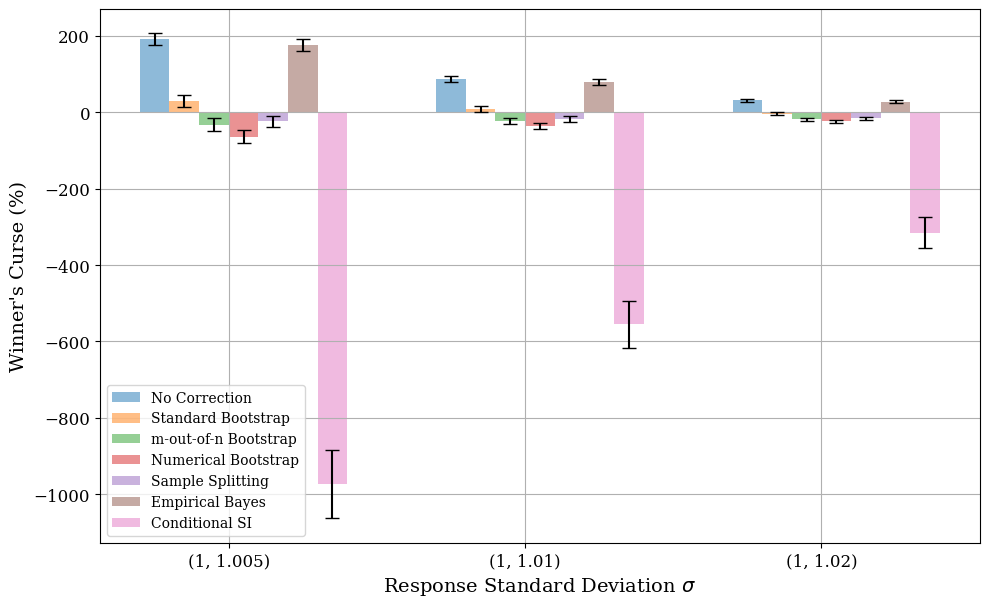

$\Delta\tau = 0.0$  \
                            $(\tau_1, \tau_2)$ = (1, 1.005)   
No Correction        Mean                            191.10   
                     Median                          189.06   
                     S.E.                              7.94   
Standard Bootstrap   Mean                             29.16   
                     Median                           24.27   
                     S.E.                              8.29   
m-out-of-n Bootstrap Mean                            -32.66   
                     Median                          -31.49   
                     S.E.                              8.28   
Numerical Bootstrap  Mean                            -63.92   
                     Median                          -81.21   
                     S.E.                              8.49   
Sample Splitting     Mean                            -23.76   
                     Median                          -23.36   
                     S.E.                              7.45   
Empirical Bayes      Mean                            176.10   
                     Median                          175.69   
                     S.E.                              7.94   
Conditional SI       Mean                           -973.48   
                     Median                         -381.30   
                     S.E.                             45.83   

                                       $\Delta\tau = 0.01$  \
                            $(\tau_1, \tau_2)$ = (1, 1.01)   
No Correction        Mean                            87.32   
                     Median                          87.88   
                     S.E.                             3.99   
Standard Bootstrap   Mean                             8.61   
                     Median                           7.57   
                     S.E.                             4.15   
m-out-of-n Bootstrap Mean                           -22.05   
                     Median                         -21.54   
                     S.E.                             4.16   
Numerical Bootstrap  Mean                           -36.27   
                     Median                         -38.59   
                     S.E.                             4.26   
Sample Splitting     Mean                           -18.62   
                     Median                         -21.36   
                     S.E.                             3.79   
Empirical Bayes      Mean                            79.84   
                     Median                          80.18   
                     S.E.                             3.98   
Conditional SI       Mean                          -555.21   
                     Median                        -162.84   
                     S.E.                            31.11   

                                       $\Delta\tau = 0.02$  
                            $(\tau_1, \tau_2)$ = (1, 1.02)  
No Correction        Mean                            30.70  
                     Median                          30.26  
                     S.E.                             2.03  
Standard Bootstrap   Mean                            -3.82  
                     Median                          -3.20  
                     S.E.                             2.13  
m-out-of-n Bootstrap Mean                           -18.53  
                     Median                         -18.25  
                     S.E.                             2.14  
Numerical Bootstrap  Mean                           -23.87  
                     Median                         -25.06  
                     S.E.                             2.19  
Sample Splitting     Mean                           -16.17  
                     Median                         -17.94  
                     S.E.                             1.96  
Empirical Bayes      Mean                            27.00  
                     Median                          26.09  
     

In [28]:
# parameters
optimizer_key = 'rank_and_select'
result_dict = tau_result_dict.copy()

# Create a properly structured MultiIndex DataFrame for winner's curse statistics
data = {}

estimator_names = ['No Correction'] + [
    estimators_dict[est_key]['display_name'] 
    for est_key in estimators_dict.keys()
]

# For each delta tau value
for key in result_dict.keys():
    delta_tau = key[1] - key[0]

    data[key] = {}

    data[key]['No Correction'] = {
        'Mean': 100 / delta_tau * result_dict[key][f'{optimizer_key}_nc_wc_avg'],
        'Median': 100 / delta_tau * np.nanmedian(result_dict[key][f'{optimizer_key}_nc_wc_arr']),
        'S.E.': 100 / delta_tau * result_dict[key][f'{optimizer_key}_nc_wc_se']
    }
    
    # Get data for each estimator
    for i, est_key in enumerate([k for k in estimators_dict.keys()]):
        est_name = estimator_names[i+1]
        
        # Extract values
        mean_wc = 100 / delta_tau * result_dict[key][f'{optimizer_key}_{est_key}_wc_avg']
        median_wc = 100 / delta_tau * np.nanmedian(result_dict[key][f'{optimizer_key}_{est_key}_wc_arr'])
        se_wc = 100 / delta_tau * result_dict[key][f'{optimizer_key}_{est_key}_wc_se']
        
        # Store in nested dictionary
        data[key][est_name] = {
            'Mean': mean_wc, 'Median': median_wc, 'S.E.': se_wc
        }

# Create the MultiIndex DataFrame
row_index = pd.MultiIndex.from_product([
    estimator_names, ['Mean', 'Median', 'S.E.']
])
col_index = pd.MultiIndex.from_tuples([
    (f'$\\Delta\tau = {np.round(key[1] - key[0], 2)}$', '$(\tau_1, \tau_2)$ = ({}, {})'.format(key[0], key[1]))
    for key in result_dict.keys()
])

# Prepare data for DataFrame
df_data = []
for key in result_dict.keys():
    column_data = []
    for est_name in estimator_names:
        for stat in ['Mean', 'Median', 'S.E.']:
            column_data.append(data[key][est_name][stat])
    df_data.append(column_data)

# Create DataFrame with two-level column MultiIndex: Ratio and parameter info
wc_stats_df = pd.DataFrame(
    np.array(df_data).T,
    index=row_index,
    columns=col_index, 
)


""" 
Visualize the Winner's Curse
"""
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

n_estimators = len(estimators_dict.keys())
bar_positions = np.arange(len(tau_list))
bar_width = 0.1 * n_estimators

# plot the bars
for idx, estimator in enumerate(estimator_names):
    
    bar_values = [data[p][estimator]['Mean'] for p in tau_list]
    bar_errors = [1.96 * data[p][estimator]['S.E.'] for p in tau_list]

    ax.bar(
        bar_positions - bar_width / 2 + idx * bar_width / n_estimators + bar_width / 2 / n_estimators,
        bar_values, yerr=bar_errors, capsize=5,
        label=estimator, alpha=0.5, width=bar_width / n_estimators
    )

ax.set_xlabel(r'Response Standard Deviation $\sigma$', fontsize=axis_label_size)
ax.set_ylabel('Winner\'s Curse (%)', fontsize=axis_label_size)
ax.set_xticks(
    np.arange(len(tau_list)), labels=tau_list, 
)
ax.tick_params(axis='both', labelsize=tick_label_size)
ax.legend()
ax.grid()
plt.tight_layout()
plt.show()

# delete all variables in this cell
del data, estimator_names, df_data, idx, bar_positions, bar_width, bar_values, bar_errors, optimizer_key
del result_dict

# Display the DataFrame
wc_stats_df.round(2)

In [29]:
# parameters
optimizer_key = 'rank_and_select'
result_dict = tau_result_dict.copy()

# Create a properly structured MultiIndex DataFrame for winner's curse statistics
data = {}

estimator_names = ['No Correction'] + [
    estimators_dict[est_key]['display_name'] 
    for est_key in estimators_dict.keys()
]

# For each delta tau value
for key in result_dict.keys():
    delta_tau = key[1] - key[0]

    data[key] = {}

    wc_mean = result_dict[key][f'{optimizer_key}_nc_wc_avg'] / delta_tau * 100
    wc_se = result_dict[key][f'{optimizer_key}_nc_wc_se'] / delta_tau * 100
    sig_level = significance_level(wc_mean, wc_se)
    sig_level = '^{' + sig_level + '}' if sig_level != '' else ''
    data[key]['No Correction'] = "\\begin{tabular}[c]{@{}c@{}}" + f"${wc_mean:.2f}\%" + sig_level + f"$\\\\ (${wc_se:.2f}$)\%" + "\end{tabular}"

    # Get data for each estimator
    for i, est_key in enumerate([k for k in estimators_dict.keys()]):
        est_name = estimator_names[i+1]
        
        # Extract values
        wc_mean = result_dict[key][f'{optimizer_key}_{est_key}_wc_avg'] / delta_tau * 100
        wc_se = result_dict[key][f'{optimizer_key}_{est_key}_wc_se'] / delta_tau * 100
        sig_level = significance_level(wc_mean, wc_se)
        sig_level = '^{' + sig_level + '}' if sig_level != '' else ''
        data[key][est_name] = "\\begin{tabular}[c]{@{}c@{}}" + f"${wc_mean:.2f}\%" + sig_level + f"$\\\\ (${wc_se:.2f}$)\%" + "\end{tabular}"

# Create the MultiIndex DataFrame
col_index = pd.MultiIndex.from_tuples([
    (f'$\Delta\\tau = {np.round(key[1] - key[0], 2)}$', '$(\\tau_1, \\tau_2)$ = ({}, {})'.format(key[0], key[1]))
    for key in result_dict.keys()
])

# Prepare data for DataFrame
df_data = []
for key in result_dict.keys():
    column_data = []
    for est_name in estimator_names:
            column_data.append(data[key][est_name])
    df_data.append(column_data)

# Create DataFrame with two-level column MultiIndex: Ratio and parameter info
latex_df = pd.DataFrame(
    np.array(df_data).T,
    index=estimator_names,
    columns=col_index
)
print(latex_df.style.to_latex(
    column_format='c' * (2 * 3 + 1), 
    hrules=True
))


\begin{tabular}{ccccccc}
\toprule
 & $\Delta\tau = 0.0$ & $\Delta\tau = 0.01$ & $\Delta\tau = 0.02$ \\
 & $(\tau_1, \tau_2)$ = (1, 1.005) & $(\tau_1, \tau_2)$ = (1, 1.01) & $(\tau_1, \tau_2)$ = (1, 1.02) \\
\midrule
No Correction & \begin{tabular}[c]{@{}c@{}}$191.10\%^{***}$\\ ($7.94$)\%\end{tabular} & \begin{tabular}[c]{@{}c@{}}$87.32\%^{***}$\\ ($3.99$)\%\end{tabular} & \begin{tabular}[c]{@{}c@{}}$30.70\%^{***}$\\ ($2.03$)\%\end{tabular} \\
Standard Bootstrap & \begin{tabular}[c]{@{}c@{}}$29.16\%^{***}$\\ ($8.29$)\%\end{tabular} & \begin{tabular}[c]{@{}c@{}}$8.61\%^{**}$\\ ($4.15$)\%\end{tabular} & \begin{tabular}[c]{@{}c@{}}$-3.82\%^{*}$\\ ($2.13$)\%\end{tabular} \\
m-out-of-n Bootstrap & \begin{tabular}[c]{@{}c@{}}$-32.66\%^{***}$\\ ($8.28$)\%\end{tabular} & \begin{tabular}[c]{@{}c@{}}$-22.05\%^{***}$\\ ($4.16$)\%\end{tabular} & \begin{tabular}[c]{@{}c@{}}$-18.53\%^{***}$\\ ($2.14$)\%\end{tabular} \\
Numerical Bootstrap & \begin{tabular}[c]{@{}c@{}}$-63.92\%^{***}$\\ ($8.49$)\%\end

In [30]:
policy_comp_dict = {
    'Clairvoyant Policy': {}, 
    'Policy (Entire Dataset)': {},
    'Policy (Half Dataset)': {},
}

for delta_tau_tuple, wc_measures_dict in tau_result_dict.items():
    delta_tau = delta_tau_tuple[1] - delta_tau_tuple[0]
    ratio = delta_tau / 1.0 * 100
    # clairvoyant policy
    clairvoyant_val = 1 + delta_tau
    policy_comp_dict['Clairvoyant Policy'][f'$\Delta\\tau / \sigma = {ratio:.1f}\%$'] = f"{clairvoyant_val:.4f}"

    # focal policy
    nc_val_true_avg  = wc_measures_dict[f'{optimizer_key}_nc_val_true_avg']
    nc_val_true_se = wc_measures_dict[f'{optimizer_key}_nc_val_true_se']
    policy_comp_dict['Policy (Entire Dataset)'][f'$\Delta\\tau / \sigma = {ratio:.1f}\%$'] = "\\begin{tabular}[c]{@{}c@{}}" + f"${nc_val_true_avg:.4f}" + f"$\\\\ (${nc_val_true_se:.4f}$)" + "\end{tabular}"

    # sample splitting
    ss_val_true_avg = wc_measures_dict[f'{optimizer_key}_sample_splitting_val_true_avg']
    ss_val_true_se = wc_measures_dict[f'{optimizer_key}_sample_splitting_val_true_se']
    policy_comp_dict['Policy (Half Dataset)'][f'$\Delta\\tau / \sigma = {ratio:.1f}\%$'] = "\\begin{tabular}[c]{@{}c@{}}" + f"${ss_val_true_avg:.4f}" + f"$\\\\ (${ss_val_true_se:.4f}$)" + "\end{tabular}"

# Create DataFrame
policy_comp_df = pd.DataFrame(policy_comp_dict).T 
policy_comp_df
print(policy_comp_df.style.to_latex(
    column_format='cccc',  
    hrules=True
))

\begin{tabular}{cccc}
\toprule
 & $\Delta\tau / \sigma = 0.5\%$ & $\Delta\tau / \sigma = 1.0\%$ & $\Delta\tau / \sigma = 2.0\%$ \\
\midrule
Clairvoyant Policy & 1.0050 & 1.0100 & 1.0200 \\
Policy (Entire Dataset) & \begin{tabular}[c]{@{}c@{}}$1.0017$\\ ($0.0034$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$1.0056$\\ ($0.0035$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$1.0160$\\ ($0.0035$)\end{tabular} \\
Policy (Half Dataset) & \begin{tabular}[c]{@{}c@{}}$1.0015$\\ ($0.0034$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$1.0052$\\ ($0.0035$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$1.0145$\\ ($0.0035$)\end{tabular} \\
\bottomrule
\end{tabular}



In [31]:
for key, value in tau_result_dict.items():
    delta_tau = key[1] - key[0]
    agree_pct_avg = (value['rank_and_select_nc_selection_arr'] == value['rank_and_select_sample_splitting_selection_arr']).mean(axis=1).mean()
    agree_pct_std = (value['rank_and_select_nc_selection_arr'] == value['rank_and_select_sample_splitting_selection_arr']).mean(axis=1).std() / value['rank_and_select_nc_selection_arr'].shape[0] ** 0.5

    print(f"delta_tau: {delta_tau:.3f}, agree_pct_avg: {agree_pct_avg:.4%} +/- {agree_pct_std:.4%}")

delta_tau: 0.005, agree_pct_avg: 73.6400% +/- 1.3207%
delta_tau: 0.010, agree_pct_avg: 74.8460% +/- 1.2676%
delta_tau: 0.020, agree_pct_avg: 77.7700% +/- 1.1130%


## Sample Size

In [8]:
optimization_params = {
    'rank_and_select': {
        'optimizer': optimize, 'params': {}, 'display_name': 'Rank and Select'
    }
}

dgp_params = {
    'base_effect_vars': [PointMass(1), PointMass(1.05)], 
    'cust_feat_var': UnivariateGaussian(0, 1), 
    'char_func': lambda x: x**2 + x, 
    'noise_var': UnivariateGaussian(0, 1), 
    'response_type': 'continuous', 
    'dgp_seed': 0
}

data_params = {'sample_size': None, 'targ_sample_size': 100} 

experiment_params = {
    'n_repeats': 500, 
    'estimator': {
        'estimator': CausalForestDML, 
        'params': {
            'n_treatments': len(dgp_params['base_effect_vars']), 
            'model_t': LogisticRegression(C=0.01), 
            'model_y': Lasso(alpha=0.01), 
            'n_estimators': 100, 
            'max_depth': 5, 
            'n_jobs': -1, 
            'discrete_treatment': True
        }
    }
}

estimators_dict = {
    'sample_splitting': {
        'estimator': sample_splitting_estimate, 
        'params': {'estimation_split': 0.5, }, 
        'display_name': 'Sample Splitting', 
    }, 
    'standard_bootstrap': {
        'estimator': bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 100, 'n_jobs': -1}, 
        'display_name': 'Standard Bootstrap'
    },
    'mn_bootstrap': {
        'estimator': bootstrap_correction_estimate, 
        'params': {'bootstrap_method': 'm_out_of_n', 'n_bootstraps': 100, 'power': 0.95, 'n_jobs': -1}, 
        'display_name': 'm-out-of-n Bootstrap'
    },
    'num_bootstrap': {
        'estimator': bootstrap_correction_estimate, 
        'params': {'bootstrap_method': 'numerical', 'n_bootstraps': 100, 'power': -0.45, 'n_jobs': -1}, 
        'display_name': 'Numerical Bootstrap'
    }, 
    # 'bayes_normal': {
    #     'estimator': bayes_estimate, 
    #     'params': {'prior': 'normal', 'prior_mean': 0.0, 'prior_std': 1.0},
    #     'display_name': 'Bayesian'
    # }, 
    'eb_normal': {
        'estimator': empirical_bayes_estimate, 
        'params': {'prior': 'normal', 'dof': 3, 'bin_width': 0.2}, 
        'display_name': 'Empirical Bayes'
    },
    # 'eb_spike_slab': {
    #     'estimator': empirical_bayes_estimate, 
    #     'params': {'prior': 'spike_slab', 'pi': 0.5},
    #     'display_name': 'EB (Spike-and-Slab)'
    # }, 
    'conditional_si': {
        'estimator': selective_inference_estimate,
        'params': {'method': 'conditional', 'quantile': 0.5, 'n_jobs': -1}, 
        'display_name': 'Conditional SI'
    }, 
    # 'hybrid_si': {
    #     'estimator': selective_inference_estimate,
    #     'params': {'method': 'hybrid', 'quantile': 0.5, 'n_jobs': -1}, 
    #     'display_name': 'Hybrid SI'
    # }, 
}

sample_size_list = [100, 500, 1000, 2500, 5000, 10000]

In [9]:
sample_size_result_dict = {sample_size: None for sample_size in sample_size_list}

for sample_size in sample_size_list:
    print(f'\nSample Size= {sample_size}')

    data_params['sample_size'] = sample_size    

    result_records = repeated_experiment(
        optimization_params=optimization_params, 
        dgp_params=dgp_params, 
        data_params=data_params, 
        experiment_params=experiment_params, 
        estimators_dict=estimators_dict, 
        verbose=True, 
        n_jobs=-1
    )

    sample_size_result_dict[sample_size] = calculate_winners_curse_measures(
        result_records=result_records, 
        optimization_params=optimization_params, 
        estimators_dict=estimators_dict, 
        data_params=data_params
    )


Sample Size= 100
Running 500 experiments...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed:  8.2min
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed: 21.8min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed: 27.6min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



Sample Size= 500
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed: 11.6min
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed: 33.4min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed: 42.4min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



Sample Size= 1000
Running 500 experiments...


...

[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed: 30.9min
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed: 82.5min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed: 104.6min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



Sample Size= 5000
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed: 62.0min
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed: 164.0min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed: 206.4min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



Sample Size= 10000
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed: 149.9min
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed: 389.1min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed: 476.5min finished


In [10]:
with open('results/targeting_sample_size.pkl', 'wb') as f:
    pickle.dump(sample_size_result_dict, f)

with open('results/targeting_sample_size.pkl', 'rb') as f:
    sample_size_result_dict = pickle.load(f)

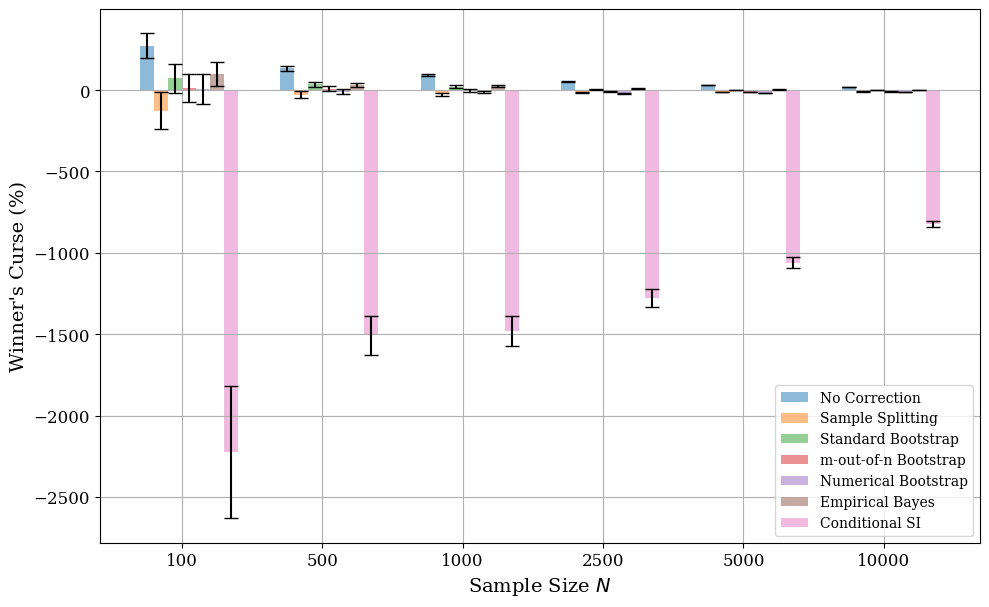

$N=100$  $N=500$  $N=1000$  $N=2500$  $N=5000$  \
No Correction        Mean     272.44   132.96     91.82     51.63     30.15   
                     Median   267.71   128.96     92.20     52.13     30.86   
                     S.E.      38.97     6.81      3.38      1.45      0.81   
Sample Splitting     Mean    -126.84   -28.03    -25.18    -13.11    -12.97   
                     Median   -74.25   -23.99    -19.36    -12.03    -12.04   
                     S.E.      57.07    10.41      5.04      2.01      1.10   
Standard Bootstrap   Mean      71.38    34.20     21.60      6.22      0.92   
                     Median    70.53    30.62     23.01      9.33      2.11   
                     S.E.      44.58     7.58      3.76      1.62      0.89   
m-out-of-n Bootstrap Mean      12.85     7.25     -1.95    -11.07    -11.55   
                     Median    -0.41     5.02      1.59     -7.76    -11.47   
                     S.E.      43.71     7.57      3.72      1.65      0.89   
Numerical Bootstrap  Mean       5.43   -11.02    -12.90    -19.34    -17.23   
                     Median   -17.59    -9.37    -12.32    -14.22    -14.18   
                     S.E.      46.96     8.01      4.01      1.75      0.96   
Empirical Bayes      Mean      99.83    30.81     23.41     11.40      2.93   
                     Median    92.94    34.23     23.24     18.82     10.56   
                     S.E.      38.11     6.95      3.48      1.45      0.87   
Conditional SI       Mean   -2224.64 -1508.15  -1480.76  -1279.96  -1060.64   
                     Median -1566.04 -1086.92  -1040.77   -752.58   -676.90   
                     S.E.     208.12    61.85     47.34     28.49     17.08   

                             $N=10000$  
No Correction        Mean        17.13  
                     Median      17.41  
                     S.E.         0.44  
Sample Splitting     Mean        -8.62  
                     Median      -3.90  
                     S.E.         0.57  
Standard Bootstrap   Mean        -0.67  
                     Median       1.78  
                     S.E.         0.49  
m-out-of-n Bootstrap Mean        -9.81  
                     Median      -8.07  
                     S.E.         0.49  
Numerical Bootstrap  Mean       -12.44  
                     Median     -11.52  
                     S.E.         0.52  
Empirical Bayes      Mean         0.13  
                     Median       2.16  
                     S.E.         0.45  
Conditional SI       Mean      -822.59  
                     Median    -516.97  
                     S.E.        10.04

In [13]:
# parameters
optimizer_key = 'rank_and_select'
result_dict = sample_size_result_dict.copy()
delta_tau = dgp_params['base_effect_vars'][1].mean - dgp_params['base_effect_vars'][0].mean

# Create a properly structured MultiIndex DataFrame for winner's curse statistics
data = {}

estimator_names = ['No Correction'] + [
    estimators_dict[est_key]['display_name'] 
    for est_key in estimators_dict.keys()
]

# For each delta tau value
for sample_size in sample_size_list:
    data[sample_size] = {}

    data[sample_size]['No Correction'] = {
        'Mean': 100 / delta_tau * result_dict[sample_size][f'{optimizer_key}_nc_wc_avg'],
        'Median': 100 / delta_tau * np.nanmedian(result_dict[sample_size][f'{optimizer_key}_nc_wc_arr']),
        'S.E.': 100 / delta_tau * result_dict[sample_size][f'{optimizer_key}_nc_wc_se']
    }
    
    # Get data for each estimator
    for i, est_key in enumerate([k for k in estimators_dict.keys()]):
        est_name = estimator_names[i+1]
        
        # Extract values
        mean_wc = 100 / delta_tau * result_dict[sample_size][f'{optimizer_key}_{est_key}_wc_avg']
        median_wc = 100 / delta_tau * np.nanmedian(result_dict[sample_size][f'{optimizer_key}_{est_key}_wc_arr'])
        se_wc = 100 / delta_tau * result_dict[sample_size][f'{optimizer_key}_{est_key}_wc_se']
        
        # Store in nested dictionary
        data[sample_size][est_name] = {
            'Mean': mean_wc, 'Median': median_wc, 'S.E.': se_wc
        }

# Create the MultiIndex DataFrame
index = pd.MultiIndex.from_product([
    estimator_names, ['Mean', 'Median', 'S.E.']
])

# Prepare data for DataFrame
df_data = []
for sample_size in sample_size_list:
    column_data = []
    for est_name in estimator_names:
        for stat in ['Mean', 'Median', 'S.E.']:
            column_data.append(data[sample_size][est_name][stat])
    df_data.append(column_data)

# Create DataFrame
wc_stats_df = pd.DataFrame(
    np.array(df_data).T,
    index=index,
    columns=[r'$N={}$'.format(s_) for s_ in sample_size_list]
)


""" 
Visualize the Winner's Curse as a function of the treatment effect difference
"""

# plot the winner's curse as a function of the number of experiments
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

n_estimators = len(estimators_dict.keys())
bar_positions = np.arange(len(sample_size_list))
bar_width = 0.1 * n_estimators


# plot the bars
for idx, estimator in enumerate(estimator_names):
    
    bar_values = [data[s_][estimator]['Mean'] for s_ in sample_size_list]
    bar_errors = [1.96 * data[s_][estimator]['S.E.'] for s_ in sample_size_list]

    ax.bar(
        bar_positions - bar_width / 2 + idx * bar_width / n_estimators + bar_width / 2 / n_estimators,
        bar_values, yerr=bar_errors, capsize=5,
        label=estimator, alpha=0.5, width=bar_width / n_estimators
    )

ax.set_xlabel(r'Sample Size $N$', fontsize=axis_label_size)
ax.set_ylabel('Winner\'s Curse (%)', fontsize=axis_label_size)
ax.set_xticks(
    np.arange(len(sample_size_list)), labels=sample_size_list, 
)
ax.tick_params(axis='both', labelsize=tick_label_size)
ax.legend()
ax.grid()
plt.tight_layout()
plt.show()

# delete all variables in this cell
del data, estimator_names, df_data, estimator, idx, bar_positions, bar_width, bar_values, bar_errors, n_estimators, optimizer_key
del result_dict

# Display the DataFrame
wc_stats_df.round(2)

In [ ]:
# parameters
optimizer_key = 'rank_and_select'
result_dict = sample_size_result_dict.copy()
delta_tau = dgp_params['base_effect_vars'][1].mean - dgp_params['base_effect_vars'][0].mean

# Create a properly structured MultiIndex DataFrame for winner's curse statistics
data = {}

estimator_names = ['No Correction'] + [
    estimators_dict[est_key]['display_name'] 
    for est_key in estimators_dict.keys()
]

# For each delta tau value
for sample_size in sample_size_list:
    data[sample_size] = {}

    wc_mean = 100 / delta_tau * result_dict[sample_size][f'{optimizer_key}_nc_wc_avg']
    wc_se = 100 / delta_tau * result_dict[sample_size][f'{optimizer_key}_nc_wc_se']
    sig_level = significance_level(wc_mean, wc_se)
    sig_level = '^{' + sig_level + '}' if sig_level != '' else ''
    data[sample_size]['No Correction'] = "\\begin{tabular}[c]{@{}c@{}}" + f"${wc_mean:.2f}\%" + sig_level + f"$\\\\ (${wc_se:.2f}\%$)" + "\end{tabular}"
    
    # Get data for each estimator
    for i, est_key in enumerate([k for k in estimators_dict.keys()]):
        est_name = estimator_names[i+1]
        
        # Extract values
        wc_mean = 100 / delta_tau * result_dict[sample_size][f'{optimizer_key}_{est_key}_wc_avg']
        wc_se = 100 / delta_tau * result_dict[sample_size][f'{optimizer_key}_{est_key}_wc_se']
        sig_level = significance_level(wc_mean, wc_se)
        sig_level = '^{' + sig_level + '}' if sig_level != '' else ''
        data[sample_size][est_name] = "\\begin{tabular}[c]{@{}c@{}}" + f"${wc_mean:.2f}\%" + sig_level + f"$\\\\ (${wc_se:.2f}\%$)" + "\end{tabular}"

# Create DataFrame
latex_df = pd.DataFrame(data)
latex_df.columns = [f'$N={sample_size}$' for sample_size in sample_size_list]
print(latex_df.style.to_latex(
    column_format='c' * (len(sample_size_list) + 1), 
    hrules=True
))

\begin{tabular}{ccccccc}
\toprule
 & $N=100$ & $N=500$ & $N=1000$ & $N=2500$ & $N=5000$ & $N=10000$ \\
\midrule
No Correction & \begin{tabular}[c]{@{}c@{}}$272.44\%^{***}$\\ ($38.97\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$132.96\%^{***}$\\ ($6.81\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$91.82\%^{***}$\\ ($3.38\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$51.63\%^{***}$\\ ($1.45\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$30.15\%^{***}$\\ ($0.81\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$17.13\%^{***}$\\ ($0.44\%$)\end{tabular} \\
Standard Bootstrap & \begin{tabular}[c]{@{}c@{}}$71.38\%$\\ ($44.58\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$34.20\%^{***}$\\ ($7.58\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$21.60\%^{***}$\\ ($3.76\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$6.22\%^{***}$\\ ($1.62\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$0.92\%$\\ ($0.89\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$-0.67\%$\\ ($0.49\%$)\end{tabular} \\
m-out-of-n Bo

## Response STD

In [41]:
optimization_params = {
    'rank_and_select': {
        'optimizer': optimize, 'params': {}, 'display_name': 'Rank and Select'
    }
}

dgp_params = {
    'base_effect_vars': [PointMass(1), PointMass(1.1)], 
    'cust_feat_var': UnivariateGaussian(0, 1), 
    'char_func': lambda x: x**2 + x, 
    'noise_var': None, 
    'response_type': 'continuous', 
    'dgp_seed': 0
}

data_params = {'sample_size': 100, 'targ_sample_size': 100} 

experiment_params = {
    'n_repeats': 500, 
    'estimator': {
        'estimator': CausalForestDML, 
        'params': {
            'n_treatments': len(dgp_params['base_effect_vars']), 
            'model_t': LogisticRegression(C=0.01), 
            'model_y': Lasso(alpha=0.01), 
            'n_estimators': 100, 
            'max_depth': 5, 
            'n_jobs': -1, 
            'discrete_treatment': True
        }
    }
}

estimators_dict = {
    'sample_splitting': {
        'estimator': sample_splitting_estimate, 
        'params': {'estimation_split': 0.5, }, 
        'display_name': 'Sample Splitting', 
    }, 
    'standard_bootstrap': {
        'estimator': bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 100, 'n_jobs': -1}, 
        'display_name': 'Standard Bootstrap'
    },
    'mn_bootstrap': {
        'estimator': bootstrap_correction_estimate, 
        'params': {'bootstrap_method': 'm_out_of_n', 'n_bootstraps': 100, 'power': 0.95, 'n_jobs': -1}, 
        'display_name': 'm-out-of-n Bootstrap'
    },
    'num_bootstrap': {
        'estimator': bootstrap_correction_estimate, 
        'params': {'bootstrap_method': 'numerical', 'n_bootstraps': 100, 'power': -0.45, 'n_jobs': -1}, 
        'display_name': 'Numerical Bootstrap'
    }, 
    # 'bayes_normal': {
    #     'estimator': bayes_estimate, 
    #     'params': {'prior': 'normal', 'prior_mean': 0.0, 'prior_std': 1.0},
    #     'display_name': 'Shrinkage'
    # }, 
    'eb_normal': {
        'estimator': empirical_bayes_estimate, 
        'params': {'prior': 'normal', 'dof': 3, 'bin_width': 0.2}, 
        'display_name': 'Empirical Bayes'
    },
    # 'eb_spike_slab': {
    #     'estimator': empirical_bayes_estimate, 
    #     'params': {'prior': 'spike_slab', 'pi': 0.5},
    #     'display_name': 'EB (Spike-and-Slab)'
    # }, 
    'conditional_si': {
        'estimator': selective_inference_estimate,
        'params': {'method': 'conditional', 'quantile': 0.5, 'n_jobs': -1}, 
        'display_name': 'Conditional SI'
    }, 
    # 'hybrid_si': {
    #     'estimator': selective_inference_estimate,
    #     'params': {'method': 'hybrid', 'quantile': 0.5, 'n_jobs': -1}, 
    #     'display_name': 'Hybrid SI'
    # }, 
}

response_std_list = [0.5, 1, 2, 3, 4, 5]

In [99]:
response_std_result_dict = {response_std: None for response_std in response_std_list}

for response_std in response_std_list:
    print(f'\nNoise Standard Deviation= {response_std}')

    dgp_params['noise_var'] = UnivariateGaussian(0, response_std)  

    result_records = repeated_experiment(
        optimization_params=optimization_params, 
        dgp_params=dgp_params, 
        data_params=data_params, 
        experiment_params=experiment_params, 
        estimators_dict=estimators_dict, 
        verbose=True, 
        n_jobs=1
    )

    response_std_result_dict[response_std] = calculate_winners_curse_measures(
        result_records=result_records, 
        optimization_params=optimization_params, 
        estimators_dict=estimators_dict, 
        data_params=data_params
    )


Noise Standard Deviation= 0.5
Running 500 experiments...


[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done 500 out of 500 | elapsed:  1.1min finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.



Noise Standard Deviation= 1
Running 500 experiments...


[Parallel(n_jobs=1)]: Done 500 out of 500 | elapsed:  1.1min finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.



Noise Standard Deviation= 2
Running 500 experiments...


...

[Parallel(n_jobs=1)]: Done 500 out of 500 | elapsed:  1.1min finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.



Noise Standard Deviation= 4
Running 500 experiments...


[Parallel(n_jobs=1)]: Done 500 out of 500 | elapsed:  1.1min finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.



Noise Standard Deviation= 5
Running 500 experiments...


[Parallel(n_jobs=1)]: Done 500 out of 500 | elapsed:  1.1min finished


In [42]:
# with open('results/targeting_response_std.pkl', 'wb') as f:
#     pickle.dump(response_std_result_dict, f)

with open('results/targeting_response_std.pkl', 'rb') as f:
    response_std_result_dict = pickle.load(f)

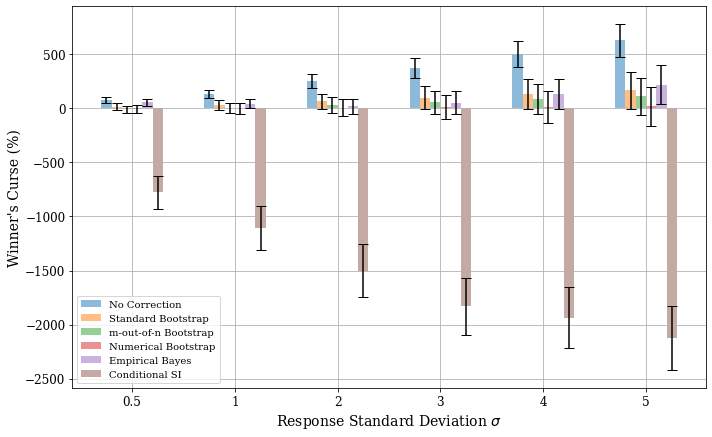

$\sigma=0.5$  $\sigma=1$  $\sigma=2$  $\sigma=3$  \
No Correction        Mean           78.00      130.72      249.76      374.32   
                     Median         80.32      124.98      258.49      386.94   
                     S.E.           14.78       19.89       33.02       47.37   
Standard Bootstrap   Mean           13.89       31.81       63.96       97.61   
                     Median          5.42       30.06       45.59       83.37   
                     S.E.           17.03       22.65       37.15       53.40   
m-out-of-n Bootstrap Mean           -9.93        3.23       29.11       57.21   
                     Median        -17.02        7.87       24.52       43.21   
                     S.E.           16.56       22.18       37.31       53.96   
Numerical Bootstrap  Mean           -7.16       -1.32        6.83       10.96   
                     Median        -16.84      -11.86       -5.26       -6.50   
                     S.E.           18.22       23.94       39.08       56.29   
Empirical Bayes      Mean           54.81       42.42       18.98       52.78   
                     Median         46.53       41.40       14.94       69.48   
                     S.E.           17.24       21.65       35.37       53.45   
Conditional SI       Mean         -778.27    -1106.05    -1502.88    -1831.24   
                     Median       -564.30     -805.94    -1262.16    -1591.80   
                     S.E.           78.54      104.41      125.60      135.18   

                             $\sigma=4$  $\sigma=5$  
No Correction        Mean        501.77      630.13  
                     Median      519.39      642.96  
                     S.E.         62.23       77.25  
Standard Bootstrap   Mean        135.09      166.42  
                     Median      121.50      176.77  
                     S.E.         70.08       87.07  
m-out-of-n Bootstrap Mean         88.72      111.44  
                     Median       90.82      120.23  
                     S.E.         71.18       88.08  
Numerical Bootstrap  Mean         13.51       18.17  
                     Median       -7.00        2.42  
                     S.E.         74.14       91.57  
Empirical Bayes      Mean        132.00      217.48  
                     Median      187.06      277.58  
                     S.E.         72.47       91.49  
Conditional SI       Mean      -1937.45    -2127.18  
                     Median    -1770.98    -2037.11  
                     S.E.        143.31      151.48

In [43]:
# parameters
optimizer_key = 'rank_and_select'
result_dict = response_std_result_dict.copy()
delta_tau = dgp_params['base_effect_vars'][1].mean - dgp_params['base_effect_vars'][0].mean

# Create a properly structured MultiIndex DataFrame for winner's curse statistics
data = {}

estimator_names = ['No Correction'] + [
    estimators_dict[est_key]['display_name'] 
    for est_key in estimators_dict.keys() if est_key != 'sample_splitting'
]

# For each delta tau value
for response_std in response_std_list:
    data[response_std] = {}

    data[response_std]['No Correction'] = {
        'Mean': 100 / delta_tau * result_dict[response_std][f'{optimizer_key}_nc_wc_avg'],
        'Median': 100 / delta_tau * np.nanmedian(result_dict[response_std][f'{optimizer_key}_nc_wc_arr']),
        'S.E.': 100 / delta_tau * result_dict[response_std][f'{optimizer_key}_nc_wc_se']
    }
    
    # Get data for each estimator
    for i, est_key in enumerate([k for k in estimators_dict.keys() if k != 'sample_splitting']):
        est_name = estimator_names[i+1]
        
        # Extract values
        mean_wc = 100 / delta_tau * result_dict[response_std][f'{optimizer_key}_{est_key}_wc_avg']
        median_wc = 100 / delta_tau * np.nanmedian(result_dict[response_std][f'{optimizer_key}_{est_key}_wc_arr'])
        se_wc = 100 / delta_tau * result_dict[response_std][f'{optimizer_key}_{est_key}_wc_se']
        
        # Store in nested dictionary
        data[response_std][est_name] = {
            'Mean': mean_wc, 'Median': median_wc, 'S.E.': se_wc
        }

# Create the MultiIndex DataFrame
index = pd.MultiIndex.from_product([
    estimator_names, ['Mean', 'Median', 'S.E.']
])

# Prepare data for DataFrame
df_data = []
for response_std in response_std_list:
    column_data = []
    for est_name in estimator_names:
        for stat in ['Mean', 'Median', 'S.E.']:
            column_data.append(data[response_std][est_name][stat])
    df_data.append(column_data)

# Create DataFrame
wc_stats_df = pd.DataFrame(
    np.array(df_data).T,
    index=index,
    columns=[r'$\sigma={}$'.format(p) for p in response_std_list]
)


""" 
Visualize the Winner's Curse as a function of the treatment effect difference
"""

# plot the winner's curse as a function of the number of experiments
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

n_estimators = len(estimators_dict.keys())
bar_positions = np.arange(len(response_std_list))
bar_width = 0.1 * n_estimators


# plot the bars
for idx, estimator in enumerate(estimator_names):
    
    bar_values = [data[p][estimator]['Mean'] for p in response_std_list]
    bar_errors = [1.96 * data[p][estimator]['S.E.'] for p in response_std_list]

    ax.bar(
        bar_positions - bar_width / 2 + idx * bar_width / n_estimators + bar_width / 2 / n_estimators,
        bar_values, yerr=bar_errors, capsize=5,
        label=estimator, alpha=0.5, width=bar_width / n_estimators
    )

ax.set_xlabel(r'Response Standard Deviation $\sigma$', fontsize=axis_label_size)
ax.set_ylabel('Winner\'s Curse (%)', fontsize=axis_label_size)
ax.set_xticks(
    np.arange(len(response_std_list)), labels=response_std_list, 
)
ax.tick_params(axis='both', labelsize=tick_label_size)
ax.legend()
ax.grid()
plt.tight_layout()
plt.show()

# delete all variables in this cell
del data, estimator_names, df_data, estimator, idx, bar_positions, bar_width, bar_values, bar_errors, n_estimators, optimizer_key
del result_dict

# Display the DataFrame
wc_stats_df.round(2)

In [46]:
# parameters
optimizer_key = 'rank_and_select'
result_dict = response_std_result_dict.copy()
delta_tau = dgp_params['base_effect_vars'][1].mean - dgp_params['base_effect_vars'][0].mean

# Create a properly structured MultiIndex DataFrame for winner's curse statistics
data = {}

estimator_names = ['No Correction'] + [
    estimators_dict[est_key]['display_name'] 
    for est_key in estimators_dict.keys() if est_key != 'sample_splitting'
]

# For each delta tau value
for response_std in response_std_list:
    data[response_std] = {}

    wc_mean = 100 / delta_tau * result_dict[response_std][f'{optimizer_key}_nc_wc_avg']
    wc_se = 100 / delta_tau * result_dict[response_std][f'{optimizer_key}_nc_wc_se']
    sig_level = significance_level(wc_mean, wc_se)
    sig_level = '^{' + sig_level + '}' if sig_level != '' else ''
    data[response_std]['No Correction'] = "\\begin{tabular}[c]{@{}c@{}}" + f"${wc_mean:.2f}\%" + sig_level + f"$\\\\ (${wc_se:.2f}\%$)" + "\end{tabular}"
    
    # Get data for each estimator
    for i, est_key in enumerate([k for k in estimators_dict.keys() if k != 'sample_splitting']):
        est_name = estimator_names[i+1]
        
        # Extract values
        wc_mean = 100 / delta_tau * result_dict[response_std][f'{optimizer_key}_{est_key}_wc_avg']
        wc_se = 100 / delta_tau * result_dict[response_std][f'{optimizer_key}_{est_key}_wc_se']
        sig_level = significance_level(wc_mean, wc_se)
        sig_level = '^{' + sig_level + '}' if sig_level != '' else ''
        data[response_std][est_name] = "\\begin{tabular}[c]{@{}c@{}}" + f"${wc_mean:.2f}\%" + sig_level + f"$\\\\ (${wc_se:.2f}\%$)" + "\end{tabular}"

# Create DataFrame
latex_df = pd.DataFrame(data)
latex_df.columns = [f'$\sigma={response_std}$' for response_std in response_std_list]
print(latex_df.style.to_latex(
    column_format='c' * (len(response_std_list) + 1), 
    hrules=True
))

\begin{tabular}{ccccccc}
\toprule
 & $\sigma=0.5$ & $\sigma=1$ & $\sigma=2$ & $\sigma=3$ & $\sigma=4$ & $\sigma=5$ \\
\midrule
No Correction & \begin{tabular}[c]{@{}c@{}}$78.00\%^{***}$\\ ($14.78\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$130.72\%^{***}$\\ ($19.89\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$249.76\%^{***}$\\ ($33.02\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$374.32\%^{***}$\\ ($47.37\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$501.77\%^{***}$\\ ($62.23\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$630.13\%^{***}$\\ ($77.25\%$)\end{tabular} \\
Standard Bootstrap & \begin{tabular}[c]{@{}c@{}}$13.89\%$\\ ($17.03\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$31.81\%$\\ ($22.65\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$63.96\%^{*}$\\ ($37.15\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$97.61\%^{*}$\\ ($53.40\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$135.09\%^{*}$\\ ($70.08\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$166.42\%^{*}$\\ ($87.07\%$)

## Functional Form

In [57]:
optimization_params = {
    'rank_and_select': {
        'optimizer': optimize, 'params': {}, 'display_name': 'Rank and Select'
    }
}

dgp_params = {
    'base_effect_vars': [PointMass(1), PointMass(1.01)], 
    'cust_feat_var': UnivariateGaussian(0, 1), 
    'char_func': None, 
    'noise_var': UnivariateGaussian(0, 1), 
    'response_type': 'continuous', 
    'dgp_seed': 0
}

data_params = {'sample_size': 2500, 'targ_sample_size': 100} 

experiment_params = {
    'n_repeats': 500, 
    'estimator': {
        'estimator': CausalForestDML, 
        'params': {
            'n_treatments': len(dgp_params['base_effect_vars']), 
            'model_t': LogisticRegression(C=0.01), 
            'model_y': Lasso(alpha=0.01), 
            'n_estimators': 100, 
            'max_depth': 5, 
            'n_jobs': -1, 
            'discrete_treatment': True
        }
    }
}

estimators_dict = {
    'sample_splitting': {
        'estimator': sample_splitting_estimate, 
        'params': {'estimation_split': 0.5, }, 
        'display_name': 'Sample Splitting', 
    }, 
    'standard_bootstrap': {
        'estimator': bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 100, 'n_jobs': -1}, 
        'display_name': 'Standard Bootstrap'
    },
    'mn_bootstrap': {
        'estimator': bootstrap_correction_estimate, 
        'params': {'bootstrap_method': 'm_out_of_n', 'n_bootstraps': 100, 'power': 0.95, 'n_jobs': -1}, 
        'display_name': 'm-out-of-n Bootstrap'
    },
    'num_bootstrap': {
        'estimator': bootstrap_correction_estimate, 
        'params': {'bootstrap_method': 'numerical', 'n_bootstraps': 100, 'power': -0.45, 'n_jobs': -1}, 
        'display_name': 'Numerical Bootstrap'
    }, 
    # 'bayes_normal': {
    #     'estimator': bayes_estimate, 
    #     'params': {'prior': 'normal', 'prior_mean': 0.0, 'prior_std': 1.0},
    #     'display_name': 'Bayesian'
    # }, 
    'eb_normal': {
        'estimator': empirical_bayes_estimate, 
        'params': {'prior': 'normal', 'dof': 3, 'bin_width': 0.2}, 
        'display_name': 'Empirical Bayes'
    }, 
    # 'eb_spike_slab': {
    #     'estimator': empirical_bayes_estimate, 
    #     'params': {'prior': 'spike_slab', 'pi': 0.5},
    #     'display_name': 'EB (Spike-and-Slab)'
    # }, 
    'conditional_si': {
        'estimator': selective_inference_estimate,
        'params': {'method': 'conditional', 'quantile': 0.5, 'n_jobs': -1}, 
        'display_name': 'Conditional SI'
    }, 
    # 'hybrid_si': {
    #     'estimator': selective_inference_estimate,
    #     'params': {'method': 'hybrid', 'quantile': 0.5, 'n_jobs': -1}, 
    #     'display_name': 'Hybrid SI'
    # }, 
}

char_func_dict = {
    r'$x$': lambda x: x,
    r'$x^2 + x$': lambda x: x**2 + x,
    r'$x^3$': lambda x: x**3,
    r'$|x|$': lambda x: np.abs(x),
}

In [13]:
char_func_result_dict = {k: None for k in char_func_dict.keys()}
for char_func in char_func_dict.keys():
    print(f'\nCharacterizing Function= {char_func}')

    dgp_params['char_func'] = char_func_dict[char_func]

    result_records = repeated_experiment(
        optimization_params=optimization_params, 
        dgp_params=dgp_params, 
        data_params=data_params, 
        experiment_params=experiment_params,
        estimators_dict=estimators_dict,
        verbose=True,
        n_jobs=-1
    )

    char_func_result_dict[char_func] = calculate_winners_curse_measures(
        result_records=result_records, 
        optimization_params=optimization_params, 
        estimators_dict=estimators_dict, 
        data_params=data_params
    )



Characterizing Function= $x$
Running 500 experiments...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed: 13.4min
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed: 35.8min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed: 45.3min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



Characterizing Function= $x^2 + x$
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed: 12.2min
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed: 33.9min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed: 43.3min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



Characterizing Function= $x^3$
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed: 12.4min
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed: 34.6min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed: 44.1min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



Characterizing Function= $|x|$
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed: 12.5min
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed: 34.8min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed: 44.6min finished


In [58]:
# with open('results/targeting_char_func.pkl', 'wb') as f:
#     pickle.dump(char_func_result_dict, f)

with open('results/targeting_char_func.pkl', 'rb') as f:
    char_func_result_dict = pickle.load(f)

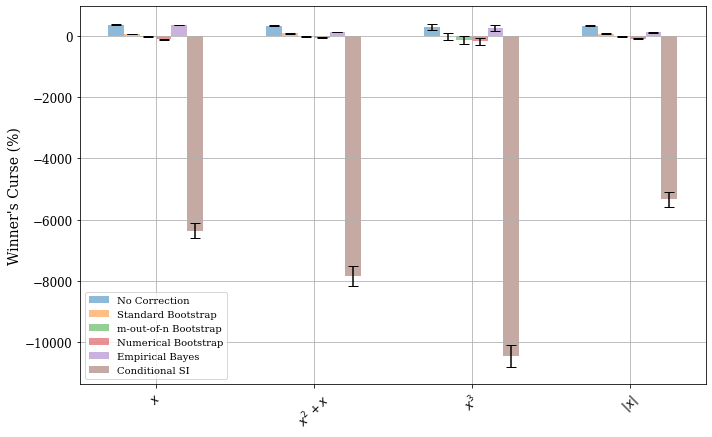

$x$  $x^2 + x$     $x^3$    $|x|$
No Correction        Mean     369.61     331.81    299.81   338.33
                     Median   358.95     347.61    332.53   326.07
                     S.E.       5.78       7.04     51.57     5.79
Standard Bootstrap   Mean      60.06      79.32    -10.36    68.11
                     Median    51.20      78.53     81.91    70.95
                     S.E.       6.55       7.88     57.24     6.52
m-out-of-n Bootstrap Mean     -20.96     -12.79   -128.86    -9.88
                     Median   -29.76       8.42    -34.87   -14.07
                     S.E.       6.63       8.02     67.52     6.61
Numerical Bootstrap  Mean    -116.44     -64.26   -177.12   -86.29
                     Median  -116.81     -58.19    -65.71   -90.31
                     S.E.       7.08       8.56     60.83     7.13
Empirical Bayes      Mean     357.26     125.37    269.11   120.97
                     Median   350.59     157.75    282.06   110.88
                     S.E.       5.82       7.08     51.63     5.77
Conditional SI       Mean   -6354.01   -7835.94 -10449.76 -5327.72
                     Median -4534.34   -4966.76  -7626.83 -3399.20
                     S.E.     128.35     160.89    185.27   124.46

In [59]:
# parameters
optimizer_key = 'rank_and_select'
result_dict = char_func_result_dict.copy()
delta_tau = dgp_params['base_effect_vars'][1].mean - dgp_params['base_effect_vars'][0].mean

# Create a properly structured MultiIndex DataFrame for winner's curse statistics
data = {}

estimator_names = ['No Correction'] + [
    estimators_dict[est_key]['display_name'] 
    for est_key in estimators_dict.keys() if est_key != 'sample_splitting'
]

# For each delta tau value
for char_func in char_func_dict.keys():
    data[char_func] = {}

    data[char_func]['No Correction'] = {
        'Mean': 100 / delta_tau * result_dict[char_func][f'{optimizer_key}_nc_wc_avg'],
        'Median': 100 / delta_tau * np.nanmedian(result_dict[char_func][f'{optimizer_key}_nc_wc_arr']),
        'S.E.': 100 / delta_tau * result_dict[char_func][f'{optimizer_key}_nc_wc_se']
    }
    
    # Get data for each estimator
    for i, est_key in enumerate([k for k in estimators_dict.keys() if k != 'sample_splitting']):
        est_name = estimator_names[i+1]
        
        # Extract values
        mean_wc = 100 / delta_tau * result_dict[char_func][f'{optimizer_key}_{est_key}_wc_avg']
        median_wc = 100 / delta_tau * np.nanmedian(result_dict[char_func][f'{optimizer_key}_{est_key}_wc_arr'])
        se_wc = 100 / delta_tau * result_dict[char_func][f'{optimizer_key}_{est_key}_wc_se']
        
        # Store in nested dictionary
        data[char_func][est_name] = {
            'Mean': mean_wc, 'Median': median_wc, 'S.E.': se_wc
        }

# Create the MultiIndex DataFrame
index = pd.MultiIndex.from_product([
    estimator_names, ['Mean', 'Median', 'S.E.']
])

# Prepare data for DataFrame
df_data = []
for noise_dstn in char_func_dict.keys():
    column_data = []
    for est_name in estimator_names:
        for stat in ['Mean', 'Median', 'S.E.']:
            column_data.append(data[noise_dstn][est_name][stat])
    df_data.append(column_data)

# Create DataFrame
wc_stats_df = pd.DataFrame(
    np.array(df_data).T,
    index=index,
    columns=list(char_func_dict.keys())
)


""" 
Visualize the Winner's Curse as a function of the treatment effect difference
"""

# plot the winner's curse as a function of the number of experiments
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

n_estimators = len(estimators_dict.keys())
bar_positions = np.arange(len(char_func_dict.keys()))
bar_width = 0.1 * n_estimators


# plot the bars
for idx, estimator in enumerate(estimator_names):
    
    bar_values = [data[p][estimator]['Mean'] for p in char_func_dict.keys()]
    bar_errors = [1.96 * data[p][estimator]['S.E.'] for p in char_func_dict.keys()]

    ax.bar(
        bar_positions - bar_width / 2 + idx * bar_width / n_estimators + bar_width / 2 / n_estimators,
        bar_values, yerr=bar_errors, capsize=5,
        label=estimator, alpha=0.5, width=bar_width / n_estimators
    )

ax.set_ylabel('Winner\'s Curse (%)', fontsize=axis_label_size)
ax.set_xticks(
    np.arange(len(char_func_dict.keys())), 
    labels=char_func_dict.keys(), 
    rotation=45
)
ax.tick_params(axis='both', labelsize=tick_label_size)
ax.legend()
ax.grid()
plt.tight_layout()
plt.show()

# delete all variables in this cell
del data, estimator_names, df_data, estimator, idx, bar_positions, bar_width, bar_values, bar_errors, n_estimators, optimizer_key
del result_dict

# Display the DataFrame
wc_stats_df.round(2)

In [61]:
# parameters
optimizer_key = 'rank_and_select'
result_dict = char_func_result_dict.copy()
delta_tau = dgp_params['base_effect_vars'][1].mean - dgp_params['base_effect_vars'][0].mean

# Create a properly structured MultiIndex DataFrame for winner's curse statistics
data = {}

estimator_names = ['No Correction'] + [
    estimators_dict[est_key]['display_name'] 
    for est_key in estimators_dict.keys()
]

# For each delta tau value
for char_func in char_func_dict.keys():
    data[char_func] = {}

    wc_mean = 100 / delta_tau * result_dict[char_func][f'{optimizer_key}_nc_wc_avg']
    wc_se = 100 / delta_tau * result_dict[char_func][f'{optimizer_key}_nc_wc_se']
    sig_level = significance_level(wc_mean, wc_se)
    sig_level = '^{' + sig_level + '}' if sig_level != '' else ''
    data[char_func]['No Correction'] = "\\begin{tabular}[c]{@{}c@{}}" + f"${wc_mean:.2f}\%" + sig_level + f"$\\\\ (${wc_se:.2f}\%$)" + "\end{tabular}"
    
    # Get data for each estimator
    for i, est_key in enumerate([k for k in estimators_dict.keys()]):
        est_name = estimator_names[i+1]
        
        # Extract values
        wc_mean = 100 / delta_tau * result_dict[char_func][f'{optimizer_key}_{est_key}_wc_avg']
        wc_se = 100 / delta_tau * result_dict[char_func][f'{optimizer_key}_{est_key}_wc_se']
        sig_level = significance_level(wc_mean, wc_se)
        sig_level = '^{' + sig_level + '}' if sig_level != '' else ''
        data[char_func][est_name] = "\\begin{tabular}[c]{@{}c@{}}" + f"${wc_mean:.2f}\%" + sig_level + f"$\\\\ (${wc_se:.2f}\%$)" + "\end{tabular}"

# Create DataFrame
latex_df = pd.DataFrame(data)
latex_df.columns = [char_func for char_func in char_func_dict.keys()]
print(latex_df.style.to_latex(
    column_format='c' * (len(char_func_dict) + 1), 
    hrules=True
))

\begin{tabular}{ccccc}
\toprule
 & $x$ & $x^2 + x$ & $x^3$ & $|x|$ \\
\midrule
No Correction & \begin{tabular}[c]{@{}c@{}}$369.61\%^{***}$\\ ($5.78\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$331.81\%^{***}$\\ ($7.04\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$299.81\%^{***}$\\ ($51.57\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$338.33\%^{***}$\\ ($5.79\%$)\end{tabular} \\
Sample Splitting & \begin{tabular}[c]{@{}c@{}}$14.58\%^{*}$\\ ($7.92\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$-20.63\%^{**}$\\ ($9.75\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$19.04\%$\\ ($25.10\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$10.18\%$\\ ($8.11\%$)\end{tabular} \\
Standard Bootstrap & \begin{tabular}[c]{@{}c@{}}$60.06\%^{***}$\\ ($6.55\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$79.32\%^{***}$\\ ($7.88\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$-10.36\%$\\ ($57.24\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$68.11\%^{***}$\\ ($6.52\%$)\end{tabular} \\
m-out-of-n Bootstrap &

## Noise Distribution

In [53]:
optimization_params = {
    'rank_and_select': {
        'optimizer': optimize, 'params': {}, 'display_name': 'Rank and Select'
    }
}

dgp_params = {
    'base_effect_vars': [PointMass(1), PointMass(1.01)], 
    'cust_feat_var': UnivariateGaussian(0, 1), 
    'char_func': lambda x: x**2 + x, 
    'noise_var': None, 
    'response_type': 'continuous', 
    'dgp_seed': 0
}

data_params = {'sample_size': 2500, 'targ_sample_size': 100} 

experiment_params = {
    'n_repeats': 500, 
    'estimator': {
        'estimator': CausalForestDML, 
        'params': {
            'n_treatments': len(dgp_params['base_effect_vars']), 
            'model_t': LogisticRegression(C=0.01), 
            'model_y': Lasso(alpha=0.01), 
            'n_estimators': 100, 
            'max_depth': 5, 
            'n_jobs': -1, 
            'discrete_treatment': True
        }
    }
}

estimators_dict = {
    'standard_bootstrap': {
        'estimator': bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 100, 'n_jobs': -1}, 
        'display_name': 'Standard Bootstrap'
    },
    'mn_bootstrap': {
        'estimator': bootstrap_correction_estimate, 
        'params': {'bootstrap_method': 'm_out_of_n', 'n_bootstraps': 100, 'power': 0.95, 'n_jobs': -1}, 
        'display_name': 'm-out-of-n Bootstrap'
    },
    'num_bootstrap': {
        'estimator': bootstrap_correction_estimate, 
        'params': {'bootstrap_method': 'numerical', 'n_bootstraps': 100, 'power': -0.45, 'n_jobs': -1}, 
        'display_name': 'Numerical Bootstrap'
    }, 
    'sample_splitting': {
        'estimator': sample_splitting_estimate, 
        'params': {'estimation_split': 0.5, }, 
        'display_name': 'Sample Splitting', 
    }, 
    # 'bayes_normal': {
    #     'estimator': bayes_estimate, 
    #     'params': {'prior': 'normal', 'prior_mean': 0.0, 'prior_std': 1.0},
    #     'display_name': 'Shrinkage'
    # }, 
    'eb_normal': {
        'estimator': empirical_bayes_estimate, 
        'params': {'prior': 'normal', 'dof': 3, 'bin_width': 0.2}, 
        'display_name': 'Empirical Bayes'
    },
    # 'eb_spike_slab': {
    #     'estimator': empirical_bayes_estimate, 
    #     'params': {'prior': 'spike_slab', 'pi': 0.5},
    #     'display_name': 'EB (Spike-and-Slab)'
    # }, 
    'conditional_si': {
        'estimator': selective_inference_estimate,
        'params': {'method': 'conditional', 'quantile': 0.5, 'n_jobs': -1}, 
        'display_name': 'Conditional SI'
    }, 
    # 'hybrid_si': {
    #     'estimator': selective_inference_estimate,
    #     'params': {'method': 'hybrid', 'quantile': 0.5, 'n_jobs': -1}, 
    #     'display_name': 'Hybrid SI'
    # }, 
}

noise_dstn_dict = {
    'Normal(0, 1)': UnivariateGaussian(0, std=1),
    'Uniform($-\\sqrt{3}$, $-\\sqrt{3}$)': Uniform(-3**0.5, 3**0.5),
    r'Laplace(0, $1/\sqrt{2}$)': Laplace(0, 1 / np.sqrt(2)), 
    r'Logistic(0, $\sqrt{3} / \pi$)': Logistic(0, np.sqrt(3) / np.pi), 
}

In [17]:
noise_dstn_result_dict = {k: None for k in noise_dstn_dict.keys()}

for noise_dstn in noise_dstn_dict.keys():
    print(f'\nNoise Distribution= {noise_dstn}')

    dgp_params['noise_var'] = noise_dstn_dict[noise_dstn]

    result_records = repeated_experiment(
        optimization_params=optimization_params, 
        dgp_params=dgp_params, 
        data_params=data_params, 
        experiment_params=experiment_params,
        estimators_dict=estimators_dict,
        verbose=True,
        n_jobs=1
    )

    noise_dstn_result_dict[noise_dstn] = calculate_winners_curse_measures(
        result_records=result_records, 
        optimization_params=optimization_params, 
        estimators_dict=estimators_dict, 
        data_params=data_params
    )


Noise Distribution= Normal(0, 1)
Running 500 experiments...


[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.
[Parallel(n_jobs=1)]: Done 500 out of 500 | elapsed: 45.5min finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.



Noise Distribution= Uniform($-\sqrt{3}$, $-\sqrt{3}$)
Running 500 experiments...


[Parallel(n_jobs=1)]: Done 500 out of 500 | elapsed: 46.1min finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.



Noise Distribution= Laplace(0, $1/\sqrt{2}$)
Running 500 experiments...


[Parallel(n_jobs=1)]: Done 500 out of 500 | elapsed: 46.3min finished
[Parallel(n_jobs=1)]: Using backend SequentialBackend with 1 concurrent workers.



Noise Distribution= Logistic(0, $\sqrt{3} / \pi$)
Running 500 experiments...


[Parallel(n_jobs=1)]: Done 500 out of 500 | elapsed: 46.4min finished


In [54]:
# with open('results/targeting_noise_dstn.pkl', 'wb') as f:
#     pickle.dump(noise_dstn_result_dict, f)

with open('results/targeting_noise_dstn.pkl', 'rb') as f:
    noise_dstn_result_dict = pickle.load(f)

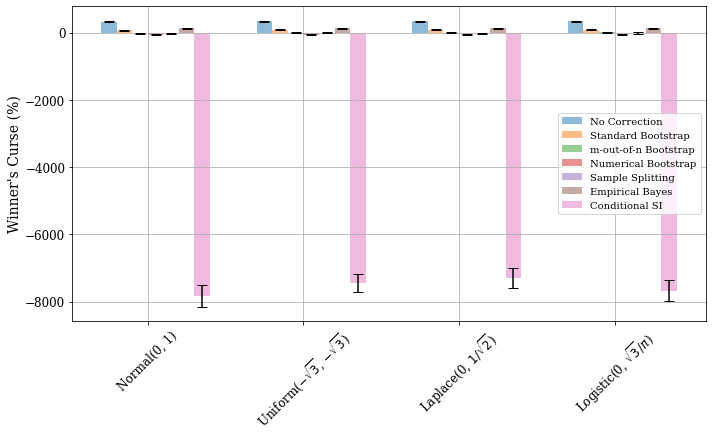

Normal(0, 1)  Uniform($-\sqrt{3}$, $-\sqrt{3}$)  \
No Correction        Mean          331.81                             339.03   
                     Median        347.61                             351.86   
                     S.E.            7.04                               7.65   
Standard Bootstrap   Mean           78.00                              83.60   
                     Median         94.05                              79.71   
                     S.E.            7.92                               8.62   
m-out-of-n Bootstrap Mean          -11.05                               1.41   
                     Median         -5.20                               3.15   
                     S.E.            8.05                               8.62   
Numerical Bootstrap  Mean          -62.23                             -59.72   
                     Median        -54.96                             -63.89   
                     S.E.            8.56                               9.20   
Sample Splitting     Mean          -20.63                              -2.80   
                     Median        -14.00                              20.40   
                     S.E.            9.75                              10.31   
Empirical Bayes      Mean          125.37                             131.53   
                     Median        157.75                             147.09   
                     S.E.            7.08                               7.96   
Conditional SI       Mean        -7835.94                           -7449.77   
                     Median      -4966.76                           -5032.27   
                     S.E.          160.89                             143.19   

                             Laplace(0, $1/\sqrt{2}$)  \
No Correction        Mean                      337.88   
                     Median                    343.74   
                     S.E.                        7.70   
Standard Bootstrap   Mean                       92.05   
                     Median                     99.15   
                     S.E.                        8.67   
m-out-of-n Bootstrap Mean                        5.04   
                     Median                      7.27   
                     S.E.                        8.75   
Numerical Bootstrap  Mean                      -50.15   
                     Median                    -46.37   
                     S.E.                        9.25   
Sample Splitting     Mean                      -18.10   
                     Median                    -19.01   
                     S.E.                       10.34   
Empirical Bayes      Mean                      129.34   
                     Median                    149.80   
                     S.E.                        7.95   
Conditional SI       Mean                    -7300.01   
                     Median                  -4902.84   
                     S.E.                      144.35   

                             Logistic(0, $\sqrt{3} / \pi$)  
No Correction        Mean                           340.13  
                     Median                         353.90  
                     S.E.                             7.72  
Standard Bootstrap   Mean                            91.17  
                     Median                          85.87  
                     S.E.                             8.74  
m-out-of-n Bootstrap Mean                             8.24  
                     Median                          -1.49  
                     S.E.                             8.72  
Numerical Bootstrap  Mean                           -44.01  
                     Median                         -60.86  
                     S.E.                             9.34  
Sample Splitting     Mean                           -14.81  
                     Median                          -4.40  
                     S.E.                            10.31  
Empirical Bayes      Mean            

In [55]:
# parameters
optimizer_key = 'rank_and_select'
result_dict = noise_dstn_result_dict.copy()
delta_tau = dgp_params['base_effect_vars'][1].mean - dgp_params['base_effect_vars'][0].mean

# Create a properly structured MultiIndex DataFrame for winner's curse statistics
data = {}

estimator_names = ['No Correction'] + [
    estimators_dict[est_key]['display_name'] 
    for est_key in estimators_dict.keys()
]

# For each delta tau value
for noise_dstn in noise_dstn_dict.keys():
    data[noise_dstn] = {}

    data[noise_dstn]['No Correction'] = {
        'Mean': 100 / delta_tau * result_dict[noise_dstn][f'{optimizer_key}_nc_wc_avg'],
        'Median': 100 / delta_tau * np.nanmedian(result_dict[noise_dstn][f'{optimizer_key}_nc_wc_arr']),
        'S.E.': 100 / delta_tau * result_dict[noise_dstn][f'{optimizer_key}_nc_wc_se']
    }
    
    # Get data for each estimator
    for i, est_key in enumerate([k for k in estimators_dict.keys()]):
        est_name = estimator_names[i+1]
        
        # Extract values
        mean_wc = 100 / delta_tau * result_dict[noise_dstn][f'{optimizer_key}_{est_key}_wc_avg']
        median_wc = 100 / delta_tau * np.nanmedian(result_dict[noise_dstn][f'{optimizer_key}_{est_key}_wc_arr'])
        se_wc = 100 / delta_tau * result_dict[noise_dstn][f'{optimizer_key}_{est_key}_wc_se']
        
        # Store in nested dictionary
        data[noise_dstn][est_name] = {
            'Mean': mean_wc, 'Median': median_wc, 'S.E.': se_wc
        }

# Create the MultiIndex DataFrame
index = pd.MultiIndex.from_product([
    estimator_names, ['Mean', 'Median', 'S.E.']
])

# Prepare data for DataFrame
df_data = []
for noise_dstn in noise_dstn_dict.keys():
    column_data = []
    for est_name in estimator_names:
        for stat in ['Mean', 'Median', 'S.E.']:
            column_data.append(data[noise_dstn][est_name][stat])
    df_data.append(column_data)

# Create DataFrame
wc_stats_df = pd.DataFrame(
    np.array(df_data).T,
    index=index,
    columns=list(noise_dstn_dict.keys())
)


""" 
Visualize the Winner's Curse as a function of the treatment effect difference
"""

# plot the winner's curse as a function of the number of experiments
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

n_estimators = len(estimators_dict.keys())
bar_positions = np.arange(len(noise_dstn_dict.keys()))
bar_width = 0.1 * n_estimators


# plot the bars
for idx, estimator in enumerate(estimator_names):
    
    bar_values = [data[p][estimator]['Mean'] for p in noise_dstn_dict.keys()]
    bar_errors = [1.96 * data[p][estimator]['S.E.'] for p in noise_dstn_dict.keys()]

    ax.bar(
        bar_positions - bar_width / 2 + idx * bar_width / n_estimators + bar_width / 2 / n_estimators,
        bar_values, yerr=bar_errors, capsize=5,
        label=estimator, alpha=0.5, width=bar_width / n_estimators
    )

ax.set_ylabel('Winner\'s Curse (%)', fontsize=axis_label_size)
ax.set_xticks(
    np.arange(len(noise_dstn_dict.keys())), 
    labels=noise_dstn_dict.keys(), 
    rotation=45
)
ax.tick_params(axis='both', labelsize=tick_label_size)
ax.legend()
ax.grid()
plt.tight_layout()
plt.show()

# delete all variables in this cell
del data, estimator_names, df_data, estimator, idx, bar_positions, bar_width, bar_values, bar_errors, n_estimators, optimizer_key
del result_dict

# Display the DataFrame
wc_stats_df.round(2)

In [56]:
# parameters
optimizer_key = 'rank_and_select'
result_dict = noise_dstn_result_dict.copy()
delta_tau = dgp_params['base_effect_vars'][1].mean - dgp_params['base_effect_vars'][0].mean
# Create a properly structured MultiIndex DataFrame for winner's curse statistics
data = {}

estimator_names = ['No Correction'] + [
    estimators_dict[est_key]['display_name'] 
    for est_key in estimators_dict.keys()
]

# For each delta tau value
for noise_dstn in noise_dstn_dict.keys():
    data[noise_dstn] = {}

    wc_mean = 100 / delta_tau * result_dict[noise_dstn][f'{optimizer_key}_nc_wc_avg']
    wc_se = 100 / delta_tau * result_dict[noise_dstn][f'{optimizer_key}_nc_wc_se']
    sig_level = significance_level(wc_mean, wc_se)
    sig_level = '^{' + sig_level + '}' if sig_level != '' else ''
    data[noise_dstn]['No Correction'] = "\\begin{tabular}[c]{@{}c@{}}" + f"${wc_mean:.2f}\%" + sig_level + f"$\\\\ (${wc_se:.2f}\%$)" + "\end{tabular}"
    
    # Get data for each estimator
    for i, est_key in enumerate([k for k in estimators_dict.keys()]):
        est_name = estimator_names[i+1]
        
        # Extract values
        wc_mean = 100 / delta_tau * result_dict[noise_dstn][f'{optimizer_key}_{est_key}_wc_avg']
        wc_se = 100 / delta_tau * result_dict[noise_dstn][f'{optimizer_key}_{est_key}_wc_se']
        sig_level = significance_level(wc_mean, wc_se)
        sig_level = '^{' + sig_level + '}' if sig_level != '' else ''
        data[noise_dstn][est_name] = "\\begin{tabular}[c]{@{}c@{}}" + f"${wc_mean:.2f}\%" + sig_level + f"$\\\\ (${wc_se:.2f}\%$)" + "\end{tabular}"

# Create DataFrame
latex_df = pd.DataFrame(data)
latex_df.columns = list(noise_dstn_dict.keys())
print(latex_df.style.to_latex(
    column_format='c' * (len(noise_dstn_dict) + 1), 
    hrules=True
))

\begin{tabular}{ccccc}
\toprule
 & Normal(0, 1) & Uniform($-\sqrt{3}$, $-\sqrt{3}$) & Laplace(0, $1/\sqrt{2}$) & Logistic(0, $\sqrt{3} / \pi$) \\
\midrule
No Correction & \begin{tabular}[c]{@{}c@{}}$331.81\%^{***}$\\ ($7.04\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$339.03\%^{***}$\\ ($7.65\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$337.88\%^{***}$\\ ($7.70\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$340.13\%^{***}$\\ ($7.72\%$)\end{tabular} \\
Standard Bootstrap & \begin{tabular}[c]{@{}c@{}}$78.00\%^{***}$\\ ($7.92\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$83.60\%^{***}$\\ ($8.62\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$92.05\%^{***}$\\ ($8.67\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$91.17\%^{***}$\\ ($8.74\%$)\end{tabular} \\
m-out-of-n Bootstrap & \begin{tabular}[c]{@{}c@{}}$-11.05\%$\\ ($8.05\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$1.41\%$\\ ($8.62\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$5.04\%$\\ ($8.75\%$)\end{tabular} & \begin{tabular}[c

## Multiple Treatments

In [15]:
optimization_params = {
    'rank_and_select': {
        'optimizer': optimize, 'params': {}, 'display_name': 'Rank and Select'
    }
}

dgp_params = {
    'base_effect_vars': None, 
    'cust_feat_var': UnivariateGaussian(0, 1), 
    'char_func': lambda x: x**2 + x, 
    'noise_var': UnivariateGaussian(0, 1), 
    'response_type': 'continuous', 
    'dgp_seed': 0
}

data_params = {'sample_size': 500, 'targ_sample_size': 100} 

experiment_params = {
    'n_repeats': 500, 
    'estimator': {
        'estimator': CausalForestDML, 
        'params': {
            'n_treatments': None, 
            'model_t': LogisticRegression(C=0.01), 
            'model_y': Lasso(alpha=0.01), 
            'n_estimators': 100, 
            'max_depth': 5, 
            'n_jobs': -1, 
            'discrete_treatment': True
        }
    }
}

estimators_dict = {
    'standard_bootstrap': {
        'estimator': bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 100, 'n_jobs': -1}, 
        'display_name': 'Standard Bootstrap'
    },
    'mn_bootstrap': {
        'estimator': bootstrap_correction_estimate, 
        'params': {'bootstrap_method': 'm_out_of_n', 'n_bootstraps': 100, 'power': 0.95, 'n_jobs': -1}, 
        'display_name': 'm-out-of-n Bootstrap'
    },
    'num_bootstrap': {
        'estimator': bootstrap_correction_estimate, 
        'params': {'bootstrap_method': 'numerical', 'n_bootstraps': 100, 'power': -0.45, 'n_jobs': -1}, 
        'display_name': 'Numerical Bootstrap'
    }, 
    'sample_splitting': {
        'estimator': sample_splitting_estimate, 
        'params': {'estimation_split': 0.5, }, 
        'display_name': 'Sample Splitting', 
    }, 
    # 'bayes_normal': {
    #     'estimator': bayes_estimate, 
    #     'params': {'prior': 'normal', 'prior_mean': 0.0, 'prior_std': 1.0},
    #     'display_name': 'Shrinkage'
    # }, 
    'eb_normal': {
        'estimator': empirical_bayes_estimate, 
        'params': {'prior': 'normal', 'dof': 3, 'bin_width': 0.2}, 
        'display_name': 'Empirical Bayes'
    }, 
    # 'eb_spike_slab': {
    #     'estimator': empirical_bayes_estimate, 
    #     'params': {'prior': 'spike_slab', 'pi': 0.5},
    #     'display_name': 'EB (Spike-and-Slab)'
    # }, 
    'conditional_si': {
        'estimator': selective_inference_estimate,
        'params': {'method': 'conditional', 'quantile': 0.5, 'n_jobs': -1}, 
        'display_name': 'Conditional SI'
    }, 
    # 'hybrid_si': {
    #     'estimator': selective_inference_estimate,
    #     'params': {'method': 'hybrid', 'quantile': 0.5, 'n_jobs': -1}, 
    #     'display_name': 'Hybrid SI'
    # }, 
}

n_treatments_list = [2, 4, 6, 8, 10]
delta_tau = 0.0

In [22]:
n_treatments_result_dict = {n_treatments: None for n_treatments in n_treatments_list}

for n_treatments in n_treatments_list:
    print(f'\nNumber of Treatments= {n_treatments}')

    dgp_params['base_effect_vars'] = [PointMass(1 + i * delta_tau) for i in range(n_treatments)]
    experiment_params['estimator']['params']['n_treatments'] = n_treatments

    result_records = repeated_experiment(
        optimization_params=optimization_params, 
        dgp_params=dgp_params, 
        data_params=data_params, 
        experiment_params=experiment_params,
        estimators_dict=estimators_dict,
        verbose=True,
        n_jobs=-1
    )

    n_treatments_result_dict[n_treatments] = calculate_winners_curse_measures(
        result_records=result_records, 
        optimization_params=optimization_params, 
        estimators_dict=estimators_dict, 
        data_params=data_params
    )


Number of Treatments= 2
Running 500 experiments...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed: 11.8min
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed: 34.3min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed: 43.2min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



Number of Treatments= 4
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed: 21.1min
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed: 60.0min
A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed: 76.8min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



Number of Treatments= 6
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed: 49.8min
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed: 129.6min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed: 159.9min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



Number of Treatments= 8
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed: 100.3min
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed: 256.4min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed: 319.6min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



Number of Treatments= 10
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed: 178.9min
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed: 465.4min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed: 591.0min finished


In [16]:
# with open('results/targeting_n_treatments.pkl', 'wb') as f:
#     pickle.dump(n_treatments_result_dict, f)

with open('results/targeting_n_treatments.pkl', 'rb') as f:
    n_treatments_result_dict = pickle.load(f)

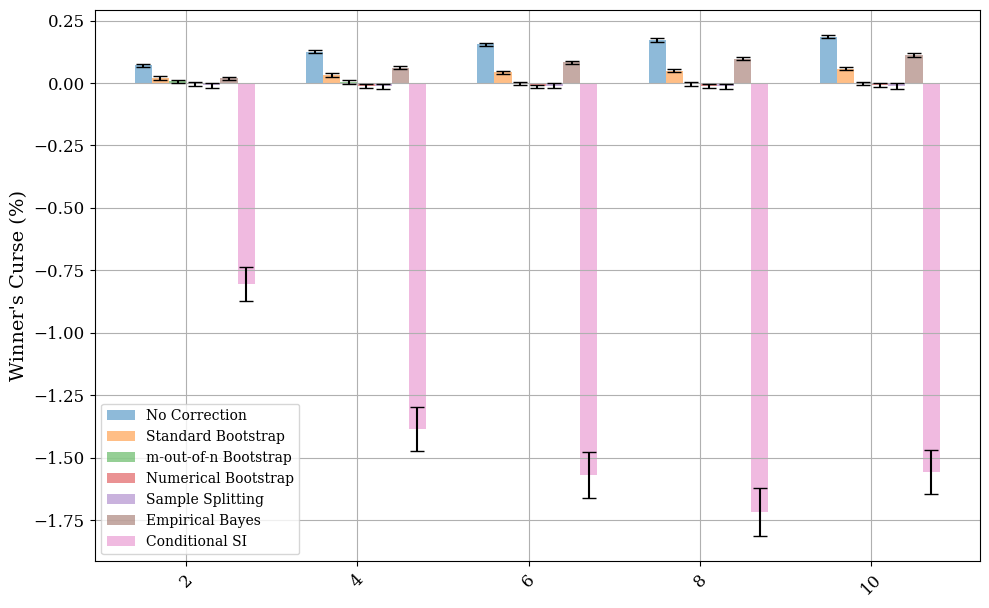

2     4     6     8     10
No Correction        Mean    0.07  0.13  0.15  0.17  0.19
                     Median  0.07  0.12  0.15  0.17  0.18
                     S.E.    0.00  0.00  0.00  0.00  0.00
Standard Bootstrap   Mean    0.02  0.03  0.04  0.05  0.06
                     Median  0.02  0.03  0.04  0.05  0.05
                     S.E.    0.00  0.00  0.00  0.00  0.00
m-out-of-n Bootstrap Mean    0.01  0.00 -0.00 -0.00 -0.00
                     Median  0.00 -0.00 -0.00 -0.00 -0.01
                     S.E.    0.00  0.00  0.00  0.00  0.00
Numerical Bootstrap  Mean   -0.00 -0.01 -0.01 -0.01 -0.01
                     Median -0.01 -0.02 -0.02 -0.01 -0.01
                     S.E.    0.00  0.00  0.00  0.00  0.00
Sample Splitting     Mean   -0.01 -0.01 -0.01 -0.01 -0.01
                     Median -0.01 -0.02 -0.01 -0.01 -0.02
                     S.E.    0.00  0.00  0.00  0.01  0.01
Empirical Bayes      Mean    0.02  0.06  0.08  0.10  0.11
                     Median  0.02  0.06  0.08  0.10  0.11
                     S.E.    0.00  0.00  0.00  0.00  0.00
Conditional SI       Mean   -0.81 -1.39 -1.57 -1.72 -1.56
                     Median -0.58 -1.12 -1.30 -1.44 -1.35
                     S.E.    0.03  0.04  0.05  0.05  0.05

In [17]:
# parameters
optimizer_key = 'rank_and_select'
result_dict = n_treatments_result_dict.copy()

# Create a properly structured MultiIndex DataFrame for winner's curse statistics
data = {}

estimator_names = ['No Correction'] + [
    estimators_dict[est_key]['display_name'] 
    for est_key in estimators_dict.keys()
]

# For each
for n_treatments in n_treatments_list:
    data[n_treatments] = {}

    data[n_treatments]['No Correction'] = {
        'Mean': result_dict[n_treatments][f'{optimizer_key}_nc_wc_avg'],
        'Median': np.nanmedian(result_dict[n_treatments][f'{optimizer_key}_nc_wc_arr']),
        'S.E.': result_dict[n_treatments][f'{optimizer_key}_nc_wc_se']
    }
    
    # Get data for each estimator
    for i, est_key in enumerate([k for k in estimators_dict.keys()]):
        est_name = estimator_names[i+1]
        
        # Extract values
        mean_wc = result_dict[n_treatments][f'{optimizer_key}_{est_key}_wc_avg']
        median_wc = np.nanmedian(result_dict[n_treatments][f'{optimizer_key}_{est_key}_wc_arr'])
        se_wc = result_dict[n_treatments][f'{optimizer_key}_{est_key}_wc_se']
        
        # Store in nested dictionary
        data[n_treatments][est_name] = {
            'Mean': mean_wc, 'Median': median_wc, 'S.E.': se_wc
        }

# Create the MultiIndex DataFrame
index = pd.MultiIndex.from_product([
    estimator_names, ['Mean', 'Median', 'S.E.']
])

# Prepare data for DataFrame
df_data = []
for n_treatments in n_treatments_list:
    column_data = []
    for est_name in estimator_names:
        for stat in ['Mean', 'Median', 'S.E.']:
            column_data.append(data[n_treatments][est_name][stat])
    df_data.append(column_data)

# Create DataFrame
wc_stats_df = pd.DataFrame(
    np.array(df_data).T,
    index=index,
    columns=n_treatments_list
)


""" 
Visualize the Winner's Curse as a function of the treatment effect difference
"""

# plot the winner's curse as a function of the number of experiments
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

n_estimators = len(estimators_dict.keys())
bar_positions = np.arange(len(n_treatments_list))
bar_width = 0.1 * n_estimators


# plot the bars
for idx, estimator in enumerate(estimator_names):
    
    bar_values = [data[p][estimator]['Mean'] for p in n_treatments_list]
    bar_errors = [1.96 * data[p][estimator]['S.E.'] for p in n_treatments_list]

    ax.bar(
        bar_positions - bar_width / 2 + idx * bar_width / n_estimators + bar_width / 2 / n_estimators,
        bar_values, yerr=bar_errors, capsize=5,
        label=estimator, alpha=0.5, width=bar_width / n_estimators
    )

ax.set_ylabel('Winner\'s Curse (%)', fontsize=axis_label_size)
ax.set_xticks(
    np.arange(len(n_treatments_list)), 
    labels=n_treatments_list, 
    rotation=45
)
ax.tick_params(axis='both', labelsize=tick_label_size)
ax.legend()
ax.grid()
plt.tight_layout()
plt.show()

# delete all variables in this cell
del data, estimator_names, df_data, estimator, idx, bar_positions, bar_width, bar_values, bar_errors, n_estimators, optimizer_key
del result_dict

# Display the DataFrame
wc_stats_df.round(2)

In [19]:
# parameters
optimizer_key = 'rank_and_select'
result_dict = n_treatments_result_dict.copy()

# Create a properly structured MultiIndex DataFrame for winner's curse statistics
data = {}

estimator_names = ['No Correction'] + [
    estimators_dict[est_key]['display_name'] 
    for est_key in estimators_dict.keys()
]

# For each delta tau value
for n_treatments in n_treatments_list:
    data[n_treatments] = {}

    wc_mean = result_dict[n_treatments][f'{optimizer_key}_nc_wc_avg']
    wc_se = result_dict[n_treatments][f'{optimizer_key}_nc_wc_se']
    sig_level = significance_level(wc_mean, wc_se)
    sig_level = '^{' + sig_level + '}' if sig_level != '' else ''
    data[n_treatments]['No Correction'] = "\\begin{tabular}[c]{@{}c@{}}" + f"${wc_mean:.4f}" + sig_level + f"$\\\\ (${wc_se:.4f}$)" + "\end{tabular}"
    
    # Get data for each estimator
    for i, est_key in enumerate([k for k in estimators_dict.keys()]):
        est_name = estimator_names[i+1]
        
        # Extract values
        wc_mean = result_dict[n_treatments][f'{optimizer_key}_{est_key}_wc_avg']
        wc_se = result_dict[n_treatments][f'{optimizer_key}_{est_key}_wc_se']
        sig_level = significance_level(wc_mean, wc_se)
        sig_level = '^{' + sig_level + '}' if sig_level != '' else ''
        data[n_treatments][est_name] = "\\begin{tabular}[c]{@{}c@{}}" + f"${wc_mean:.4f}" + sig_level + f"$\\\\ (${wc_se:.4f}$)" + "\end{tabular}"

# Create DataFrame
latex_df = pd.DataFrame(data)
latex_df.columns = [n_treatments for n_treatments in n_treatments_list]
print(latex_df.style.to_latex(
    column_format='c' * (len(n_treatments_list) + 1), 
    hrules=True
))

\begin{tabular}{cccccc}
\toprule
 & 2 & 4 & 6 & 8 & 10 \\
\midrule
No Correction & \begin{tabular}[c]{@{}c@{}}$0.0703^{***}$\\ ($0.0034$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$0.1255^{***}$\\ ($0.0031$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$0.1545^{***}$\\ ($0.0031$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$0.1720^{***}$\\ ($0.0034$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$0.1855^{***}$\\ ($0.0034$)\end{tabular} \\
Standard Bootstrap & \begin{tabular}[c]{@{}c@{}}$0.0198^{***}$\\ ($0.0037$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$0.0327^{***}$\\ ($0.0035$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$0.0423^{***}$\\ ($0.0035$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$0.0501^{***}$\\ ($0.0037$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$0.0581^{***}$\\ ($0.0037$)\end{tabular} \\
m-out-of-n Bootstrap & \begin{tabular}[c]{@{}c@{}}$0.0063^{*}$\\ ($0.0038$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$0.0037$\\ ($0.0034$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$-0.0008$\\ 

## Customer Distribution

In [18]:
optimization_params = {
    'rank_and_select': {
        'optimizer': optimize, 'params': {}, 'display_name': 'Rank and Select'
    }
}

dgp_params = {
    'base_effect_vars': [PointMass(1), PointMass(1.01)], 
    'cust_feat_var': None, 
    'char_func': lambda x: x**2 + x, 
    'noise_var': UnivariateGaussian(0, 1), 
    'response_type': 'continuous', 
    'dgp_seed': 0
}

data_params = {'sample_size': 2500, 'targ_sample_size': 100} 

experiment_params = {
    'n_repeats': 500, 
    'estimator': {
        'estimator': CausalForestDML, 
        'params': {
            'n_treatments': len(dgp_params['base_effect_vars']), 
            'model_t': LogisticRegression(C=0.01), 
            'model_y': Lasso(alpha=0.01), 
            'n_estimators': 100, 
            'max_depth': 5, 
            'n_jobs': -1, 
            'discrete_treatment': True
        }
    }
}

estimators_dict = {
    'standard_bootstrap': {
        'estimator': bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 100, 'n_jobs': -1}, 
        'display_name': 'Standard Bootstrap'
    },
    'mn_bootstrap': {
        'estimator': bootstrap_correction_estimate, 
        'params': {'bootstrap_method': 'm_out_of_n', 'n_bootstraps': 100, 'power': 0.95, 'n_jobs': -1}, 
        'display_name': 'm-out-of-n Bootstrap'
    },
    'num_bootstrap': {
        'estimator': bootstrap_correction_estimate, 
        'params': {'bootstrap_method': 'numerical', 'n_bootstraps': 100, 'power': -0.45, 'n_jobs': -1}, 
        'display_name': 'Numerical Bootstrap'
    }, 
    # 'bayes_normal': {
    #     'estimator': bayes_estimate, 
    #     'params': {'prior': 'normal', 'prior_mean': 0.0, 'prior_std': 1.0},
    #     'display_name': 'Bayes'
    # }, 
    'sample_splitting': {
        'estimator': sample_splitting_estimate, 
        'params': {'estimation_split': 0.5}, 
        'display_name': 'Sample Splitting', 
    }, 
    'eb_normal': {
        'estimator': empirical_bayes_estimate, 
        'params': {'prior': 'normal', 'dof': 3, 'bin_width': 0.2}, 
        'display_name': 'Empirical Bayes'
    }, 
    # 'eb_spike_slab': {
    #     'estimator': empirical_bayes_estimate, 
    #     'params': {'prior': 'spike_slab', 'pi': 0.5},
    #     'display_name': 'EB (Spike-and-Slab)'
    # }, 
    'conditional_si': {
        'estimator': selective_inference_estimate,
        'params': {'method': 'conditional', 'quantile': 0.5, 'n_jobs': -1}, 
        'display_name': 'Conditional SI'
    }, 
    # 'hybrid_si': {
    #     'estimator': selective_inference_estimate,
    #     'params': {'method': 'hybrid', 'quantile': 0.5, 'n_jobs': -1}, 
    #     'display_name': 'Hybrid SI'
    # }, 
}

cust_feat_var_dict = {
    'Normal(0, $1^2$)': UnivariateGaussian(0, std=1),
    'Uniform($-\\sqrt{3}$, $\\sqrt{3}$)': Uniform(-3**0.5, 3**0.5),
    r'Laplace(0, $1/\sqrt{2}$)': Laplace(0, 1 / np.sqrt(2)), 
    r'Logistic(0, $\sqrt{3} / \pi$)': Logistic(0, np.sqrt(3) / np.pi), 
}

In [66]:
cust_feat_var_result_dict = {k: None for k in cust_feat_var_dict.keys()}

for cust_feat_var in cust_feat_var_dict.keys():
    print(f'\nCustom Feature Distribution= {cust_feat_var}')

    dgp_params['cust_feat_var'] = cust_feat_var_dict[cust_feat_var]

    result_records = repeated_experiment(
        optimization_params=optimization_params, 
        dgp_params=dgp_params, 
        data_params=data_params, 
        experiment_params=experiment_params,
        estimators_dict=estimators_dict,
        verbose=True,
        n_jobs=-1
    )

    cust_feat_var_result_dict[cust_feat_var] = calculate_winners_curse_measures(
        result_records=result_records, 
        optimization_params=optimization_params, 
        estimators_dict=estimators_dict, 
        data_params=data_params
    )


Custom Feature Distribution= Normal(0, $1^2$)
Running 500 experiments...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed: 34.1min
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed: 92.2min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed: 115.7min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



Custom Feature Distribution= Uniform($-\sqrt{3}$, $\sqrt{3}$)
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed: 36.7min
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed: 97.3min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed: 123.9min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



Custom Feature Distribution= Laplace(0, $1/\sqrt{2}$)
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed: 34.7min
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed: 93.3min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed: 117.3min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



Custom Feature Distribution= Logistic(0, $\sqrt{3} / \pi$)
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed: 35.7min
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed: 94.8min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed: 118.7min finished


In [19]:
# with open('results/targeting_cust_feat_var.pkl', 'wb') as f:
#     pickle.dump(cust_feat_var_result_dict, f)

with open('results/targeting_cust_feat_var.pkl', 'rb') as f:
    cust_feat_var_result_dict = pickle.load(f)

In [43]:
np.sort(cust_feat_var_result_dict['Normal(0, $1^2$)']['rank_and_select_nc_wc_arr'])

array([-0.13359306, -0.1206146 , -0.0805525 , -0.0625518 , -0.06022403,
       -0.05547915, -0.05448079, -0.04340671, -0.04328151, -0.04265553,
       -0.04234999, -0.0405105 , -0.03752912, -0.03718942, -0.03618148,
       -0.0349019 , -0.03416023, -0.03362433, -0.03288525, -0.03275088,
       -0.03226838, -0.03131888, -0.02832987, -0.02626825, -0.02595125,
       -0.02438792, -0.02368774, -0.02318824, -0.022015  , -0.02115284,
       -0.02087888, -0.02084771, -0.02044083, -0.02026151, -0.02015458,
       -0.01980455, -0.01933098, -0.01886501, -0.01736041, -0.01723643,
       -0.01573581, -0.0148986 , -0.01429986, -0.01315836, -0.01241694,
       -0.0124016 , -0.01235291, -0.01202374, -0.01199133, -0.01123573,
       -0.01030272, -0.00971816, -0.00950876, -0.00949364, -0.00885201,
       -0.00869008, -0.00846583, -0.00794434, -0.00747798, -0.00640138,
       -0.00625555, -0.00600744, -0.00527767, -0.00505729, -0.00428372,
       -0.00390597, -0.00360974, -0.0035324 , -0.00341341, -0.00

In [40]:
np.sort(cust_feat_var_result_dict['Laplace(0, $1/\\sqrt{2}$)']['rank_and_select_nc_wc_arr'])

array([-7.96150328e-01, -6.00887058e-01, -5.19839223e-01, -5.16805997e-01,
       -5.12006375e-01, -4.96462008e-01, -4.83604173e-01, -4.44665391e-01,
       -4.23245587e-01, -3.60629097e-01, -3.50428305e-01, -3.35131345e-01,
       -3.33874079e-01, -3.16232097e-01, -3.12025891e-01, -3.10421028e-01,
       -2.93273595e-01, -2.88770399e-01, -2.84742813e-01, -2.76412666e-01,
       -2.74375910e-01, -2.61628634e-01, -2.49467808e-01, -2.38434467e-01,
       -2.25610243e-01, -2.24625941e-01, -2.11806075e-01, -2.06601658e-01,
       -2.05765144e-01, -2.01983663e-01, -1.94523047e-01, -1.94243502e-01,
       -1.91271140e-01, -1.85772793e-01, -1.83439299e-01, -1.81457009e-01,
       -1.74326812e-01, -1.71929328e-01, -1.67752040e-01, -1.67361085e-01,
       -1.66893215e-01, -1.59334658e-01, -1.54695999e-01, -1.51443557e-01,
       -1.45168283e-01, -1.38993147e-01, -1.30475815e-01, -1.28075803e-01,
       -1.24751450e-01, -1.18047066e-01, -1.16190382e-01, -1.10680166e-01,
       -1.10312673e-01, -

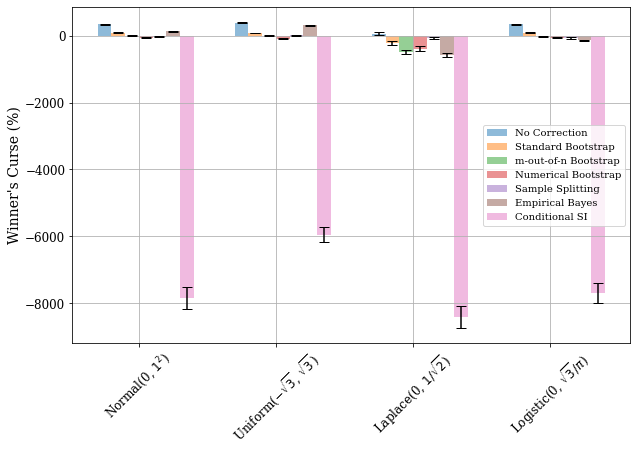

Normal(0, $1^2$)  \
No Correction        Mean              331.81   
                     Median            347.61   
                     S.E.                7.04   
Standard Bootstrap   Mean               78.37   
                     Median             85.31   
                     S.E.                7.91   
m-out-of-n Bootstrap Mean               -9.05   
                     Median             -3.27   
                     S.E.                8.01   
Numerical Bootstrap  Mean              -64.11   
                     Median            -50.26   
                     S.E.                8.57   
Sample Splitting     Mean              -35.68   
                     Median             -3.90   
                     S.E.               10.11   
Empirical Bayes      Mean              125.37   
                     Median            157.75   
                     S.E.                7.08   
Conditional SI       Mean            -7835.94   
                     Median          -4966.76   
                     S.E.              160.89   

                             Uniform($-\sqrt{3}$, $\sqrt{3}$)  \
No Correction        Mean                              382.97   
                     Median                            397.09   
                     S.E.                                5.96   
Standard Bootstrap   Mean                               77.06   
                     Median                             83.22   
                     S.E.                                6.79   
m-out-of-n Bootstrap Mean                              -10.18   
                     Median                             -6.93   
                     S.E.                                6.82   
Numerical Bootstrap  Mean                             -101.08   
                     Median                           -101.26   
                     S.E.                                7.39   
Sample Splitting     Mean                                3.85   
                     Median                             13.68   
                     S.E.                                8.38   
Empirical Bayes      Mean                              302.63   
                     Median                            311.44   
                     S.E.                                5.98   
Conditional SI       Mean                            -5945.46   
                     Median                          -4282.94   
                     S.E.                              114.02   

                             Laplace(0, $1/\sqrt{2}$)  \
No Correction        Mean                       59.03   
                     Median                    337.62   
                     S.E.                       23.03   
Standard Bootstrap   Mean                     -225.16   
                     Median                    111.93   
                     S.E.                       29.31   
m-out-of-n Bootstrap Mean                     -483.43   
                     Median                    -91.22   
                     S.E.                       32.65   
Numerical Bootstrap  Mean                     -387.18   
                     Median                    -17.98   
                     S.E.                       33.10   
Sample Splitting     Mean                      -68.01   
                     Median                     76.51   
                     S.E.                       18.84   
Empirical Bayes      Mean                     -583.53   
                     Median                   -209.60   
                     S.E.                       24.23   
Conditional SI       Mean                    -8396.50   
                     Median                  -5531.79   
                     S.E.                      167.81   

                             Logistic(0, $\sqrt{3} / \pi$)  
No Correction        Mean                           336.35  
                     Median                         371.83  
                     S.E.                            10.34  
Standard Bootstrap  

In [20]:
# parameters
optimizer_key = 'rank_and_select'
result_dict = cust_feat_var_result_dict.copy()
delta_tau = dgp_params['base_effect_vars'][1].mean - dgp_params['base_effect_vars'][0].mean

# Create a properly structured MultiIndex DataFrame for winner's curse statistics
data = {}

estimator_names = ['No Correction'] + [
    estimators_dict[est_key]['display_name'] 
    for est_key in estimators_dict.keys()
]

# For each delta tau value
for cust_feat_var in cust_feat_var_dict.keys():
    data[cust_feat_var] = {}

    data[cust_feat_var]['No Correction'] = {
        'Mean': 100 / delta_tau * result_dict[cust_feat_var][f'{optimizer_key}_nc_wc_avg'],
        'Median': 100 / delta_tau * np.nanmedian(result_dict[cust_feat_var][f'{optimizer_key}_nc_wc_arr']),
        'S.E.': 100 / delta_tau * result_dict[cust_feat_var][f'{optimizer_key}_nc_wc_se']
    }
    
    # Get data for each estimator
    for i, est_key in enumerate([k for k in estimators_dict.keys()]):
        est_name = estimator_names[i+1]
        
        # Extract values
        mean_wc = 100 / delta_tau * result_dict[cust_feat_var][f'{optimizer_key}_{est_key}_wc_avg']
        median_wc = 100 / delta_tau * np.nanmedian(result_dict[cust_feat_var][f'{optimizer_key}_{est_key}_wc_arr'])
        se_wc = 100 / delta_tau * result_dict[cust_feat_var][f'{optimizer_key}_{est_key}_wc_se']
        
        # Store in nested dictionary
        data[cust_feat_var][est_name] = {
            'Mean': mean_wc, 'Median': median_wc, 'S.E.': se_wc
        }

# Create the MultiIndex DataFrame
index = pd.MultiIndex.from_product([
    estimator_names, ['Mean', 'Median', 'S.E.']
])

# Prepare data for DataFrame
df_data = []
for noise_dstn in cust_feat_var_dict.keys():
    column_data = []
    for est_name in estimator_names:
        for stat in ['Mean', 'Median', 'S.E.']:
            column_data.append(data[noise_dstn][est_name][stat])
    df_data.append(column_data)

# Create DataFrame
wc_stats_df = pd.DataFrame(
    np.array(df_data).T,
    index=index,
    columns=list(cust_feat_var_dict.keys())
)


""" 
Visualize the Winner's Curse as a function of the treatment effect difference
"""

# plot the winner's curse as a function of the number of experiments
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

n_estimators = len(estimators_dict.keys())
bar_positions = np.arange(len(cust_feat_var_dict.keys()))
bar_width = 0.1 * n_estimators


# plot the bars
for idx, estimator in enumerate(estimator_names):
    
    bar_values = [data[p][estimator]['Mean'] for p in cust_feat_var_dict.keys()]
    bar_errors = [1.96 * data[p][estimator]['S.E.'] for p in cust_feat_var_dict.keys()]

    ax.bar(
        bar_positions - bar_width / 2 + idx * bar_width / n_estimators + bar_width / 2 / n_estimators,
        bar_values, yerr=bar_errors, capsize=5,
        label=estimator, alpha=0.5, width=bar_width / n_estimators
    )

ax.set_ylabel('Winner\'s Curse (%)', fontsize=axis_label_size)
ax.set_xticks(
    np.arange(len(cust_feat_var_dict.keys())), 
    labels=cust_feat_var_dict.keys(), 
    rotation=45
)
ax.tick_params(axis='both', labelsize=tick_label_size)
ax.legend()
ax.grid()
# plt.tight_layout()
plt.show()

# delete all variables in this cell
del data, estimator_names, df_data, estimator, idx, bar_positions, bar_width, bar_values, bar_errors, n_estimators, optimizer_key
del result_dict

# Display the DataFrame
wc_stats_df.round(2)

In [31]:
# parameters
optimizer_key = 'rank_and_select'
result_dict = cust_feat_var_result_dict.copy()
delta_tau = dgp_params['base_effect_vars'][1].mean - dgp_params['base_effect_vars'][0].mean
# Create a properly structured MultiIndex DataFrame for winner's curse statistics
data = {}

estimator_names = ['No Correction'] + [
    estimators_dict[est_key]['display_name'] 
    for est_key in estimators_dict.keys()
]

# For each delta tau value
for cust_feat_var in cust_feat_var_dict.keys():
    data[cust_feat_var] = {}

    wc_mean = 100 / delta_tau * result_dict[cust_feat_var][f'{optimizer_key}_nc_wc_avg']
    wc_se = 100 / delta_tau * result_dict[cust_feat_var][f'{optimizer_key}_nc_wc_se']
    sig_level = significance_level(wc_mean, wc_se)
    sig_level = '^{' + sig_level + '}' if sig_level != '' else ''
    data[cust_feat_var]['No Correction'] = "\\begin{tabular}[c]{@{}c@{}}" + f"${wc_mean:.2f}\%" + sig_level + f"$\\\\ (${wc_se:.2f}\%$)" + "\end{tabular}"
    
    # Get data for each estimator
    for i, est_key in enumerate([k for k in estimators_dict.keys()]):
        est_name = estimator_names[i+1]
        
        # Extract values
        wc_mean = 100 / delta_tau * result_dict[cust_feat_var][f'{optimizer_key}_{est_key}_wc_avg']
        wc_se = 100 / delta_tau * result_dict[cust_feat_var][f'{optimizer_key}_{est_key}_wc_se']
        sig_level = significance_level(wc_mean, wc_se)
        sig_level = '^{' + sig_level + '}' if sig_level != '' else ''
        data[cust_feat_var][est_name] = "\\begin{tabular}[c]{@{}c@{}}" + f"${wc_mean:.2f}\%" + sig_level + f"$\\\\ (${wc_se:.2f}\%$)" + "\end{tabular}"

# Create DataFrame
latex_df = pd.DataFrame(data)
latex_df.columns = list(cust_feat_var_dict.keys())
print(latex_df.style.to_latex(
    column_format='c' * (len(cust_feat_var_dict) + 1), 
    hrules=True
))

\begin{tabular}{ccccc}
\toprule
 & Normal(0, $1^2$) & Uniform($-\sqrt{3}$, $\sqrt{3}$) & Laplace(0, $1/\sqrt{2}$) & Logistic(0, $\sqrt{3} / \pi$) \\
\midrule
No Correction & \begin{tabular}[c]{@{}c@{}}$331.81\%^{***}$\\ ($7.04\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$382.97\%^{***}$\\ ($5.96\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$59.03\%^{**}$\\ ($23.03\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$336.35\%^{***}$\\ ($10.34\%$)\end{tabular} \\
Standard Bootstrap & \begin{tabular}[c]{@{}c@{}}$78.37\%^{***}$\\ ($7.91\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$77.06\%^{***}$\\ ($6.79\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$-225.16\%^{***}$\\ ($29.31\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$83.10\%^{***}$\\ ($11.06\%$)\end{tabular} \\
m-out-of-n Bootstrap & \begin{tabular}[c]{@{}c@{}}$-9.05\%$\\ ($8.01\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$-10.18\%$\\ ($6.82\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$-483.43\%^{***}$\\ ($32.65\%$)\end{tabular} &

## Max Depth

In [32]:
optimization_params = {
    'rank_and_select': {
        'optimizer': optimize, 'params': {}, 'display_name': 'Rank and Select'
    }
}

dgp_params = {
    'base_effect_vars': [PointMass(1), PointMass(1.01)], 
    'cust_feat_var': UnivariateGaussian(0, 1), 
    'char_func': lambda x: x**2 + x, 
    'noise_var': UnivariateGaussian(0, 1), 
    'response_type': 'continuous', 
    'dgp_seed': 0
}

data_params = {'sample_size': 2500, 'targ_sample_size': 100} 

experiment_params = {
    'n_repeats': 500, 
    'estimator': {
        'estimator': CausalForestDML, 
        'params': {
            'n_treatments': len(dgp_params['base_effect_vars']), 
            'model_t': LogisticRegression(C=0.01), 
            'model_y': Lasso(alpha=0.01), 
            'n_estimators': 100, 
            'max_depth': 5, 
            'n_jobs': -1, 
            'discrete_treatment': True
        }
    }
}

estimators_dict = {
    'sample_splitting': {
        'estimator': sample_splitting_estimate, 
        'params': {'estimation_split': 0.5, }, 
        'display_name': 'Sample Splitting', 
    }, 
    'standard_bootstrap': {
        'estimator': bootstrap_correction_estimate, 
        'params': {'n_bootstraps': 100, 'n_jobs': -1}, 
        'display_name': 'Standard Bootstrap'
    },
    'mn_bootstrap': {
        'estimator': bootstrap_correction_estimate, 
        'params': {'bootstrap_method': 'm_out_of_n', 'n_bootstraps': 100, 'power': 0.95, 'n_jobs': -1}, 
        'display_name': 'm-out-of-n Bootstrap'
    },
    'num_bootstrap': {
        'estimator': bootstrap_correction_estimate, 
        'params': {'bootstrap_method': 'numerical', 'n_bootstraps': 100, 'power': -0.45, 'n_jobs': -1}, 
        'display_name': 'Numerical Bootstrap'
    }, 
    # 'bayes_normal': {
    #     'estimator': bayes_estimate, 
    #     'params': {'prior': 'normal', 'prior_mean': 0.0, 'prior_std': 1.0},
    #     'display_name': 'Bayes (Normal)'
    # }, 
    'eb_normal': {
        'estimator': empirical_bayes_estimate,
        'params': {'prior': 'normal', 'dof': 3, 'bin_width': 0.2},
        'display_name': 'Empirical Bayes'
    }, 
    # 'eb_spike_slab': {
    #     'estimator': empirical_bayes_estimate, 
    #     'params': {'prior': 'spike_slab', 'pi': 0.5},
    #     'display_name': 'EB (Spike-and-Slab)'
    # }, 
    'conditional_si': {
        'estimator': selective_inference_estimate,
        'params': {'method': 'conditional', 'quantile': 0.5, 'n_jobs': -1}, 
        'display_name': 'Conditional SI'
    }, 
    # 'hybrid_si': {
    #     'estimator': selective_inference_estimate,
    #     'params': {'method': 'hybrid', 'quantile': 0.5, 'n_jobs': -1}, 
    #     'display_name': 'Hybrid SI'
    # }, 
}

max_depth_list = [2, 5, 10, 20]

In [33]:
max_depth_result_dict = {max_depth: None for max_depth in max_depth_list}

for max_depth in max_depth_list:
    print(f'\nMax Depth= {max_depth}')

    experiment_params['estimator']['params']['max_depth'] = max_depth

    result_records = repeated_experiment(
        optimization_params=optimization_params, 
        dgp_params=dgp_params, 
        data_params=data_params, 
        experiment_params=experiment_params,
        estimators_dict=estimators_dict,
        verbose=True,
        n_jobs=-1
    )

    max_depth_result_dict[max_depth] = calculate_winners_curse_measures(
        result_records=result_records, 
        optimization_params=optimization_params, 
        estimators_dict=estimators_dict, 
        data_params=data_params
    )


Max Depth= 2
Running 500 experiments...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.
[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed: 25.0min
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed: 67.4min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed: 86.3min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



Max Depth= 5
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed: 33.4min
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed: 89.5min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed: 113.8min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



Max Depth= 10
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed: 55.5min
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed: 148.3min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed: 187.9min finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 32 concurrent workers.



Max Depth= 20
Running 500 experiments...


[Parallel(n_jobs=-1)]: Done 136 tasks      | elapsed: 87.1min
[Parallel(n_jobs=-1)]: Done 386 tasks      | elapsed: 228.0min
[Parallel(n_jobs=-1)]: Done 500 out of 500 | elapsed: 288.2min finished


In [34]:
with open('results/targeting_max_depth.pkl', 'wb') as f:
    pickle.dump(max_depth_result_dict, f)

with open('results/targeting_max_depth.pkl', 'rb') as f:
    max_depth_result_dict = pickle.load(f)

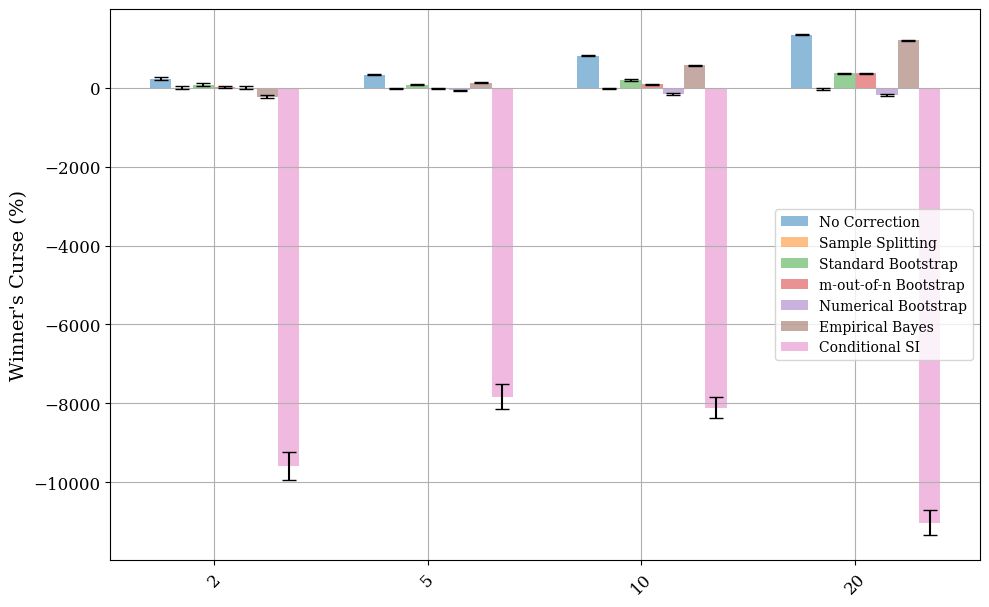

2        5        10        20
No Correction        Mean     230.04   331.81   813.45   1343.59
                     Median   191.17   347.61   807.87   1321.85
                     S.E.      17.30     7.04     7.61      9.07
Sample Splitting     Mean       3.38   -20.63   -22.67    -39.47
                     Median    39.02   -14.00   -13.34    -51.81
                     S.E.      18.66     9.75    10.02     11.28
Standard Bootstrap   Mean      80.22    78.11   195.17    364.27
                     Median    71.02    86.77   198.60    377.76
                     S.E.      17.94     7.90     8.57     10.28
m-out-of-n Bootstrap Mean      17.57   -10.62    84.79    363.47
                     Median    25.96    -0.08    70.82    355.87
                     S.E.      18.35     8.03     8.99     11.33
Numerical Bootstrap  Mean      -2.96   -66.61  -158.00   -189.52
                     Median    18.31   -55.70  -165.01   -199.97
                     S.E.      18.52     8.57     9.30     11.26
Empirical Bayes      Mean    -226.02   125.37   565.16   1204.12
                     Median  -227.99   157.75   573.35   1206.58
                     S.E.      17.85     7.08     7.67      9.11
Conditional SI       Mean   -9585.57 -7835.94 -8114.19 -11028.11
                     Median -6528.34 -4966.76 -6141.93  -8495.78
                     S.E.     181.23   160.89   134.88    160.44

In [38]:
# parameters
optimizer_key = 'rank_and_select'
result_dict = max_depth_result_dict.copy()
delta_tau = dgp_params['base_effect_vars'][1].mean - dgp_params['base_effect_vars'][0].mean

# Create a properly structured MultiIndex DataFrame for winner's curse statistics
data = {}

estimator_names = ['No Correction'] + [
    estimators_dict[est_key]['display_name'] 
    for est_key in estimators_dict.keys()
]

# For each delta tau value
for max_depth in max_depth_list:
    data[max_depth] = {}

    data[max_depth]['No Correction'] = {
        'Mean': 100 / delta_tau * result_dict[max_depth][f'{optimizer_key}_nc_wc_avg'],
        'Median': 100 / delta_tau * np.nanmedian(result_dict[max_depth][f'{optimizer_key}_nc_wc_arr']),
        'S.E.': 100 / delta_tau * result_dict[max_depth][f'{optimizer_key}_nc_wc_se']
    }
    
    # Get data for each estimator
    for i, est_key in enumerate([k for k in estimators_dict.keys()]):
        est_name = estimator_names[i+1]
        
        # Extract values
        mean_wc = 100 / delta_tau * result_dict[max_depth][f'{optimizer_key}_{est_key}_wc_avg']
        median_wc = 100 / delta_tau * np.nanmedian(result_dict[max_depth][f'{optimizer_key}_{est_key}_wc_arr'])
        se_wc = 100 / delta_tau * result_dict[max_depth][f'{optimizer_key}_{est_key}_wc_se']
        
        # Store in nested dictionary
        data[max_depth][est_name] = {
            'Mean': mean_wc, 'Median': median_wc, 'S.E.': se_wc
        }

# Create the MultiIndex DataFrame
index = pd.MultiIndex.from_product([
    estimator_names, ['Mean', 'Median', 'S.E.']
])

# Prepare data for DataFrame
df_data = []
for max_depth in max_depth_list:
    column_data = []
    for est_name in estimator_names:
        for stat in ['Mean', 'Median', 'S.E.']:
            column_data.append(data[max_depth][est_name][stat])
    df_data.append(column_data)

# Create DataFrame
wc_stats_df = pd.DataFrame(
    np.array(df_data).T,
    index=index,
    columns=max_depth_list
)


""" 
Visualize the Winner's Curse as a function of the treatment effect difference
"""

# plot the winner's curse as a function of the number of experiments
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

n_estimators = len(estimators_dict.keys())
bar_positions = np.arange(len(max_depth_list))
bar_width = 0.1 * n_estimators


# plot the bars
for idx, estimator in enumerate(estimator_names):
    
    bar_values = [data[p][estimator]['Mean'] for p in max_depth_list]
    bar_errors = [1.96 * data[p][estimator]['S.E.'] for p in max_depth_list]

    ax.bar(
        bar_positions - bar_width / 2 + idx * bar_width / n_estimators + bar_width / 2 / n_estimators,
        bar_values, yerr=bar_errors, capsize=5,
        label=estimator, alpha=0.5, width=bar_width / n_estimators
    )

ax.set_ylabel('Winner\'s Curse (%)', fontsize=axis_label_size)
ax.set_xticks(
    np.arange(len(max_depth_list)), 
    labels=max_depth_list, 
    rotation=45
)
ax.tick_params(axis='both', labelsize=tick_label_size)
ax.legend()
ax.grid()
plt.tight_layout()
plt.show()

# delete all variables in this cell
del data, estimator_names, df_data, estimator, idx, bar_positions, bar_width, bar_values, bar_errors, n_estimators, optimizer_key
del result_dict

# Display the DataFrame
wc_stats_df.round(2)

In [37]:
# parameters
optimizer_key = 'rank_and_select'
result_dict = max_depth_result_dict.copy()
delta_tau = dgp_params['base_effect_vars'][1].mean - dgp_params['base_effect_vars'][0].mean

# Create a properly structured MultiIndex DataFrame for winner's curse statistics
data = {}

estimator_names = ['No Correction'] + [
    estimators_dict[est_key]['display_name'] 
    for est_key in estimators_dict.keys()
]

# For each delta tau value
for max_depth in max_depth_list:
    data[max_depth] = {}

    wc_mean = 100 / delta_tau * result_dict[max_depth][f'{optimizer_key}_nc_wc_avg']
    wc_se = 100 / delta_tau * result_dict[max_depth][f'{optimizer_key}_nc_wc_se']
    sig_level = significance_level(wc_mean, wc_se)
    sig_level = '^{' + sig_level + '}' if sig_level != '' else ''
    data[max_depth]['No Correction'] = "\\begin{tabular}[c]{@{}c@{}}" + f"${wc_mean:.2f}\%" + sig_level + f"$\\\\ (${wc_se:.2f}\%$)" + "\end{tabular}"
    
    # Get data for each estimator
    for i, est_key in enumerate([k for k in estimators_dict.keys()]):
        est_name = estimator_names[i+1]
        
        # Extract values
        wc_mean = 100 / delta_tau * result_dict[max_depth][f'{optimizer_key}_{est_key}_wc_avg']
        wc_se = 100 / delta_tau * result_dict[max_depth][f'{optimizer_key}_{est_key}_wc_se']
        sig_level = significance_level(wc_mean, wc_se)
        sig_level = '^{' + sig_level + '}' if sig_level != '' else ''
        data[max_depth][est_name] = "\\begin{tabular}[c]{@{}c@{}}" + f"${wc_mean:.2f}\%" + sig_level + f"$\\\\ (${wc_se:.2f}\%$)" + "\end{tabular}"

# Create DataFrame
latex_df = pd.DataFrame(data)[[2, 5, 10, 20]]
latex_df.columns = [f'Depth={max_depth}' for max_depth in [2, 5, 10, 20]]
print(latex_df.style.to_latex(
    column_format='c' * (len([2, 5, 10, 20]) + 1), 
    hrules=True
))

\begin{tabular}{ccccc}
\toprule
 & Depth=2 & Depth=5 & Depth=10 & Depth=20 \\
\midrule
No Correction & \begin{tabular}[c]{@{}c@{}}$230.04\%^{***}$\\ ($17.30\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$331.81\%^{***}$\\ ($7.04\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$813.45\%^{***}$\\ ($7.61\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$1343.59\%^{***}$\\ ($9.07\%$)\end{tabular} \\
Sample Splitting & \begin{tabular}[c]{@{}c@{}}$3.38\%$\\ ($18.66\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$-20.63\%^{**}$\\ ($9.75\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$-22.67\%^{**}$\\ ($10.02\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$-39.47\%^{***}$\\ ($11.28\%$)\end{tabular} \\
Standard Bootstrap & \begin{tabular}[c]{@{}c@{}}$80.22\%^{***}$\\ ($17.94\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$78.11\%^{***}$\\ ($7.90\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$195.17\%^{***}$\\ ($8.57\%$)\end{tabular} & \begin{tabular}[c]{@{}c@{}}$364.27\%^{***}$\\ ($10.28\%$)\end{tabular

In [12]:
optimization_params = {
    'rank_and_select': {
        'optimizer': optimize, 'params': {}, 'display_name': 'Rank and Select'
    }
}

dgp_params = {
    'base_effect_vars': [PointMass(1 + i * 0.01) for i in range(2)], 
    'cust_feat_var': UnivariateGaussian(0, 1), 
    'char_func': lambda x: x**2 + x, 
    'noise_var': UnivariateGaussian(0, 1), 
    'response_type': 'continuous', 
    'dgp_seed': 0
}

data_params = {'sample_size': None, 'targ_sample_size': 100} 

experiment_params = {
    'n_repeats': 500, 
    'estimator': {
        'estimator': CausalForestDML, 
        'params': {
            'n_treatments': len(dgp_params['base_effect_vars']), 
            'model_t': LogisticRegression(C=0.01), 
            'model_y': Lasso(alpha=0.01), 
            'n_estimators': 100, 
            'max_depth': None, 
            'n_jobs': -1, 
            'discrete_treatment': True
        }
    }
}

estimators_dict = {}

max_depth_list = [5, 10, 15, 20, 25]
depth_sample_size_list = [2500, 5000, 10000, 15000, 20000,30000, 40000, 50000]

In [75]:
depth_sample_size_result_dict = {(sample_size, max_depth): None for sample_size in depth_sample_size_list for max_depth in max_depth_list}

for sample_size in depth_sample_size_list:
    for max_depth in max_depth_list:
        print(f'\nSample Size= {sample_size}, Max Depth= {max_depth}')

        experiment_params['estimator']['params']['max_depth'] = max_depth
        data_params['sample_size'] = sample_size

        result_records = repeated_experiment(
            optimization_params=optimization_params, 
            dgp_params=dgp_params, 
            data_params=data_params, 
            experiment_params=experiment_params,
            estimators_dict=estimators_dict,
            verbose=False,
            n_jobs=-1
        )

        depth_sample_size_result_dict[(sample_size, max_depth)] = calculate_winners_curse_measures(
            result_records=result_records, 
            optimization_params=optimization_params, 
            estimators_dict=estimators_dict, 
            data_params=data_params
        )

        with open('results/targeting_depth_sample_size.pkl', 'wb') as f:
            pickle.dump(depth_sample_size_result_dict, f)

        print(f'Finished')


Sample Size= 2500, Max Depth= 5
Finished

Sample Size= 2500, Max Depth= 10


A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.


Finished

Sample Size= 2500, Max Depth= 15
Finished

Sample Size= 2500, Max Depth= 20
Finished

Sample Size= 2500, Max Depth= 25
Finished

Sample Size= 5000, Max Depth= 5
Finished

Sample Size= 5000, Max Depth= 10
Finished

Sample Size= 5000, Max Depth= 15
Finished

Sample Size= 5000, Max Depth= 20
Finished

Sample Size= 5000, Max Depth= 25
Finished

Sample Size= 10000, Max Depth= 5
Finished

Sample Size= 10000, Max Depth= 10
Finished

Sample Size= 10000, Max Depth= 15
Finished

Sample Size= 10000, Max Depth= 20
Finished

Sample Size= 10000, Max Depth= 25
Finished

Sample Size= 15000, Max Depth= 5
Finished

Sample Size= 15000, Max Depth= 10
Finished

Sample Size= 15000, Max Depth= 15
Finished

Sample Size= 15000, Max Depth= 20
Finished

Sample Size= 15000, Max Depth= 25
Finished

Sample Size= 20000, Max Depth= 5
Finished

Sample Size= 20000, Max Depth= 10
Finished

Sample Size= 20000, Max Depth= 15
Finished

Sample Size= 20000, Max Depth= 20
Finished

Sample Size= 20000, Max Depth= 25


In [13]:
# with open('results/targeting_depth_sample_size.pkl', 'wb') as f:
#     pickle.dump(depth_sample_size_result_dict, f)

with open('results/targeting_depth_sample_size.pkl', 'rb') as f:
    depth_sample_size_result_dict = pickle.load(f)

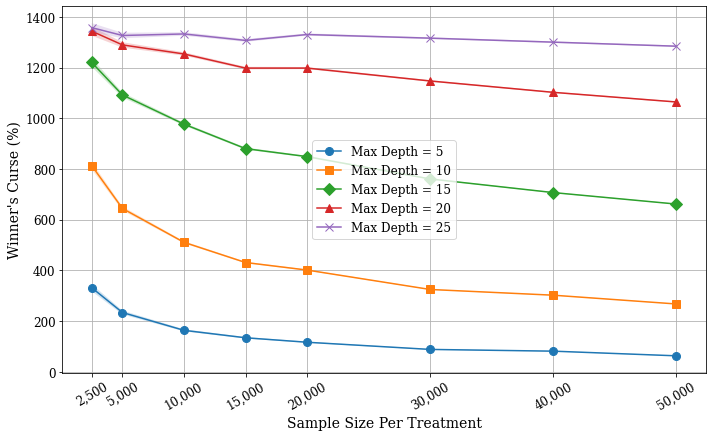

In [15]:
delta_tau = dgp_params['base_effect_vars'][1].mean - dgp_params['base_effect_vars'][0].mean

fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

markers = ['o', 's', 'D', '^', 'x']

viz_max_depth_list = max_depth_list
for i, max_depth in enumerate(viz_max_depth_list):
    wc_avg_list = [result_dict['rank_and_select_nc_wc_avg'] * 100 / delta_tau for (_, depth), result_dict in depth_sample_size_result_dict.items() if depth == max_depth]
    wc_se_list = [result_dict['rank_and_select_nc_wc_se'] * 100 / delta_tau for (_, depth), result_dict in depth_sample_size_result_dict.items() if depth == max_depth]

    ax.plot(
        depth_sample_size_list, wc_avg_list, 
        label=f'Max Depth = {max_depth}', 
        marker=markers[i], 
        markersize=8
    )
    ax.fill_between(
        depth_sample_size_list, 
        np.array(wc_avg_list) - 1.96 * np.array(wc_se_list), 
        np.array(wc_avg_list) + 1.96 * np.array(wc_se_list), 
        alpha=0.2
    )

ax.set_xlabel('Sample Size Per Treatment', fontsize=axis_label_size)
ax.set_ylabel('Winner\'s Curse (%)', fontsize=axis_label_size)
ax.set_xticks(depth_sample_size_list, labels=[f'{s_:,}' for s_ in depth_sample_size_list], rotation=30)
ax.tick_params(axis='both', labelsize=tick_label_size)
ax.legend(fontsize=legend_label_size)

ax.grid()
plt.tight_layout()
plt.savefig('figures/targeting_depth_sample_size.svg')
plt.show()

# Bernoulli Response

In [67]:
optimization_params = {
    'rank_and_select': {
        'optimizer': optimize, 'params': {}, 'display_name': 'Rank and Select'
    }
}

dgp_params = {
    'base_effect_vars': [PointMass(0.1), PointMass(0.11)], 
    'cust_feat_var': Uniform(0, 1), 
    'char_func': lambda x: x**2 + x, 
    'response_type': 'bernoulli', 
    'dgp_seed': 0
}

data_params = {'sample_size': 100, 'targ_sample_size': 100} 

experiment_params = {
    'n_repeats': 500, 
    'estimator': {
        'estimator': CausalForestDML, 
        'params': {
            'n_treatments': len(dgp_params['base_effect_vars']), 
            'model_t': LogisticRegression(C=0.01), 
            'model_y': LogisticRegression(C=0.01), 
            'n_estimators': 500, 
            'max_depth': 5, 
            'n_jobs': -1, 
            'discrete_outcome': True, 
            'discrete_treatment': True
        }
    }
}

estimators_dict = {
    'sample_splitting': {
        'estimator': sample_splitting_estimate, 
        'params': {'estimation_split': 0.5}, 
        'display_name': 'Sample Splitting', 
    }, 
    # 'standard_bootstrap': {
    #     'estimator': bootstrap_correction_estimate, 
    #     'params': {'n_bootstraps': 100, 'n_jobs': -1}, 
    #     'display_name': 'Standard Bootstrap'
    # },
    # 'mn_bootstrap': {
    #     'estimator': bootstrap_correction_estimate, 
    #     'params': {'bootstrap_method': 'm_out_of_n', 'n_bootstraps': 100, 'power': 0.95, 'n_jobs': -1}, 
    #     'display_name': 'm-out-of-n Bootstrap'
    # },
    # 'num_bootstrap': {
    #     'estimator': bootstrap_correction_estimate, 
    #     'params': {'bootstrap_method': 'numerical', 'n_bootstraps': 100, 'power': -0.45, 'n_jobs': -1}, 
    #     'display_name': 'Numerical Bootstrap'
    # }, 
    # 'bayes_normal': {
    #     'estimator': bayes_estimate, 
    #     'params': {'prior': 'normal', 'prior_mean': 0.0, 'prior_std': 1.0},
    #     'display_name': 'Bayes'
    # }, 
    # 'eb_normal': {
    #     'estimator': empirical_bayes_estimate, 
    #     'params': {'prior': 'normal', 'dof': 3, 'bin_width': 0.2}, 
    #     'display_name': 'Empirical Bayes'
    # }, 
    # 'eb_spike_slab': {
    #     'estimator': empirical_bayes_estimate, 
    #     'params': {'prior': 'spike_slab', 'pi': 0.5},
    #     'display_name': 'EB (Spike-and-Slab)'
    # }, 
    # 'conditional_si': {
    #     'estimator': selective_inference_estimate,
    #     'params': {'method': 'conditional', 'quantile': 0.5, 'n_jobs': -1}, 
    #     'display_name': 'Conditional SI'
    # }, 
    # 'hybrid_si': {
    #     'estimator': selective_inference_estimate,
    #     'params': {'method': 'hybrid', 'quantile': 0.5, 'n_jobs': -1}, 
    #     'display_name': 'Hybrid SI'
    # }, 
}

In [ ]:
result_records = repeated_experiment(
    optimization_params=optimization_params, 
    dgp_params=dgp_params, 
    data_params=data_params, 
    experiment_params=experiment_params, 
    estimators_dict=estimators_dict, 
    verbose=True, 
    n_jobs=-1
)

wc_measures_dict = calculate_winners_curse_measures(
    result_records=result_records, 
    optimization_params=optimization_params, 
    estimators_dict=estimators_dict, 
    data_params=data_params
)

Running 500 experiments...


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 10 concurrent workers.
The least populated class in y has only 1 members, which is less than n_splits=2.
The least populated class in y has only 1 members, which is less than n_splits=2.
invalid value encountered in sqrt
The least populated class in y has only 1 members, which is less than n_splits=2.
The least populated class in y has only 1 members, which is less than n_splits=2.
The least populated class in y has only 1 members, which is less than n_splits=2.
The least populated class in y has only 1 members, which is less than n_splits=2.
The least populated class in y has only 1 members, which is less than n_splits=2.



Selection with Rank and Select:
Policy Value: 
  - True Value: 0.1710 (0.0012)
  - No Correction: 0.2166 (0.0037)

Winner's Curse: 
Average Winner's Curse: 
  - No Correction: 456.85% (35.03%)
Median Winner's Curse: 
  - No Correction: 461.11% (35.03%)

Sample Splitting: 
  - True Value: 0.1711 (0.0012)
  - Estimated Value: 0.1709 (0.0050)
  - Winner's Curse (%): -2.36% (49.79%)


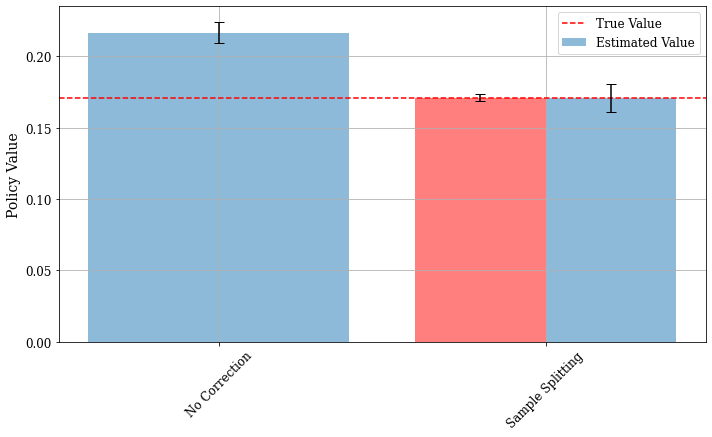

In [ ]:
delta_tau = dgp_params['base_effect_vars'][1].mean - dgp_params['base_effect_vars'][0].mean

optimizer_key = 'rank_and_select'

print(f'\nSelection with {optimization_params[optimizer_key]["display_name"]}:')

val_true_avg = wc_measures_dict[f'{optimizer_key}_nc_val_true_avg']
val_true_se = wc_measures_dict[f'{optimizer_key}_nc_val_true_se']

print(f'Policy Value: ')
print(f'  - True Value: {val_true_avg:.4f} ({val_true_se:.4f})')
for estimator_name in ['nc'] + [k for k in estimators_dict.keys() if k != 'sample_splitting']:
    if estimator_name == 'sample_splitting':
        continue
    est_avg = wc_measures_dict[f'{optimizer_key}_{estimator_name}_val_est_avg']
    est_se = wc_measures_dict[f'{optimizer_key}_{estimator_name}_val_est_se']
    display_name = estimators_dict[estimator_name]['display_name'] if estimator_name != 'nc' else 'No Correction'

    print(f'  - {display_name}: {est_avg:.4f} ({est_se:.4f})')

print(f'\nWinner\'s Curse: ')
print(f"Average Winner's Curse: ")
for estimator_name in ['nc'] + [k for k in estimators_dict.keys() if k != 'sample_splitting']:
    if estimator_name == 'sample_splitting':
        continue
    wc_avg = wc_measures_dict[f'{optimizer_key}_{estimator_name}_wc_avg']
    wc_se = wc_measures_dict[f'{optimizer_key}_{estimator_name}_wc_se']
    display_name = estimators_dict[estimator_name]['display_name'] if estimator_name != 'nc' else 'No Correction'

    print(f'  - {display_name}: {wc_avg/delta_tau:.2%} ({wc_se/delta_tau:.2%})')

print(f'Median Winner\'s Curse: ')
for estimator_name in ['nc'] + [k for k in estimators_dict.keys() if k != 'sample_splitting']:
    if estimator_name == 'sample_splitting':
        continue
    wc_median = np.nanmedian(wc_measures_dict[f'{optimizer_key}_{estimator_name}_wc_arr'])
    wc_se = wc_measures_dict[f'{optimizer_key}_{estimator_name}_wc_se']
    display_name = estimators_dict[estimator_name]['display_name'] if estimator_name != 'nc' else 'No Correction'

    print(f'  - {display_name}: {wc_median/delta_tau:.2%} ({wc_se/delta_tau:.2%})')

if 'sample_splitting' in estimators_dict.keys():
    print(f'\nSample Splitting: ')
    ss_val_true_avg = wc_measures_dict[f'{optimizer_key}_sample_splitting_val_true_avg']
    ss_val_true_se = wc_measures_dict[f'{optimizer_key}_sample_splitting_val_true_se']
    ss_val_est_avg = wc_measures_dict[f'{optimizer_key}_sample_splitting_val_est_avg']
    ss_val_est_se = wc_measures_dict[f'{optimizer_key}_sample_splitting_val_est_se']
    ss_wc_avg = wc_measures_dict[f'{optimizer_key}_sample_splitting_wc_avg']
    ss_wc_se = wc_measures_dict[f'{optimizer_key}_sample_splitting_wc_se']

    print(f'  - True Value: {ss_val_true_avg:.4f} ({ss_val_true_se:.4f})')
    print(f'  - Estimated Value: {ss_val_est_avg:.4f} ({ss_val_est_se:.4f})')
    print(f'  - Winner\'s Curse (%): {ss_wc_avg/delta_tau:.2%} ({ss_wc_se/delta_tau:.2%})')

# bar plot comparing the true value and estiamted value frome each estimator 
fig, ax = plt.subplots(1, 1, figsize=(10, 6.18))

bar_positions = np.arange(len(estimators_dict.keys()) + 1 - int('sample_splitting' in estimators_dict.keys()))
bar_values = [
    wc_measures_dict[f'{optimizer_key}_{estimator_name}_val_est_avg']
    for estimator_name in ['nc'] + [k for k in estimators_dict.keys() if k != 'sample_splitting']
]
bar_errors = [
    1.96 * wc_measures_dict[f'{optimizer_key}_{estimator_name}_val_est_se']
    for estimator_name in ['nc'] + [k for k in estimators_dict.keys() if k != 'sample_splitting']
]

# plot the bars
ax.bar(bar_positions, bar_values, yerr=bar_errors, capsize=5, color='C0', alpha=0.5, label='Estimated Value')
ax.axhline(y=val_true_avg, color='red', linestyle='--', label='True Value')

# plot the bar for sample splitting if it exists
if 'sample_splitting' in estimators_dict.keys():
    # two side-by-side bars for sample splitting, one for true value and one for estimated value
    bar_width = 0.4
    ax.bar(bar_positions[-1] + 1 - bar_width / 2, ss_val_true_avg, yerr=1.95 * ss_val_true_se, capsize=5, color='red', width=bar_width, alpha=0.5)
    ax.bar(bar_positions[-1] + 1 + bar_width / 2, ss_val_est_avg, yerr=1.95 * ss_val_est_se, capsize=5, color='C0', width=bar_width, alpha=0.5)

# ax.set_xlabel('Estimator')
ax.set_ylabel('Policy Value', fontsize=axis_label_size)
# ax.set_title(f'{optimization_params[optimizer_key]["display_name"]} Selection', fontsize=title_size)
if 'sample_splitting' in estimators_dict.keys():
    ax.set_xticks(
        np.arange(len(estimators_dict) + 1), 
        labels=['No Correction'] + [v['display_name'] for k, v in estimators_dict.items() if k != 'sample_splitting'] + ['Sample Splitting'], 
        rotation=45, 
        fontsize=tick_label_size
    )
else:
    ax.set_xticks(
        np.arange(len(estimators_dict) + 1), 
        labels=['No Correction'] + [v['display_name'] for k, v in estimators_dict.items()], 
        rotation=45, 
        fontsize=tick_label_size
    )
# ax.set_ylim([0.9, 1.2])
ax.tick_params(axis='both', labelsize=tick_label_size)
ax.legend(fontsize=legend_label_size)
ax.grid()
plt.tight_layout()
plt.show()


# Sketch

## CF vs. CCF

In [32]:
with open('results/targeting_delta_tau.pkl', 'rb') as f:
    cf_tau_result_dict = pickle.load(f)

with open('results/targeting_ccf_delta_tau.pkl', 'rb') as f:
    ccf_tau_result_dict = pickle.load(f)

with open('results/targeting_max_depth.pkl', 'rb') as f:
    cf_max_depth_result_dict = pickle.load(f)

estimators_list = [
    ('nc', 'No Correction'), 
    ('standard_bootstrap', 'Standard Bootstrap'), 
    ('mn_bootstrap', 'm-out-of-n Bootstrap'), 
    ('sample_splitting', 'Sample Splitting'), 
    ('eb_normal', 'Empirical Bayes'),
    ('conditional_si', 'Conditional Selective Inference'), 
]

In [38]:
wc_avg_dict = {
    'Correct Functional Form': {name: ccf_tau_result_dict[(1, 1.01)][f'rank_and_select_{key}_wc_avg'] / 0.01 for key, name in estimators_list}, 
    '\\begin{tabular}[c]{@{}c@{}}Causal Forest \\\\ (Max Depth = 2)\end{tabular}': {name: cf_max_depth_result_dict[2][f'rank_and_select_{key}_wc_avg'] / 0.01 for key, name in estimators_list}, 
    '\\begin{tabular}[c]{@{}c@{}}Causal Forest \\\\ (Max Depth = 5)\end{tabular}': {name: cf_tau_result_dict[(1, 1.01)][f'rank_and_select_{key}_wc_avg'] / 0.01 for key, name in estimators_list}, 
    '\\begin{tabular}[c]{@{}c@{}}Causal Forest \\\\ (Max Depth = 10)\end{tabular}': {name: cf_max_depth_result_dict[10][f'rank_and_select_{key}_wc_avg'] / 0.01 for key, name in estimators_list}, 
}
wc_se_dict = {
    'Correct Functional Form': {name: ccf_tau_result_dict[(1, 1.01)][f'rank_and_select_{key}_wc_se'] / 0.01 for key, name in estimators_list}, 
    '\\begin{tabular}[c]{@{}c@{}}Causal Forest \\\\ (Max Depth = 2)\end{tabular}': {name: cf_max_depth_result_dict[2][f'rank_and_select_{key}_wc_se'] / 0.01 for key, name in estimators_list}, 
    '\\begin{tabular}[c]{@{}c@{}}Causal Forest \\\\ (Max Depth = 5)\end{tabular}': {name: cf_tau_result_dict[(1, 1.01)][f'rank_and_select_{key}_wc_se'] / 0.01 for key, name in estimators_list}, 
    '\\begin{tabular}[c]{@{}c@{}}Causal Forest \\\\ (Max Depth = 10)\end{tabular}': {name: cf_max_depth_result_dict[10][f'rank_and_select_{key}_wc_se'] / 0.01 for key, name in estimators_list}, 
}

# Create a properly structured DataFrame for winner's curse statistics using wc_avg_dict and wc_se_dict

# Use the keys of wc_avg_dict for columns (methods/settings)
col_names = list(wc_avg_dict.keys())
# Use the estimator names from one of the dicts (all should have the same keys)
row_names = list(wc_avg_dict[col_names[0]].keys())

# Build the LaTeX cell content for each estimator and method
latex_data = []
for est in row_names:
    row = []
    for method in col_names:
        wc_mean = wc_avg_dict[method][est] * 100
        wc_se = wc_se_dict[method][est] * 100
        # Optionally, you can add significance stars if you have a function for that
        sig_level = significance_level(wc_mean, wc_se)
        sig_level = '^{' + sig_level + '}' if sig_level != '' else ''
        row.append(f"\\begin{{tabular}}[c]{{@{{}}c@{{}}}}${wc_mean:.2f}\\%" + sig_level + f"$\\\\ (${wc_se:.2f}$)\\%\\end{{tabular}}")
        # row.append(f"\\begin{{tabular}}[c]{{@{{}}c@{{}}}}${wc_mean:.2f}\\%$\\\\ (${wc_se:.2f}$)\\%\\end{{tabular}}")
    latex_data.append(row)

latex_df = pd.DataFrame(latex_data, index=row_names, columns=col_names)

print(latex_df.style.to_latex(
    column_format='c' * (len(col_names) + 1),
    hrules=True
))


\begin{tabular}{ccccc}
\toprule
 & Correct Functional Form & \begin{tabular}[c]{@{}c@{}}Causal Forest \\ (Max Depth = 2)\end{tabular} & \begin{tabular}[c]{@{}c@{}}Causal Forest \\ (Max Depth = 5)\end{tabular} & \begin{tabular}[c]{@{}c@{}}Causal Forest \\ (Max Depth = 10)\end{tabular} \\
\midrule
No Correction & \begin{tabular}[c]{@{}c@{}}$87.32\%^{***}$\\ ($3.99$)\%\end{tabular} & \begin{tabular}[c]{@{}c@{}}$230.04\%^{***}$\\ ($17.30$)\%\end{tabular} & \begin{tabular}[c]{@{}c@{}}$331.81\%^{***}$\\ ($7.04$)\%\end{tabular} & \begin{tabular}[c]{@{}c@{}}$813.45\%^{***}$\\ ($7.61$)\%\end{tabular} \\
Standard Bootstrap & \begin{tabular}[c]{@{}c@{}}$8.61\%^{**}$\\ ($4.15$)\%\end{tabular} & \begin{tabular}[c]{@{}c@{}}$80.22\%^{***}$\\ ($17.94$)\%\end{tabular} & \begin{tabular}[c]{@{}c@{}}$79.23\%^{***}$\\ ($7.93$)\%\end{tabular} & \begin{tabular}[c]{@{}c@{}}$195.17\%^{***}$\\ ($8.57$)\%\end{tabular} \\
m-out-of-n Bootstrap & \begin{tabular}[c]{@{}c@{}}$-22.05\%^{***}$\\ ($4.16$)\%\end{tabular}